In [ ]:
 !pip install catboost
 !pip install dice-ml
 !pip install lime

# CatBoost Classification Obesity Level

## PART 1 IMPORT LIBRARIES

In [ ]:
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from lime.lime_tabular import LimeTabularExplainer
import dice_ml
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import time
from IPython.display import display

## PART 2 IMPORT DATASET

In [ ]:
# Dhaka Obesity : https://data.mendeley.com/datasets/vhnks4n4h7/2
# ObesityDataSet_raw_and_data_sinthetic: https://www.kaggle.com/datasets/fatemehmehrparvar/obesity-levels

In [ ]:
try:
    df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
    df2 = pd.read_csv('Dhaka_Obesity.csv')
except FileNotFoundError:
    print("File not found. Please check the file path.")

In [ ]:
print(df.head())

    Age  Gender  Height  Weight        CALC FAVC  FCVC  NCP  SCC SMOKE  CH2O  \
0  21.0  Female    1.62    64.0          no   no   2.0  3.0   no    no   2.0   
1  21.0  Female    1.52    56.0   Sometimes   no   3.0  3.0  yes   yes   3.0   
2  23.0    Male    1.80    77.0  Frequently   no   2.0  3.0   no    no   2.0   
3  27.0    Male    1.80    87.0  Frequently   no   3.0  3.0   no    no   2.0   
4  22.0    Male    1.78    89.8   Sometimes   no   2.0  1.0   no    no   2.0   

  family_history_with_overweight  FAF  TUE       CAEC                 MTRANS  \
0                            yes  0.0  1.0  Sometimes  Public_Transportation   
1                            yes  3.0  0.0  Sometimes  Public_Transportation   
2                            yes  2.0  1.0  Sometimes  Public_Transportation   
3                             no  2.0  0.0  Sometimes                Walking   
4                             no  0.0  0.0  Sometimes  Public_Transportation   

            NObeyesdad  
0        Norm

In [ ]:
print(df2.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2182 entries, 0 to 2181
Data columns (total 17 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Gender                                   2182 non-null   object 
 1   Age                                      2182 non-null   int64  
 2   Height (m)                               2182 non-null   float64
 3   Weight (kg)                              2182 non-null   float64
 4   Family history of overweight             2182 non-null   object 
 5   High caloric food consumption            2182 non-null   object 
 6   Vegetable consumption frequency          2182 non-null   object 
 7   Daily main meals frequency               2182 non-null   object 
 8   Between-meal food consumption frequency  2182 non-null   object 
 9   Smoking                                  2182 non-null   object 
 10  Alcohol intake                           2182 no

In [ ]:
print(df2.head())

   Gender  Age  Height (m)  Weight (kg) Family history of overweight  \
0    Male   29        1.65        101.0                          Yes   
1  Female   25        1.65         53.0                           No   
2    Male   23        1.70         70.0                           No   
3    Male   22        1.68        112.0                          Yes   
4    Male   19        1.75         67.0                           No   

  High caloric food consumption Vegetable consumption frequency  \
0                           Yes                       Sometimes   
1                            No                          Always   
2                            No                          Always   
3                           Yes                       Sometimes   
4                           Yes                          Always   

  Daily main meals frequency Between-meal food consumption frequency Smoking  \
0                      Three                              Frequently      No   
1   

## PART 3 PREPROCESSING DATA

### PART 3.1 DATA CLEANING

In [ ]:
print("--- Cleaning Dataframe 'ObesityDataSet_raw_and_data_sinthetic' ---")
print("Missing values in ObesityDataSet_raw_and_data_sinthetic:")
print(df.isnull().sum())
print("===========================================================")

print("\nChecking for duplicates in ObesityDataSet_raw_and_data_sinthetic:")
initial_rows_df = df.shape[0]
df.drop_duplicates(inplace=True)
rows_after_dropping_df = df.shape[0]
dropped_duplicates_df = initial_rows_df - rows_after_dropping_df
print(f"Number of duplicate rows dropped from ObesityDataSet_raw_and_data_sinthetic: {dropped_duplicates_df}")
print("===========================================================")

print("Info after cleaning ObesityDataSet_raw_and_data_sinthetic:")
df.info()
print("\n")
print("===========================================================")

print("\n--- Cleaning Dataframe 'Dhaka Obesity' ---")
print("Missing values in Dhaka Obesity:")
print(df2.isnull().sum())
print("===========================================================")

print("\nChecking for duplicates in Dhaka Obesity:")
initial_rows_df2 = df2.shape[0]
df2.drop_duplicates(inplace=True)
rows_after_dropping_df2 = df2.shape[0]
dropped_duplicates_df2 = initial_rows_df2 - rows_after_dropping_df2
print(f"Number of duplicate rows dropped from Dhaka Obesity: {dropped_duplicates_df2}")
print("===========================================================")

print("Info after cleaning Dhaka Obesity:")
df2.info()

--- Cleaning Dataframe 'ObesityDataSet_raw_and_data_sinthetic' ---
Missing values in ObesityDataSet_raw_and_data_sinthetic:
Age                               0
Gender                            0
Height                            0
Weight                            0
CALC                              0
FAVC                              0
FCVC                              0
NCP                               0
SCC                               0
SMOKE                             0
CH2O                              0
family_history_with_overweight    0
FAF                               0
TUE                               0
CAEC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Checking for duplicates in ObesityDataSet_raw_and_data_sinthetic:
Number of duplicate rows dropped from ObesityDataSet_raw_and_data_sinthetic: 24
Info after cleaning ObesityDataSet_raw_and_data_sinthetic:
<class 'pandas.core.frame.DataFrame'>
Index: 

### PART 3.2 TRANSFORMATION DATA

In [ ]:
df['Height'] = df['Height'] * 100
df2['Height (m)'] = df2['Height (m)'] * 100

In [ ]:
print("--- TIPE DATA LAMA ---")
print(df.dtypes)
kolom_float = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

for kolom in kolom_float:
    df[kolom] = df[kolom].astype('int64')

print("\n\n--- TIPE DATA BARU ---")
print(df.dtypes)

--- TIPE DATA LAMA ---
Age                               float64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC                               object
FCVC                              float64
NCP                               float64
SCC                                object
SMOKE                              object
CH2O                              float64
family_history_with_overweight     object
FAF                               float64
TUE                               float64
CAEC                               object
MTRANS                             object
NObeyesdad                         object
dtype: object


--- TIPE DATA BARU ---
Age                               float64
Gender                             object
Height                            float64
Weight                            float64
CALC                               object
FAVC          

In [ ]:
#DataObesity_Test
df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce').fillna(0).astype(int)
df['Height'] = pd.to_numeric(df['Height'], errors='coerce').fillna(0).astype(int)
df['Age'] = pd.to_numeric(df['Age'], errors='coerce').fillna(0).astype(int)

#Dhaka_Obesity
df2['Weight (kg)'] = pd.to_numeric(df2['Weight (kg)'], errors='coerce').fillna(0).astype(int)
df2['Height (m)'] = pd.to_numeric(df2['Height (m)'], errors='coerce').fillna(0).astype(int)

In [ ]:
print(df.head())

   Age  Gender  Height  Weight        CALC FAVC  FCVC  NCP  SCC SMOKE  CH2O  \
0   21  Female     162      64          no   no     2    3   no    no     2   
1   21  Female     152      56   Sometimes   no     3    3  yes   yes     3   
2   23    Male     180      77  Frequently   no     2    3   no    no     2   
3   27    Male     180      87  Frequently   no     3    3   no    no     2   
4   22    Male     178      89   Sometimes   no     2    1   no    no     2   

  family_history_with_overweight  FAF  TUE       CAEC                 MTRANS  \
0                            yes    0    1  Sometimes  Public_Transportation   
1                            yes    3    0  Sometimes  Public_Transportation   
2                            yes    2    1  Sometimes  Public_Transportation   
3                             no    2    0  Sometimes                Walking   
4                             no    0    0  Sometimes  Public_Transportation   

            NObeyesdad  
0        Normal_Wei

In [ ]:
print("Obesity Dataset")
print(df.info())
print("===========================================================")
print("Dhaka_Obesity")
print(df2.info())

Obesity Dataset
<class 'pandas.core.frame.DataFrame'>
Index: 2087 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             2087 non-null   int64 
 1   Gender                          2087 non-null   object
 2   Height                          2087 non-null   int64 
 3   Weight                          2087 non-null   int64 
 4   CALC                            2087 non-null   object
 5   FAVC                            2087 non-null   object
 6   FCVC                            2087 non-null   int64 
 7   NCP                             2087 non-null   int64 
 8   SCC                             2087 non-null   object
 9   SMOKE                           2087 non-null   object
 10  CH2O                            2087 non-null   int64 
 11  family_history_with_overweight  2087 non-null   object
 12  FAF                             2087 

### PART 3.3 CHECKING DATA

In [ ]:
print("--- NILAI DATA DARI DATASET OBESITY DATASET---")
for column in df.columns:
    unique_values = df[column].unique()
    print("------------------------------------------------------")
    print(f"Kolom '{column}': {unique_values}")

--- NILAI DATA DARI DATASET OBESITY DATASET---
------------------------------------------------------
Kolom 'Age': [21 23 27 22 29 24 26 41 30 52 20 19 31 39 17 25 55 38 18 15 61 44 34 36
 32 35 40 45 33 51 56 28 16 37 14 42 50 43 46 47]
------------------------------------------------------
Kolom 'Gender': ['Female' 'Male']
------------------------------------------------------
Kolom 'Height': [162 152 180 178 150 164 172 185 165 177 170 193 153 171 169 160 175 168
 158 179 156 167 166 181 182 155 161 163 176 157 188 187 189 174 183 192
 173 184 191 148 159 154 190 186 145 198 151 149 194 197]
------------------------------------------------------
Kolom 'Weight': [ 64  56  77  87  89  53  55  68 105  80  99  60  66 102  78  82  70  50
  65  52  76  83  90  62  49  48  67  88  75  72  54  44  58  57  69  95
 112  85  45  91  93  84  42  63  51  86  61 109  59  94 130  79  96  98
  74 118  40  71 100  73 114 121 120  47  81 115 107 110 173  97 125  92
 108  39 113 104 126 137 165 133 11

In [ ]:

print("--- NILAI UNIK DARI DHAKA OBESITY ---")
for column in df2.columns:
    unique_values = df2[column].unique()
    print("------------------------------------------------------")
    print(f"Kolom '{column}': {unique_values}")

--- NILAI UNIK DARI DHAKA OBESITY ---
------------------------------------------------------
Kolom 'Gender': ['Male' 'Female']
------------------------------------------------------
Kolom 'Age': [29 25 23 22 19 24 30 16 32 18 26 20 44 21 34 36 28 52 51 37 35 27 40 41
 31 58 46 39 17 59 33 45 15 54 38 50 49 42 48 62 43 61 60 75 53 47 56 55
 57 67 70 65]
------------------------------------------------------
Kolom 'Height (m)': [165 170 168 175 155 157 183 180 173 163 160 142 152 145 140 178 188 137
 147 185 135 150 130 132 122]
------------------------------------------------------
Kolom 'Weight (kg)': [101  53  70 112  67  90  73 110  49  46  43  69  52  75  60  92  88 120
  65 105  61  77  78  64  51  91  45  47 107  82  80  96 104  62  98  94
  58 109  55 103  48  50  85  40  99  41 113  81 117  44 106  54  71  97
  72  38 100  63  68  76  93  86  89  95 115  42  56 116  74  87  79  59
  66 118 114  57  84 102 119  83 130 127 108  35 123  39 111 132 122 134
 135 138 125 126 150 140 1

In [ ]:
print("Komposisi Kelas pada 'OBESITY DATASET' (df):")
display(df['NObeyesdad'].value_counts())

print("\nKomposisi Kelas pada 'DHAKA OBESITY' (df3):")
display(df2['Obesity level'].value_counts())

Komposisi Kelas pada 'OBESITY DATASET' (df):


,count
NObeyesdad,
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Overweight_Level_II,290
Normal_Weight,282
Overweight_Level_I,276
Insufficient_Weight,267



Komposisi Kelas pada 'DHAKA OBESITY' (df3):


,count
Obesity level,
Normal_Weight,529
Overweight,419
Insufficient_Weight,359
Obesity_Type_I,317
Obesity_Type_II,283
Obesity_Type_III,250


### PART 3.4 COMBINED DATA

In [ ]:
column_mapping = {
    'High caloric food consumption': 'FAVC',
    'Vegetable consumption frequency': 'FCVC',
    'Daily main meals frequency': 'NCP',
    'Between-meal food consumption frequency': 'CAEC',
    'Smoking': 'SMOKE',
    'Alcohol intake': 'CALC',
    'Daily water intake': 'CH2O',
    'Monitor calories': 'SCC',
    'Physical exercise': 'FAF',
    'Daily device usage duration': 'TUE',
    'Obesity level': 'NObeyesdad',
    'Mode of transportation': 'MTRANS',
    'Family history of overweight': 'family_history_with_overweight',
    'Gender': 'Gender',
    'Age': 'Age',
    'Height (m)': 'Height',
    'Weight (kg)': 'Weight'
}

df2_renamed = df2.rename(columns=column_mapping)
print("\nNama kolom di DHAKA OBESITY setelah diubah:")
df2_renamed.info()

print("\nNama kolom di DHAKA OBESITY setelah diubah:")
df2_renamed.info()


Nama kolom di DHAKA OBESITY setelah diubah:
<class 'pandas.core.frame.DataFrame'>
Index: 2157 entries, 0 to 2181
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Gender                          2157 non-null   object
 1   Age                             2157 non-null   int64 
 2   Height                          2157 non-null   int64 
 3   Weight                          2157 non-null   int64 
 4   family_history_with_overweight  2157 non-null   object
 5   FAVC                            2157 non-null   object
 6   FCVC                            2157 non-null   object
 7   NCP                             2157 non-null   object
 8   CAEC                            2157 non-null   object
 9   SMOKE                           2157 non-null   object
 10  CALC                            2157 non-null   object
 11  CH2O                            2157 non-null   object
 12  SCC     

In [ ]:
target_mapping = {
    'Insufficient_Weight': 'Insufficient_Weight',
    'Normal_Weight': 'Normal_Weight',
    'Overweight_Level_I': 'Overweight',
    'Overweight_Level_II': 'Overweight',
    'Obesity_Type_I': 'Obesity_Type_I',
    'Obesity_Type_II': 'Obesity_Type_II',
    'Obesity_Type_III': 'Obesity_Type_III'
}

df['NObeyesdad'] = df['NObeyesdad'].map(target_mapping)
print("Komposisi Kelas pada 'NObeyesdad' dari OBESITY DATASET:")
display(df['NObeyesdad'].value_counts())

print("\nKomposisi Kelas pada 'NObeyesdad' dari dataset DHAKA OBESITY:")
display(df2_renamed['NObeyesdad'].value_counts())

Komposisi Kelas pada 'NObeyesdad' dari OBESITY DATASET:


,count
NObeyesdad,
Overweight,566
Obesity_Type_I,351
Obesity_Type_III,324
Obesity_Type_II,297
Normal_Weight,282
Insufficient_Weight,267



Komposisi Kelas pada 'NObeyesdad' dari dataset DHAKA OBESITY:


,count
NObeyesdad,
Normal_Weight,529
Overweight,419
Insufficient_Weight,359
Obesity_Type_I,317
Obesity_Type_II,283
Obesity_Type_III,250


In [ ]:
if list(df.columns) == list(df2_renamed.columns):
    print("Nama dan urutan kolom di df dan df2_renamed sudah sama. Siap digabungkan.")
    combined_df = pd.concat([df, df2_renamed], ignore_index=True)
    print("\nInfo dataframe gabungan:")
    combined_df.info()

    print("\nKomposisi kelas pada dataframe gabungan:")
    display(combined_df['NObeyesdad'].value_counts())

else:
    print("Nama atau urutan kolom di OBESITY DATASET dan DHAKA OBESITY tidak sama. Menyesuaikan urutan kolom di df2_renamed.")
    print("Kolom OBESITY DATASET:", df.columns.tolist())
    print("-------------------------------------------------------------------------------------------------------")
    print("Kolom DHAKA OBESITY:", df2_renamed.columns.tolist())
    print("\n")
    print("=======================================================================================================")

    df2_renamed = df2_renamed[df.columns]
    print("\nUrutan kolom DHAKA OBESITY setelah disesuaikan:")
    print("Kolom OBESITY DATASET:", df.columns.tolist())
    print("-------------------------------------------------------------------------------------------------------")
    print("Kolom DHAKA OBESITY:", df2_renamed.columns.tolist())

Nama atau urutan kolom di OBESITY DATASET dan DHAKA OBESITY tidak sama. Menyesuaikan urutan kolom di df2_renamed.
Kolom OBESITY DATASET: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']
-------------------------------------------------------------------------------------------------------
Kolom DHAKA OBESITY: ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CALC', 'CH2O', 'SCC', 'FAF', 'TUE', 'MTRANS', 'NObeyesdad']



Urutan kolom DHAKA OBESITY setelah disesuaikan:
Kolom OBESITY DATASET: ['Age', 'Gender', 'Height', 'Weight', 'CALC', 'FAVC', 'FCVC', 'NCP', 'SCC', 'SMOKE', 'CH2O', 'family_history_with_overweight', 'FAF', 'TUE', 'CAEC', 'MTRANS', 'NObeyesdad']
-------------------------------------------------------------------------------------------------------
Kolom DHAKA OBESITY: ['Age', 'Gender', 'H

In [ ]:
combined_df = pd.concat([df, df2_renamed], ignore_index=True)

print("=====================================================================================")
print("\nKomposisi kelas pada dataframe gabungan setelah penyesuaian urutan kolom:")
display(combined_df['NObeyesdad'].value_counts())

print("=====================================================================================")
print("\nIsi Dataset gabungan:")
categorical_cols_after_merge = combined_df.select_dtypes(include='object').columns
for col in categorical_cols_after_merge:
     print(f"Kolom '{col}': {combined_df[col].unique()}")


Komposisi kelas pada dataframe gabungan setelah penyesuaian urutan kolom:


,count
NObeyesdad,
Overweight,985
Normal_Weight,811
Obesity_Type_I,668
Insufficient_Weight,626
Obesity_Type_II,580
Obesity_Type_III,574



Isi Dataset gabungan:
Kolom 'Gender': ['Female' 'Male']
Kolom 'CALC': ['no' 'Sometimes' 'Frequently' 'Always' 'I do not drink']
Kolom 'FAVC': ['no' 'yes' 'Yes' 'No']
Kolom 'FCVC': [2 3 1 'Sometimes' 'Always' 'Never']
Kolom 'NCP': [3 1 4 2 'Three' 'Between 1-2' 'More than Three']
Kolom 'SCC': ['no' 'yes' 'No' 'Yes']
Kolom 'SMOKE': ['no' 'yes' 'No' 'Yes']
Kolom 'CH2O': [2 3 1 'Between 1 and 2 L' 'Less than a liter' 'More than 2 L']
Kolom 'family_history_with_overweight': ['yes' 'no' 'Yes' 'No']
Kolom 'FAF': [0 3 2 1 'I do not have' 'Almost Everyday' '2 or 4 days' '1 or 2 days'
 '4 or 5 days']
Kolom 'TUE': [1 0 2 'More than 5 hours' '3-5 hours' '0-2 hours']
Kolom 'CAEC': ['Sometimes' 'Frequently' 'Always' 'no' 'No']
Kolom 'MTRANS': ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike'
 'Private Car' 'Public Transportation' 'Rickshaw']
Kolom 'NObeyesdad': ['Normal_Weight' 'Overweight' 'Obesity_Type_I' 'Insufficient_Weight'
 'Obesity_Type_II' 'Obesity_Type_III']


In [ ]:
mapping_dict = {
    'FAVC': {'Yes': 'yes', 'No': 'no', 'yes': 'yes', 'no': 'no'},
    'SCC': {'Yes': 'yes', 'No': 'no', 'yes': 'yes', 'no': 'no'},
    'SMOKE': {'Yes': 'yes', 'No': 'no', 'yes': 'yes', 'no': 'no'},
    'family_history_with_overweight': {'Yes': 'yes', 'No': 'no', 'yes': 'yes', 'no': 'no'},
    'CALC': {'no': 'no', 'Sometimes': 'Sometimes', 'Frequently': 'Frequently', 'Always': 'Always', 'I do not drink': 'no'},
    'MTRANS': {'Public_Transportation': 'Public_Transportation', 'Walking': 'Walking', 'Automobile': 'Automobile', 'Bike': 'Bike', 'Motorbike': 'Motorbike',
               'Private Car': 'Automobile', 'Rickshaw': 'Public_Transportation', 'Public Transportation': 'Public_Transportation'}, # Contoh pemetaan
    'FCVC': {1.0: '1', 2.0: '2', 3.0: '3', '1': '1', '2': '2', '3': '3', 'Sometimes': '2', 'Always': '3', 'Never': '1'},
    'NCP': {1.0: '1', 2.0: '2', 3.0: '3', 4.0: '4', '1': '1', '2': '2', '3': '3', '4': '4', 'Between 1-2': '2', 'Three': '3', 'More than Three': '4'},
    'CH2O': {1.0: '1', 2.0: '2', 3.0: '3', '1': '1', '2': '2', '3': '3', 'Less than a liter': '1', 'Between 1 and 2 L': '2', 'More than 2 L': '3'},
    'FAF': {0.0: '0', 1.0: '1', 2.0: '2', 3.0: '3', '0': '0', '1': '1', '2': '2', '3': '3', 'I do not have': '0', '1 or 2 days': '1', '2 or 4 days': '2', '4 or 5 days': '3', 'Almost Everyday': '3'},
    'TUE': {0.0: '0', 1.0: '1', 2.0: '2', '0': '0', '1': '1', '2': '2', '0-2 hours': '0', '3-5 hours': '1', 'More than 5 hours': '2'},
    'CAEC': {'Sometimes': 'Sometimes', 'Frequently': 'Frequently', 'Always': 'Always', 'no': 'no', 'No': 'no'},
}

for col, mapping in mapping_dict.items():
    if col in combined_df.columns:
        combined_df.loc[:, col] = combined_df[col].map(mapping)
        if combined_df[col].dtype != 'object':
             combined_df.loc[:, col] = combined_df[col].astype('object')

print("--- NILAI UNIK DI KOLOM KATEGORIKAL SETELAH PENYERAGAMAN ---")
categorical_cols_after_standardization = combined_df.select_dtypes(include='object').columns
for col in categorical_cols_after_standardization:
     print(f"Kolom '{col}': {combined_df[col].unique()}")


--- NILAI UNIK DI KOLOM KATEGORIKAL SETELAH PENYERAGAMAN ---
Kolom 'Gender': ['Female' 'Male']
Kolom 'CALC': ['no' 'Sometimes' 'Frequently' 'Always']
Kolom 'FAVC': ['no' 'yes']
Kolom 'FCVC': ['2' '3' '1']
Kolom 'NCP': ['3' '1' '4' '2']
Kolom 'SCC': ['no' 'yes']
Kolom 'SMOKE': ['no' 'yes']
Kolom 'CH2O': ['2' '3' '1']
Kolom 'family_history_with_overweight': ['yes' 'no']
Kolom 'FAF': ['0' '3' '2' '1']
Kolom 'TUE': ['1' '0' '2']
Kolom 'CAEC': ['Sometimes' 'Frequently' 'Always' 'no']
Kolom 'MTRANS': ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
Kolom 'NObeyesdad': ['Normal_Weight' 'Overweight' 'Obesity_Type_I' 'Insufficient_Weight'
 'Obesity_Type_II' 'Obesity_Type_III']


In [ ]:
print("\nKomposisi Kelas pada 'NObeyesdad':")
display(combined_df['NObeyesdad'].value_counts())


Komposisi Kelas pada 'NObeyesdad':


,count
NObeyesdad,
Overweight,985
Normal_Weight,811
Obesity_Type_I,668
Insufficient_Weight,626
Obesity_Type_II,580
Obesity_Type_III,574


/tmp/ipython-input-54651343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='NObeyesdad', data=combined_df, palette='viridis', order=combined_df['NObeyesdad'].value_counts().index)


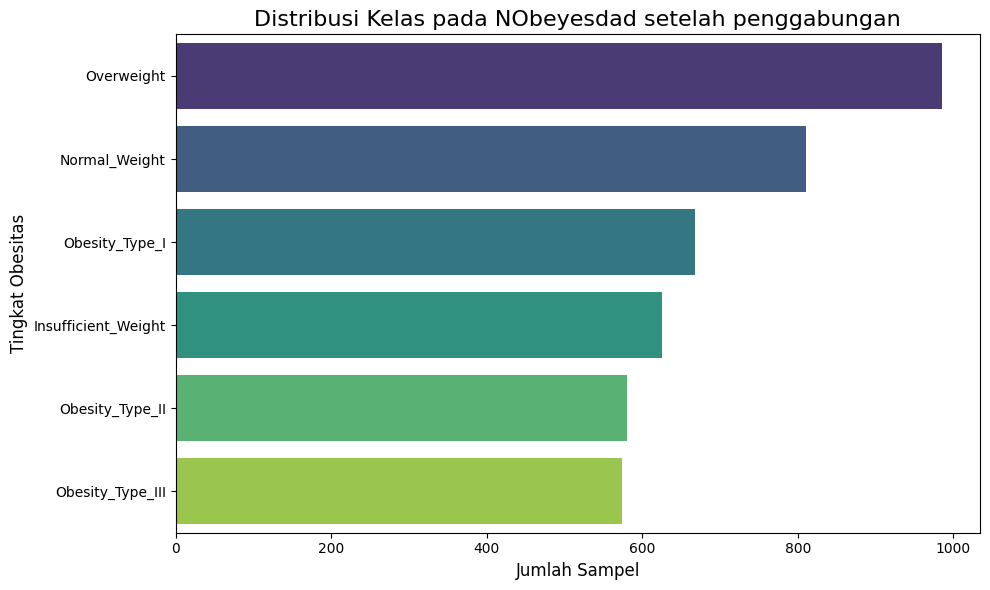

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='NObeyesdad', data=combined_df, palette='viridis', order=combined_df['NObeyesdad'].value_counts().index)
plt.title('Distribusi Kelas pada NObeyesdad setelah penggabungan', fontsize=16)
plt.xlabel('Jumlah Sampel', fontsize=12)
plt.ylabel('Tingkat Obesitas', fontsize=12)
plt.tight_layout()
plt.show()

### PART 3.5 CLEANING AFTER COMBINED DATA


In [ ]:
print(f"Jumlah data awal: {combined_df.shape[0]}")
print(f"Jumlah duplikat: {combined_df.duplicated().sum()}")

combined_df = combined_df.drop_duplicates()

print(f"Jumlah data setelah bersih: {combined_df.shape[0]}")

Jumlah data awal: 4244
Jumlah duplikat: 283
Jumlah data setelah bersih: 3961


In [ ]:
print("\nKomposisi Kelas pada 'NObeyesdad' setelah Cleaning:")
display(combined_df['NObeyesdad'].value_counts())


Komposisi Kelas pada 'NObeyesdad' setelah Cleaning:


,count
NObeyesdad,
Overweight,939
Normal_Weight,811
Obesity_Type_I,638
Insufficient_Weight,594
Obesity_Type_II,529
Obesity_Type_III,450


/tmp/ipython-input-54651343.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='NObeyesdad', data=combined_df, palette='viridis', order=combined_df['NObeyesdad'].value_counts().index)


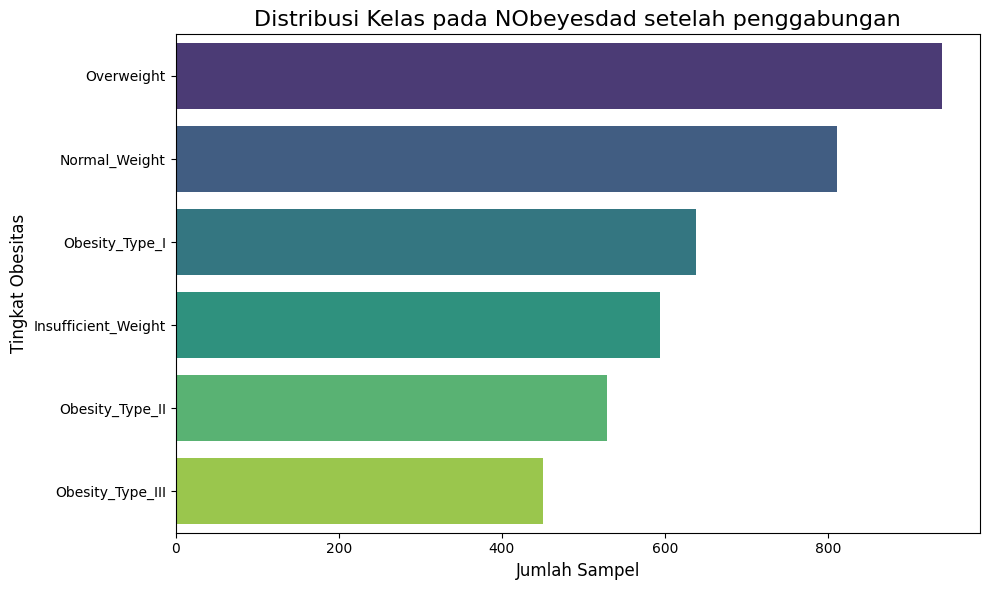

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='NObeyesdad', data=combined_df, palette='viridis', order=combined_df['NObeyesdad'].value_counts().index)
plt.title('Distribusi Kelas pada NObeyesdad setelah penggabungan', fontsize=16)
plt.xlabel('Jumlah Sampel', fontsize=12)
plt.ylabel('Tingkat Obesitas', fontsize=12)
plt.tight_layout()
plt.show()

### PART 3.6 CHECK OUTLIER


--- Visualisasi Outlier dengan Box Plot ---


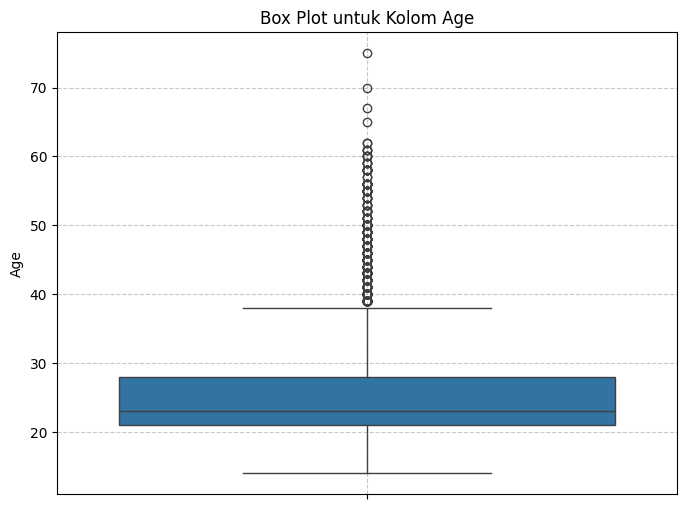

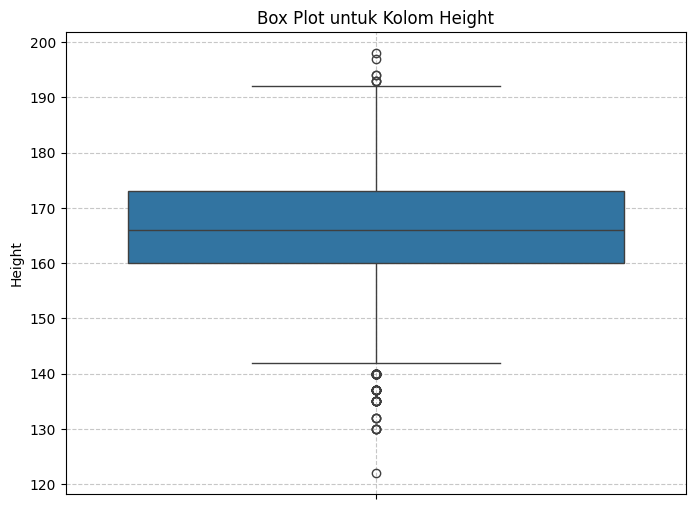

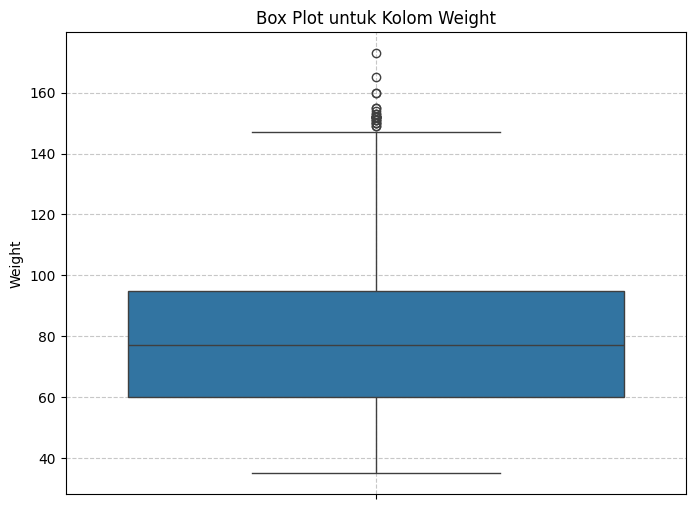


--- Identifikasi Outlier dengan Metode IQR ---

Potensi Outlier di kolom 'Age':


,Age
count,307.000000
mean,46.182410
std,6.794314
min,39.000000
25%,40.000000
50%,44.000000
75%,50.000000
max,75.000000



Potensi Outlier di kolom 'Height':


,Height
count,74.000000
mean,142.837838
std,17.182364
min,122.000000
25%,137.000000
50%,140.000000
75%,140.000000
max,198.000000



Potensi Outlier di kolom 'Weight':


,Weight
count,25.000000
mean,153.800000
std,5.454356
min,149.000000
25%,151.000000
50%,152.000000
75%,154.000000
max,173.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- Visualisasi Outlier dengan Box Plot ---")
numerical_features = combined_df.select_dtypes(include=['int64', 'float64']).columns

for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=combined_df[feature])
    plt.title(f'Box Plot untuk Kolom {feature}')
    plt.ylabel(feature)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
    print("=======================================================================================================")

print("\n--- Identifikasi Outlier dengan Metode IQR ---")

for feature in numerical_features:
    Q1 = combined_df[feature].quantile(0.25)
    Q3 = combined_df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = combined_df[(combined_df[feature] < lower_bound) | (combined_df[feature] > upper_bound)]

    print(f"\nPotensi Outlier di kolom '{feature}':")
    if not outliers.empty:
        display(outliers[[feature]].describe())
    else:
        print(f"Tidak ada outlier yang terdeteksi di kolom '{feature}'.")


### PART 3.7 HEATMAPS

#### HEATMAPS CRAMMER'S V fitur kategorikal

Generating Cramer's V heatmap...


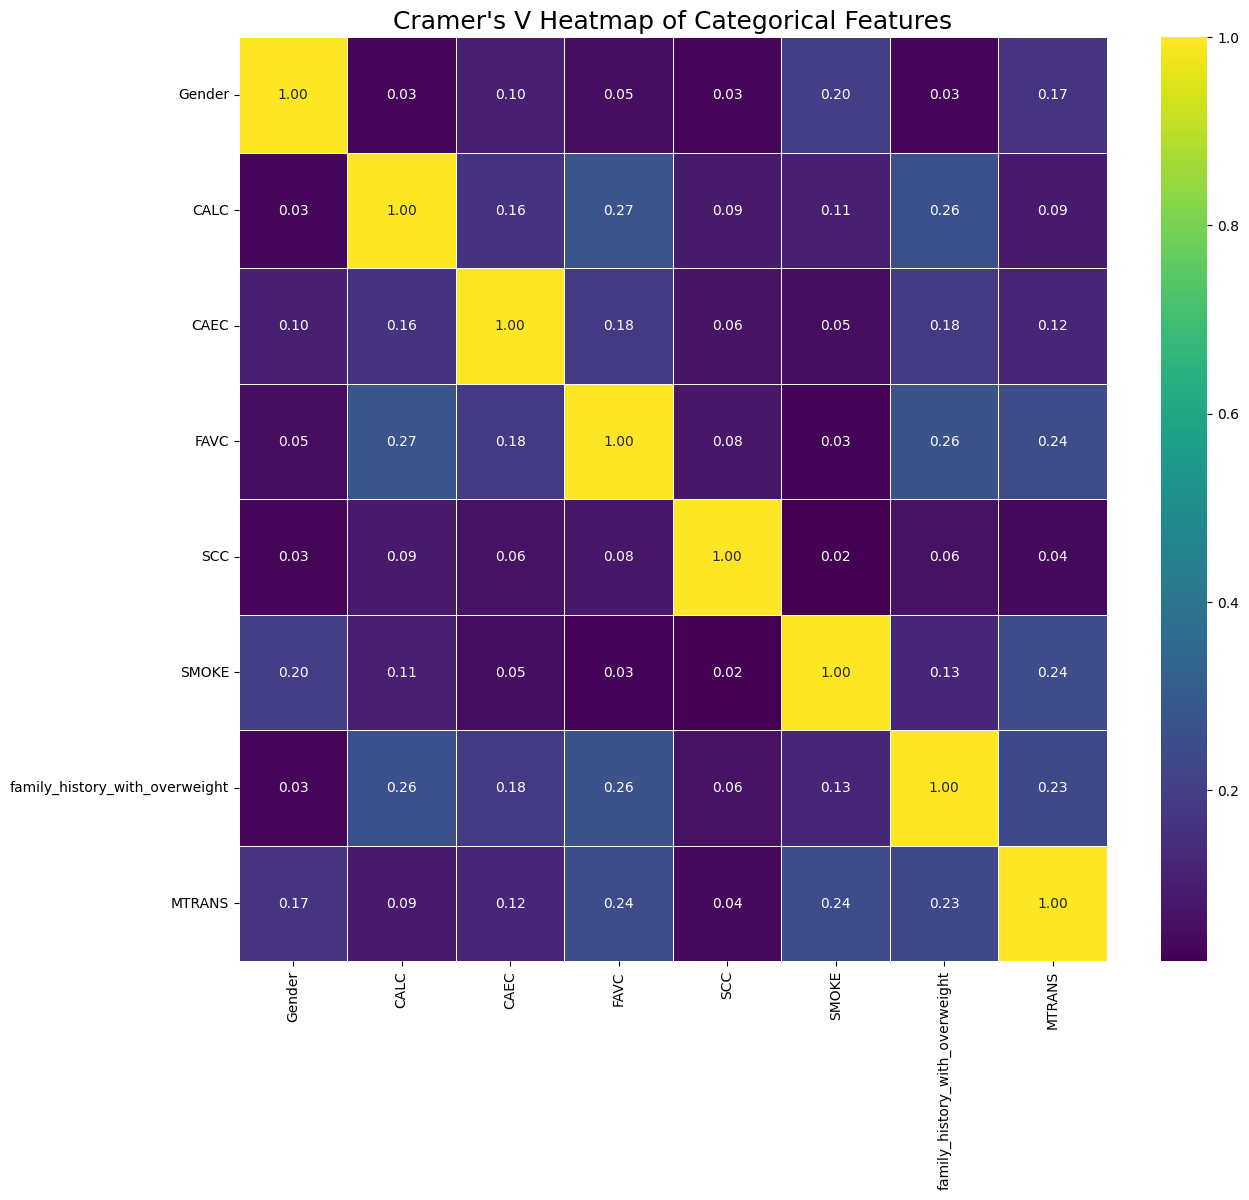

Cramer's V heatmap generated successfully.


In [ ]:
from scipy.stats import chi2_contingency
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v_heatmap(df, categorical_cols):

    print("Generating Cramer's V heatmap...")

    # Filter the DataFrame to include only the specified categorical columns
    df_categorical = df[categorical_cols]

    # Initialize a matrix to store Cramer's V values
    n = len(categorical_cols)
    cramers_v_matrix = np.zeros((n, n))

    # Calculate Cramer's V for each pair of categorical columns
    for i in range(n):
        for j in range(i, n):
            col1 = categorical_cols[i]
            col2 = categorical_cols[j]

            # Create a contingency table
            contingency_table = pd.crosstab(df_categorical[col1], df_categorical[col2])

            # Calculate Chi-squared statistic and p-value
            chi2, p_value, _, _ = chi2_contingency(contingency_table)

            # Calculate the number of observations
            num_observations = contingency_table.sum().sum()

            # Calculate the minimum of (rows - 1) and (columns - 1)
            min_dim = min(contingency_table.shape) - 1

            # Avoid division by zero
            if num_observations * min_dim == 0:
                cramers_v = 0.0
            else:
                # Calculate Cramer's V
                cramers_v = np.sqrt(chi2 / (num_observations * min_dim))

            cramers_v_matrix[i, j] = cramers_v_matrix[j, i] = cramers_v

    # Create a DataFrame for the heatmap
    cramers_v_df = pd.DataFrame(cramers_v_matrix, index=categorical_cols, columns=categorical_cols)

    # Plot the heatmap
    plt.figure(figsize=(14, 12))
    sns.heatmap(cramers_v_df, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
    plt.title("Cramer's V Heatmap of Categorical Features", fontsize=18)
    plt.show()
    print("Cramer's V heatmap generated successfully.")

# Identify categorical features from combined_df
categorical_cols = ['Gender','CALC', 'CAEC','FAVC','SCC','SMOKE','family_history_with_overweight','MTRANS']

# Remove the target variable if it's present in the categorical features list
if 'NObeyesdad' in categorical_cols:
    categorical_cols.remove('NObeyesdad')

# Generate the Cramer's V heatmap
cramers_v_heatmap(combined_df, categorical_cols)

#### HEATMAPS PERSON fitur numerik


--- Heatmap Korelasi Antar Fitur (Age, Height, Weight) ---


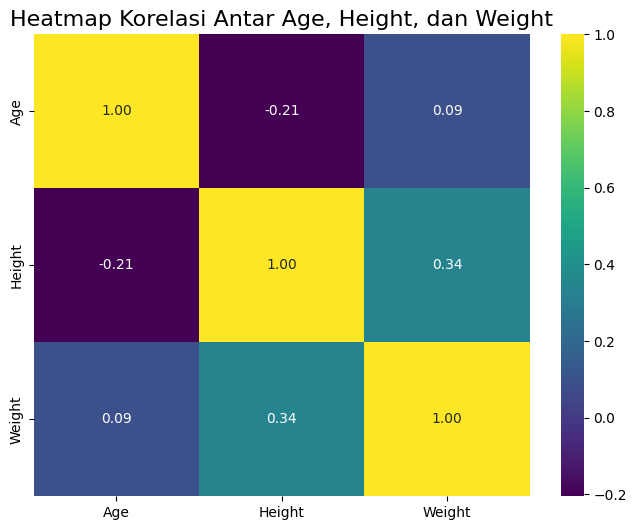

In [ ]:
print("\n--- Heatmap Korelasi Antar Fitur (Age, Height, Weight) ---")

# Select only the desired numerical features
df_selected_numerical = combined_df[['Age', 'Height', 'Weight']].copy()

plt.figure(figsize=(8, 6))
sns.heatmap(df_selected_numerical.corr(), annot=True, cmap='viridis', fmt=".2f")
plt.title('Heatmap Korelasi Antar Age, Height, dan Weight', fontsize=16)
plt.show()

#### HEATMAPS SPEARMAN fitur Ordinal


--- Heatmap Korelasi Spearman Fitur Ordinal ---



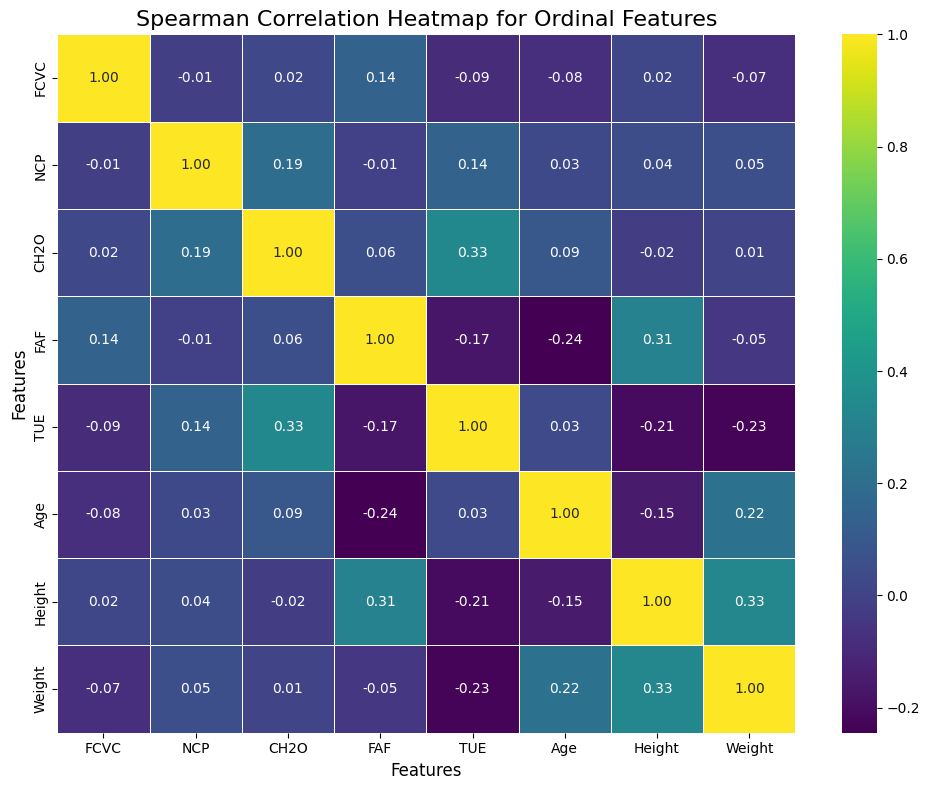

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n--- Heatmap Korelasi Spearman Fitur Ordinal ---\n")

ordinal_features = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE','Age','Height','Weight']

# Create a copy of the DataFrame for encoding ordinal features
df_ordinal_encoded = combined_df[ordinal_features].copy()

# Define explicit mappings for ordinal features
mapping_ordinal = {
    'FCVC': {'1': 1, '2': 2, '3': 3},
    'NCP': {'1': 1, '2': 2, '3': 3, '4': 4},
    'CH2O': {'1': 1, '2': 2, '3': 3},
    'FAF': {'0': 0, '1': 1, '2': 2, '3': 3},
    'TUE': {'0': 0, '1': 1, '2': 2}
}

# Apply the mappings to the copied DataFrame
for col, mapping in mapping_ordinal.items():
    df_ordinal_encoded[col] = df_ordinal_encoded[col].map(mapping)

# Calculate Spearman correlation
spearman_corr = df_ordinal_encoded.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(spearman_corr, annot=True, cmap='viridis', fmt=".2f", linewidths=.5)
plt.title('Spearman Correlation Heatmap for Ordinal Features', fontsize=16)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

## PART 4 SPLIT INTO X AND Y

In [ ]:
X_transformed = combined_df.drop('NObeyesdad', axis=1)
y =  combined_df['NObeyesdad']
categorical_features = ['Gender','family_history_with_overweight', 'FAVC', 'FCVC','NCP','CAEC', 'CALC','MTRANS','CH2O','FAF','TUE'] # Memisahkan data yang categorical

#### Visualitation Data

In [ ]:
print(combined_df.head())

   Age  Gender  Height  Weight        CALC FAVC FCVC NCP  SCC SMOKE CH2O  \
0   21  Female     162      64          no   no    2   3   no    no    2   
1   21  Female     152      56   Sometimes   no    3   3  yes   yes    3   
2   23    Male     180      77  Frequently   no    2   3   no    no    2   
3   27    Male     180      87  Frequently   no    3   3   no    no    2   
4   22    Male     178      89   Sometimes   no    2   1   no    no    2   

  family_history_with_overweight FAF TUE       CAEC                 MTRANS  \
0                            yes   0   1  Sometimes  Public_Transportation   
1                            yes   3   0  Sometimes  Public_Transportation   
2                            yes   2   1  Sometimes  Public_Transportation   
3                             no   2   0  Sometimes                Walking   
4                             no   0   0  Sometimes  Public_Transportation   

      NObeyesdad  
0  Normal_Weight  
1  Normal_Weight  
2  Normal_Weight 


Memulai proses penampilan plot...
Tutup jendela plot yang muncul untuk melanjutkan ke plot berikutnya.


/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


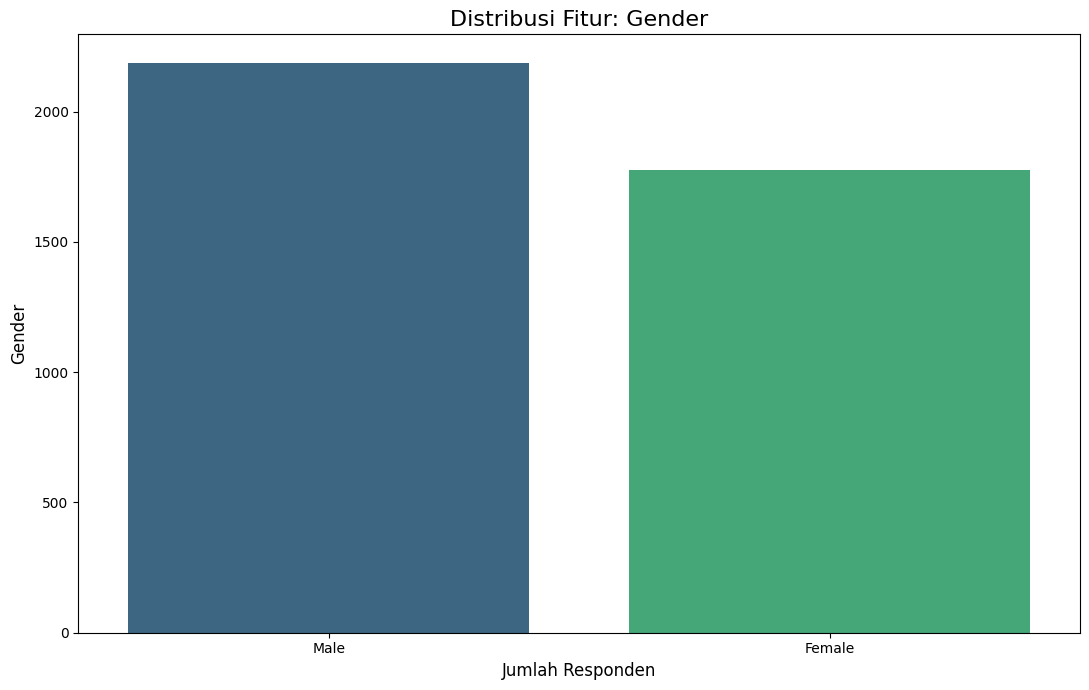

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


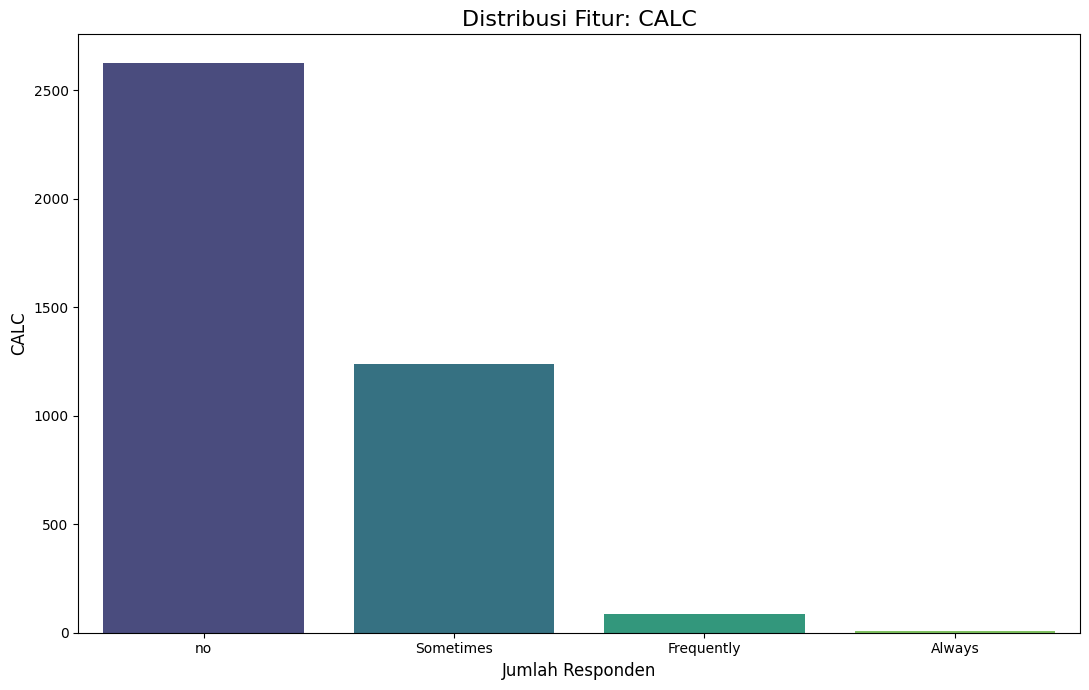

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


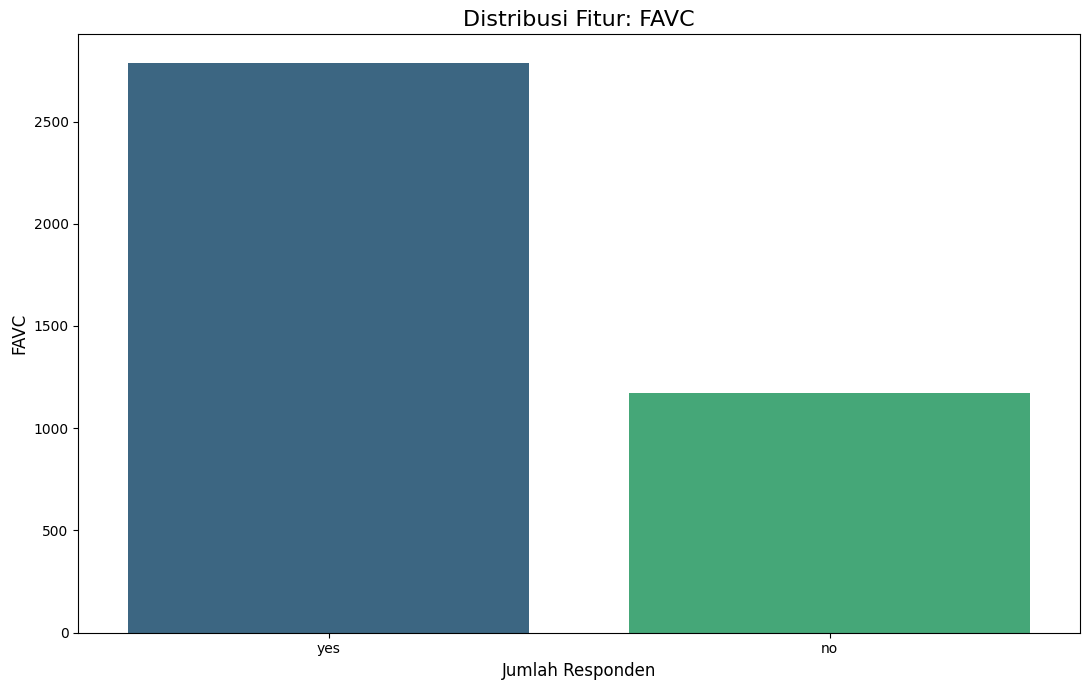

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


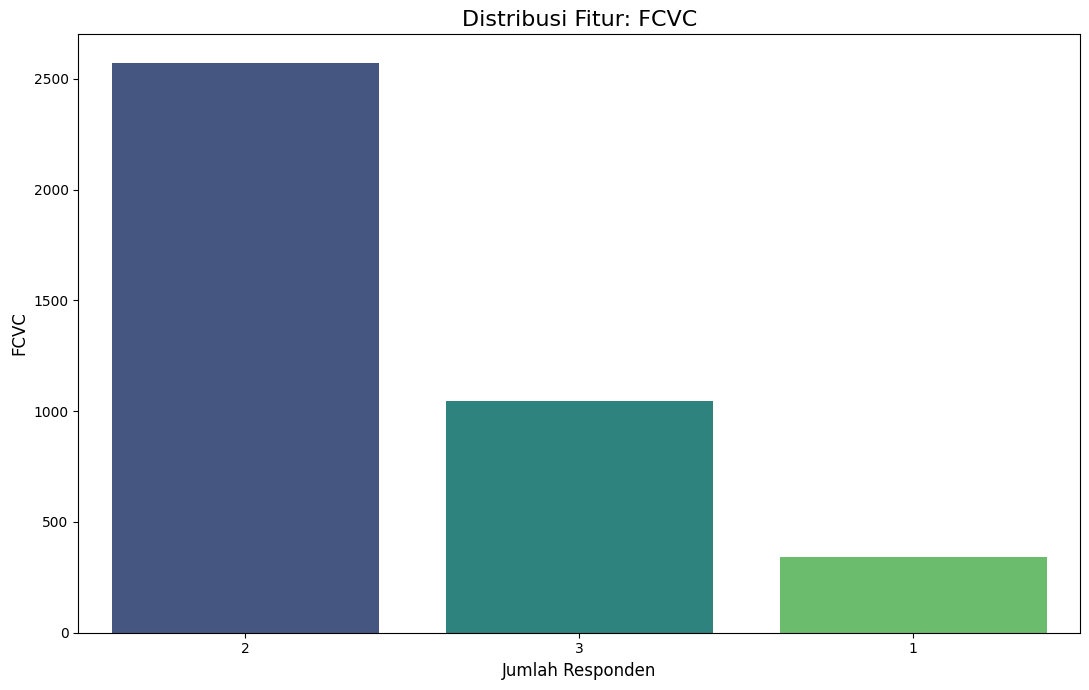

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


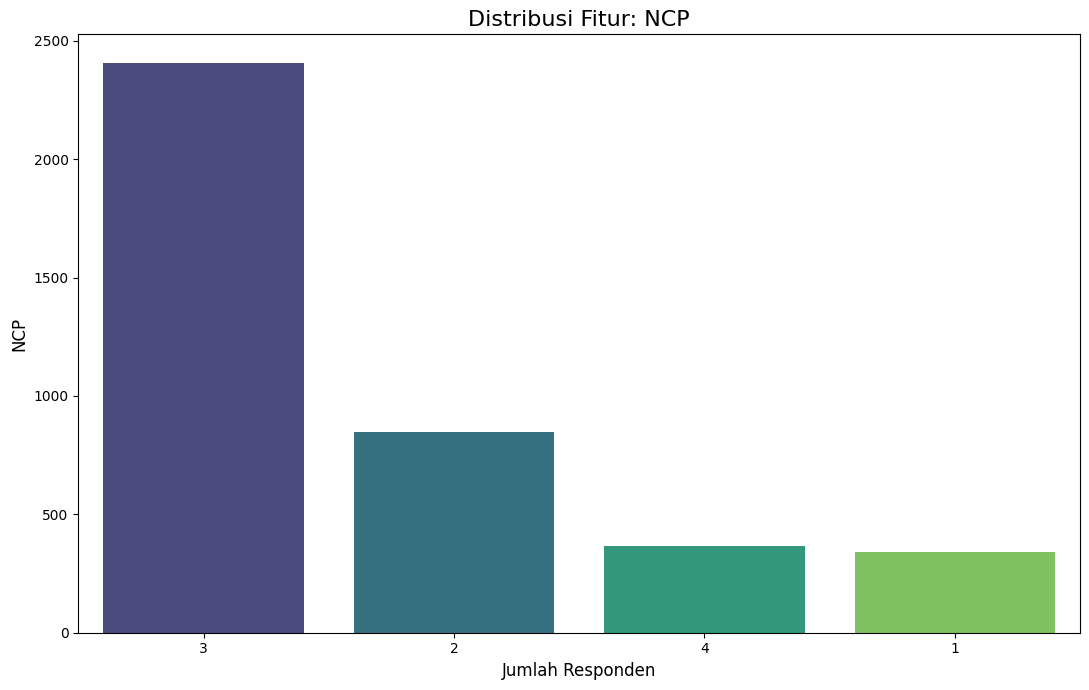

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


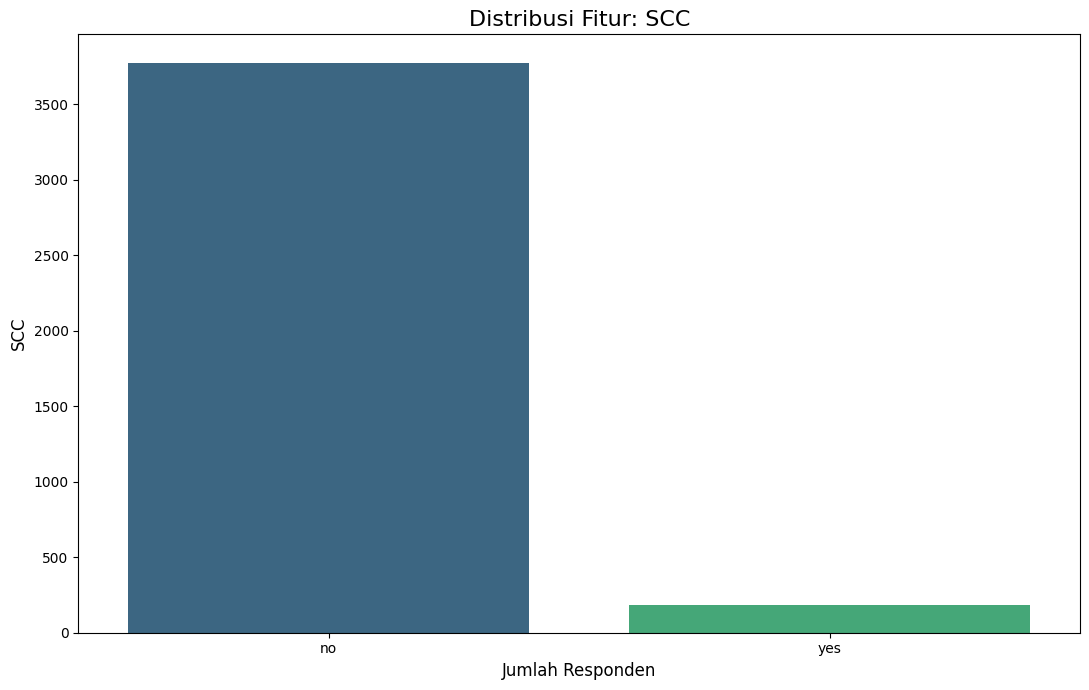

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


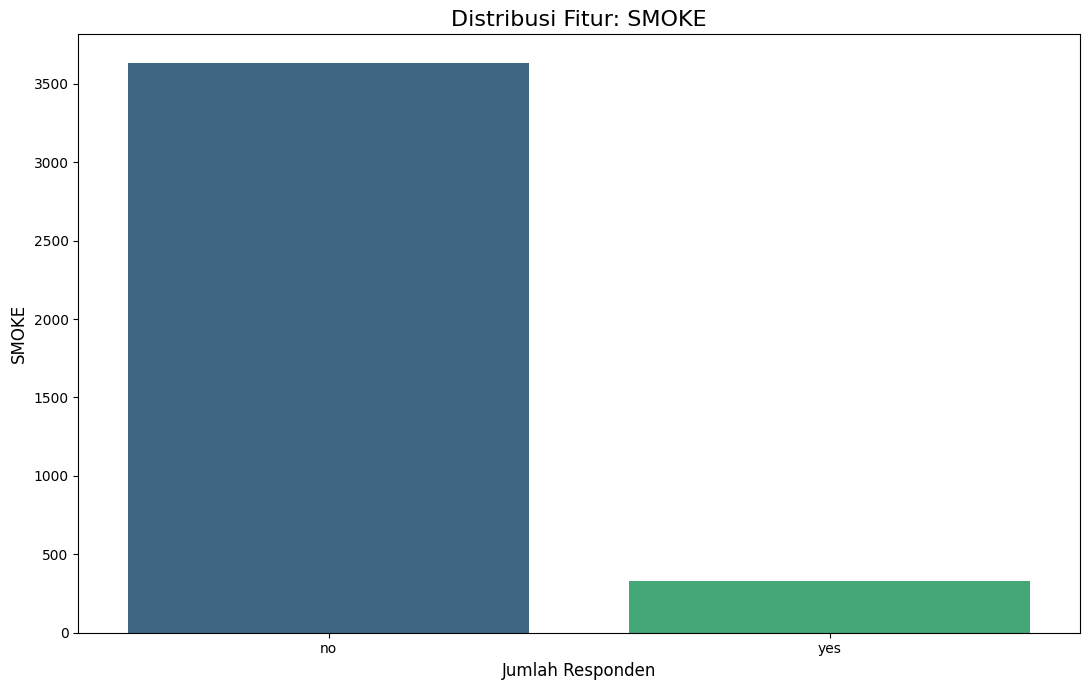

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


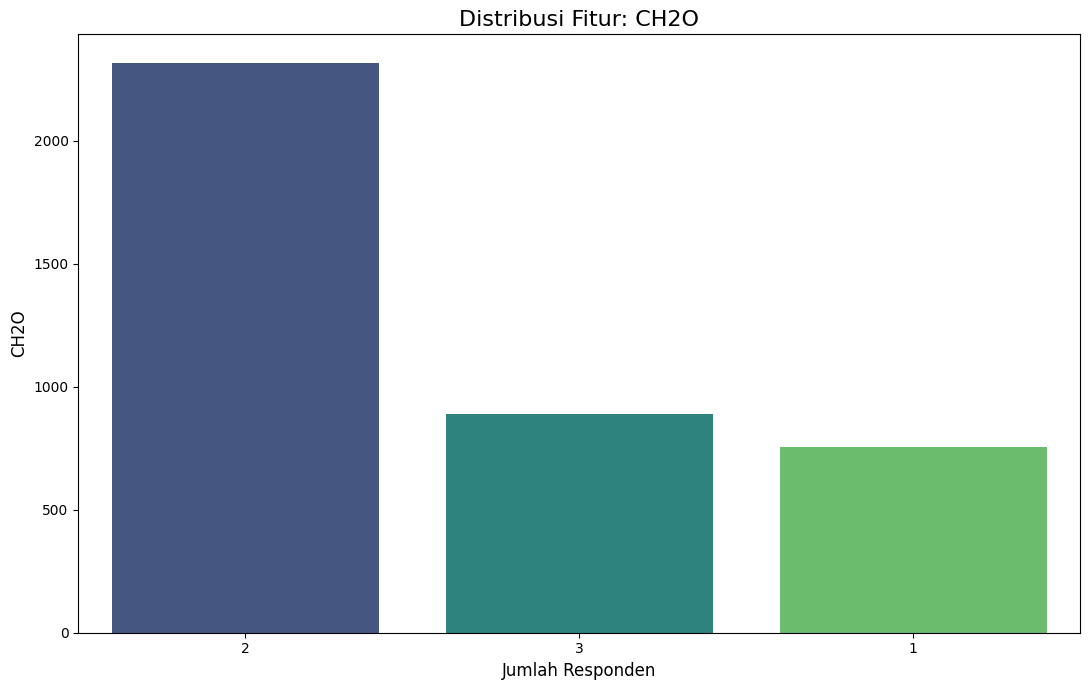

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


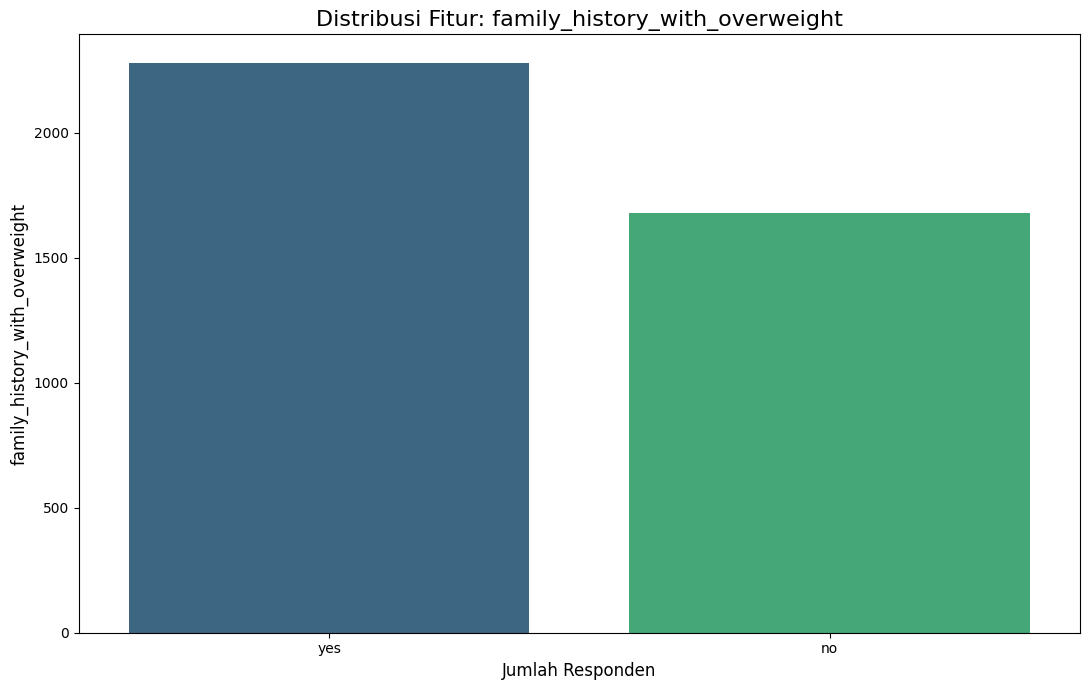

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


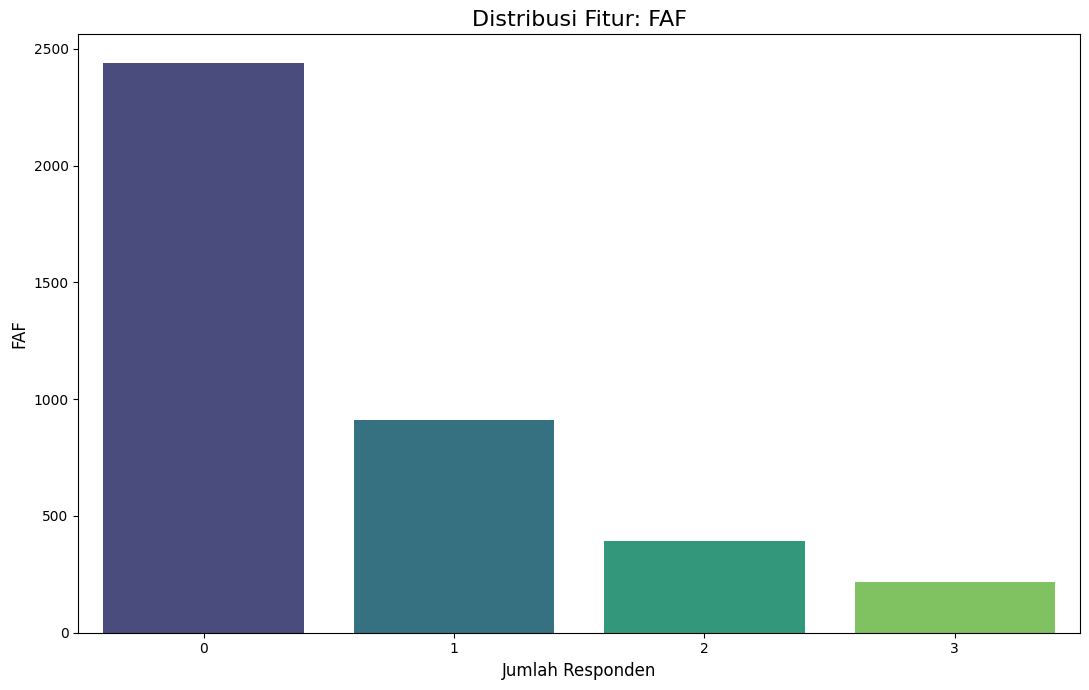

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


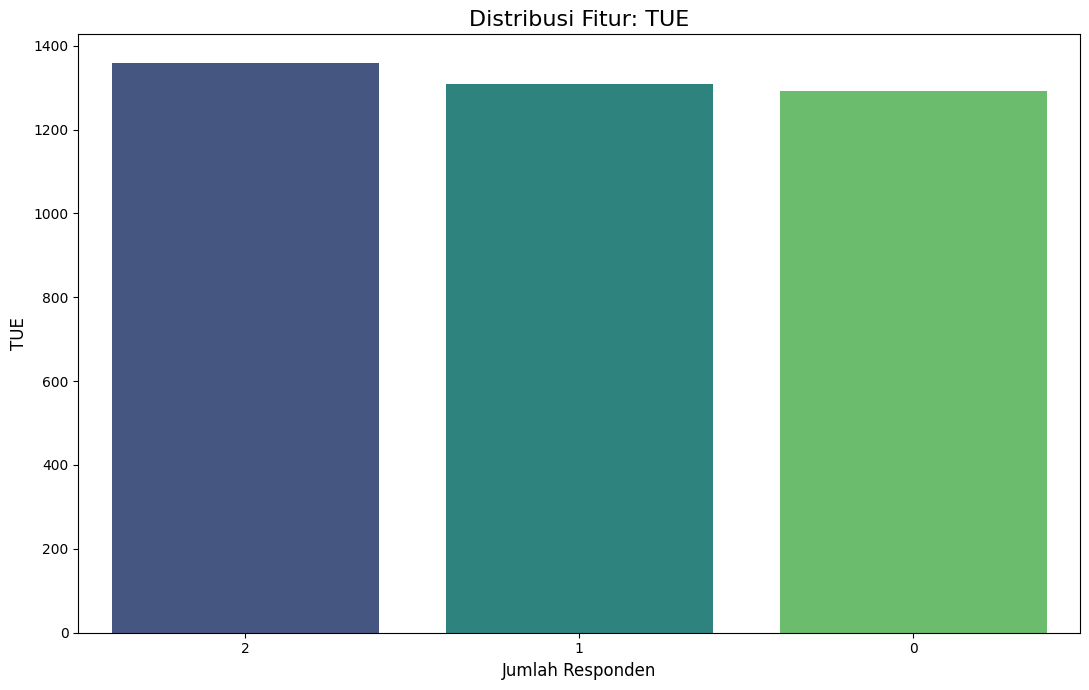

/tmp/ipython-input-1196374594.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


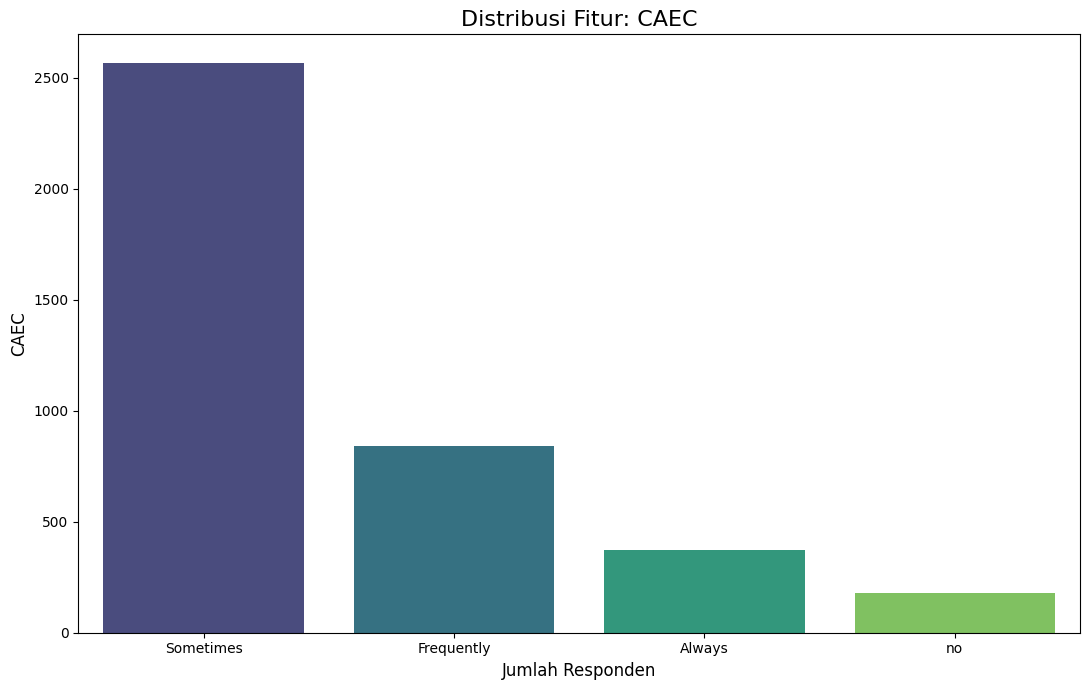

/tmp/ipython-input-1196374594.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


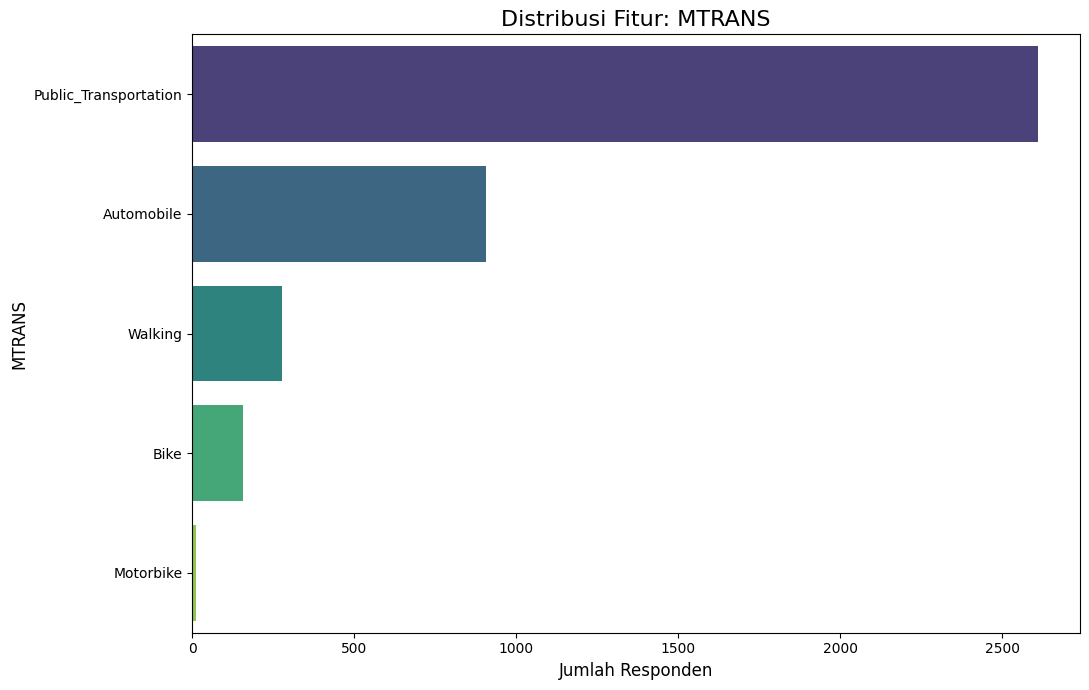

/tmp/ipython-input-1196374594.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)


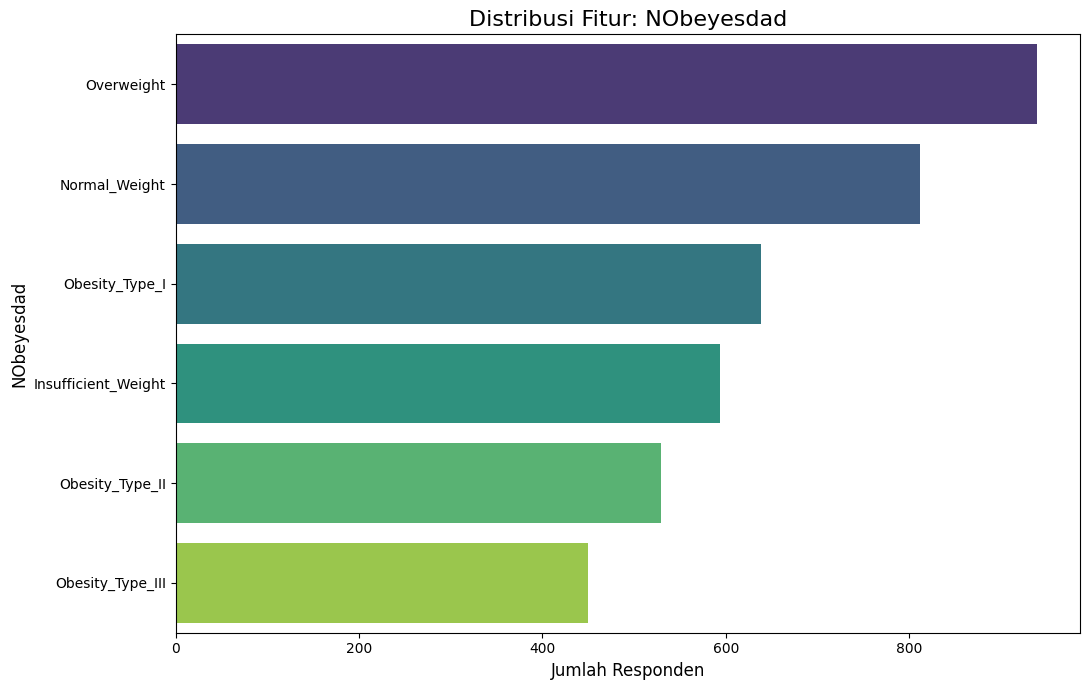

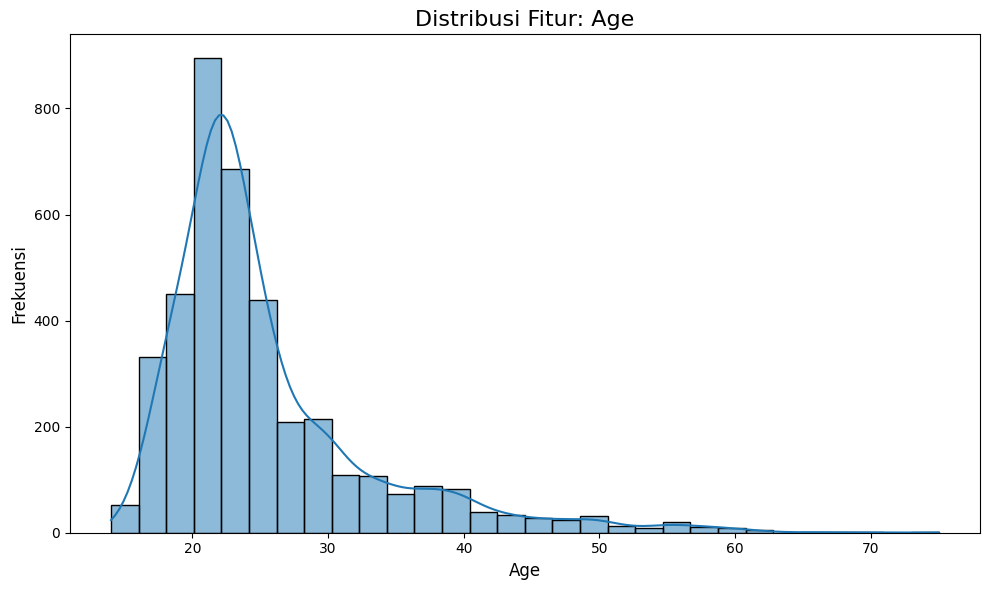

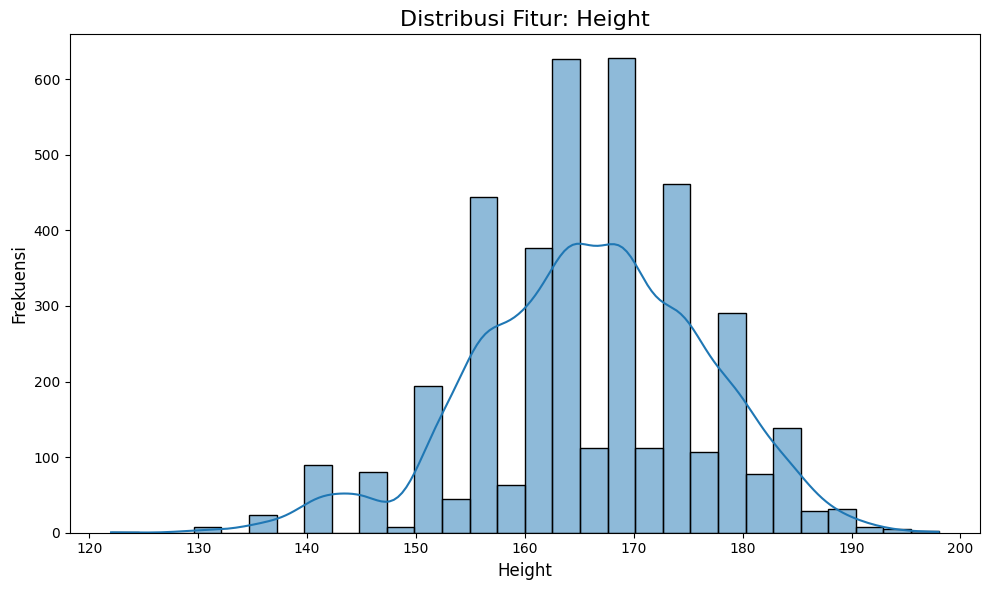

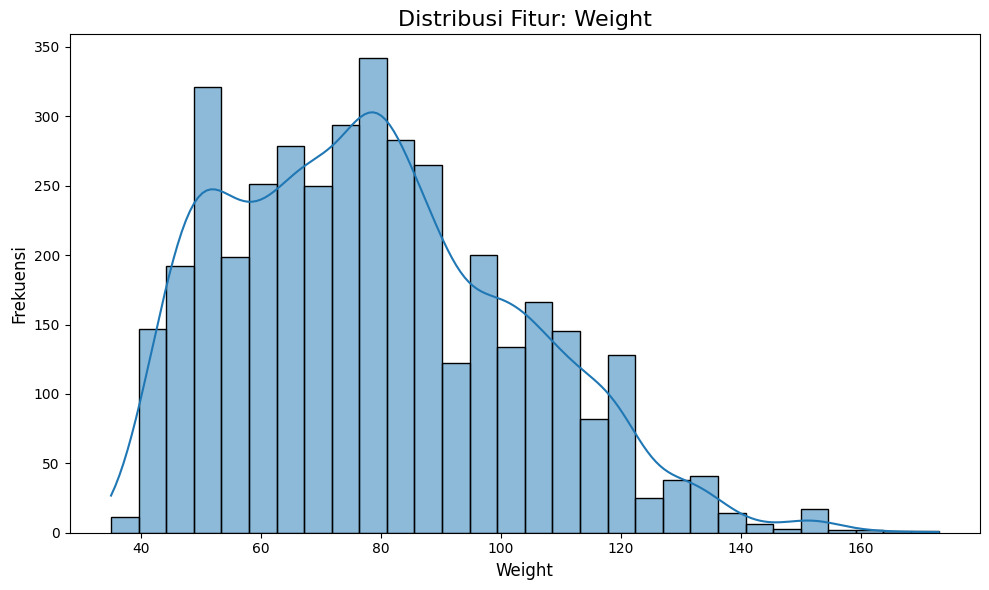

In [ ]:
def tampilkan_visualisasi_semua_fitur():

    categorical_feature = combined_df.select_dtypes(include=['object']).columns
    numerical_features = combined_df.select_dtypes(include=['number']).columns

    print("\nMemulai proses penampilan plot...")
    print("Tutup jendela plot yang muncul untuk melanjutkan ke plot berikutnya.")

    for feature in categorical_feature:
        plt.figure(figsize=(11, 7))
        if combined_df[feature].nunique() > 4:
            sns.countplot(y=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)
        else:
            sns.countplot(x=feature, data=combined_df, palette='viridis', order=combined_df[feature].value_counts().index)

        plt.title(f'Distribusi Fitur: {feature}', fontsize=16)
        plt.xlabel('Jumlah Responden', fontsize=12)
        plt.ylabel(feature, fontsize=12)
        plt.tight_layout()
        plt.show()

    for feature in numerical_features:
        plt.figure(figsize=(10, 6))
        sns.histplot(combined_df[feature], kde=True, bins=30)
        plt.title(f'Distribusi Fitur: {feature}', fontsize=16)
        plt.xlabel(feature, fontsize=12)
        plt.ylabel('Frekuensi', fontsize=12)
        plt.tight_layout()
        plt.show()

if __name__ == '__main__':
    tampilkan_visualisasi_semua_fitur()

## PART 5 SPLIT INTO TRAIN, VALIDATION, TEST

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_transformed, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"X_train: {X_train.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

X_train: (3168, 16)
X_val: (396, 16)
X_test: (397, 16)


## PART 6 SMOTENC OVERSAMPLING

In [ ]:
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import LabelEncoder

print("Distribusi kelas sebelum SMOTE (y_train):")
print(y_train.value_counts())

sm = SMOTENC(categorical_features = categorical_features, random_state=42, k_neighbors=5, sampling_strategy='auto')

X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

print("\nDistribusi kelas setelah SMOTE (y_train_smote):\n", y_train_smote.value_counts())



Distribusi kelas sebelum SMOTE (y_train):
NObeyesdad
Overweight             751
Normal_Weight          649
Obesity_Type_I         510
Insufficient_Weight    475
Obesity_Type_II        423
Obesity_Type_III       360
Name: count, dtype: int64

Distribusi kelas setelah SMOTE (y_train_smote):
 NObeyesdad
Obesity_Type_III       751
Overweight             751
Obesity_Type_II        751
Obesity_Type_I         751
Insufficient_Weight    751
Normal_Weight          751
Name: count, dtype: int64


### PART 6.1 CHECKING TRAIN SET BEFORE-AFTER SMOTE

In [ ]:
print(X_train_smote.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4506 entries, 0 to 4505
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             4506 non-null   int64 
 1   Gender                          4506 non-null   object
 2   Height                          4506 non-null   int64 
 3   Weight                          4506 non-null   int64 
 4   CALC                            4506 non-null   object
 5   FAVC                            4506 non-null   object
 6   FCVC                            4506 non-null   object
 7   NCP                             4506 non-null   object
 8   SCC                             4506 non-null   object
 9   SMOKE                           4506 non-null   object
 10  CH2O                            4506 non-null   object
 11  family_history_with_overweight  4506 non-null   object
 12  FAF                             4506 non-null   

/tmp/ipython-input-2439708162.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=y_train_smote, palette='viridis', order=y_train_smote.value_counts().index)


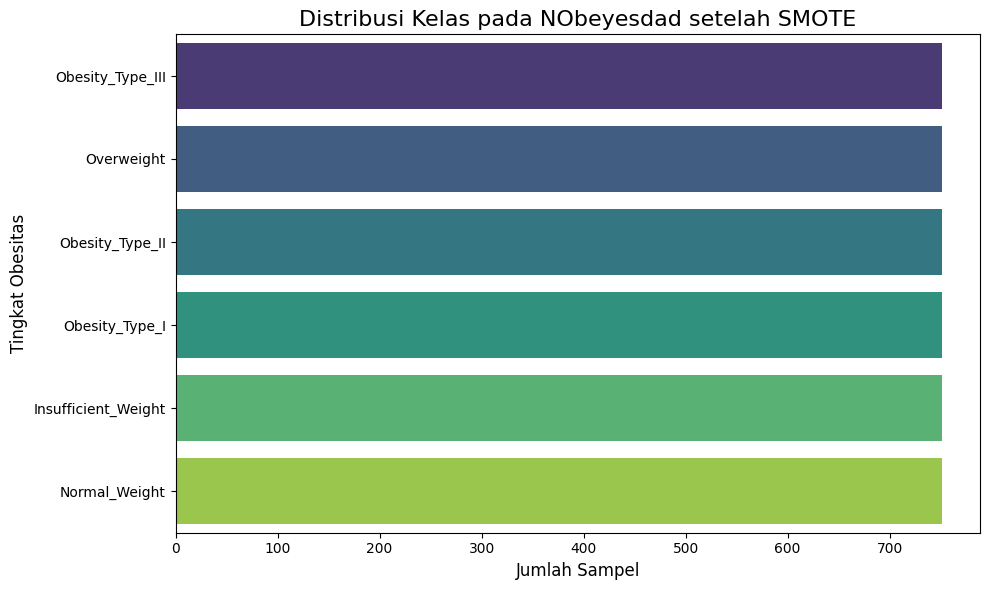

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y=y_train_smote, palette='viridis', order=y_train_smote.value_counts().index)
plt.title('Distribusi Kelas pada NObeyesdad setelah SMOTE', fontsize=16)
plt.xlabel('Jumlah Sampel', fontsize=12)
plt.ylabel('Tingkat Obesitas', fontsize=12)
plt.tight_layout()
plt.show()

#### PART 6.1.1 BEFORE SMOTE


Memulai proses penampilan plot untuk X_train_smote...
Tutup jendela plot yang muncul untuk melanjutkan ke plot berikutnya.


/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


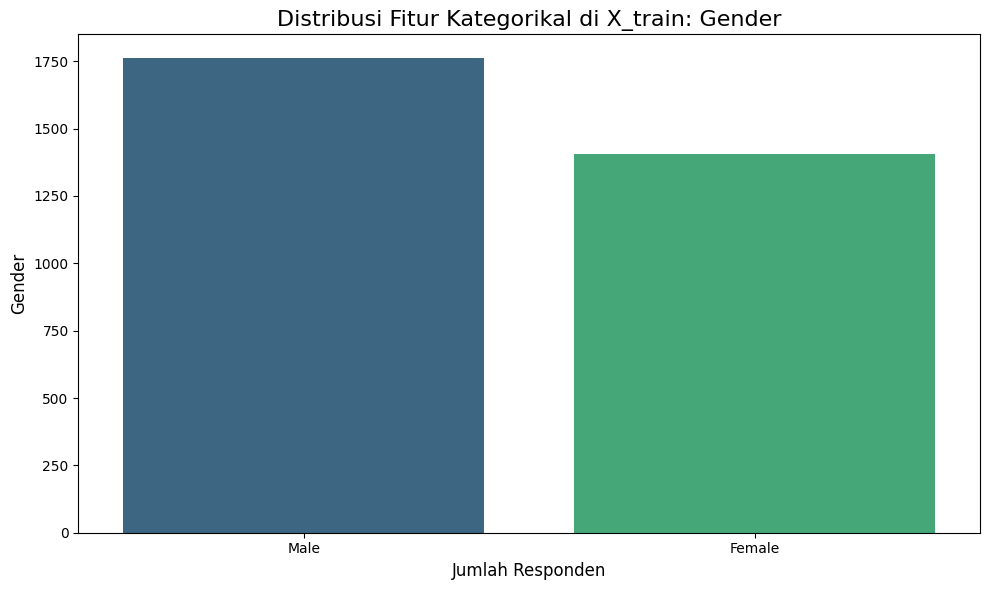

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


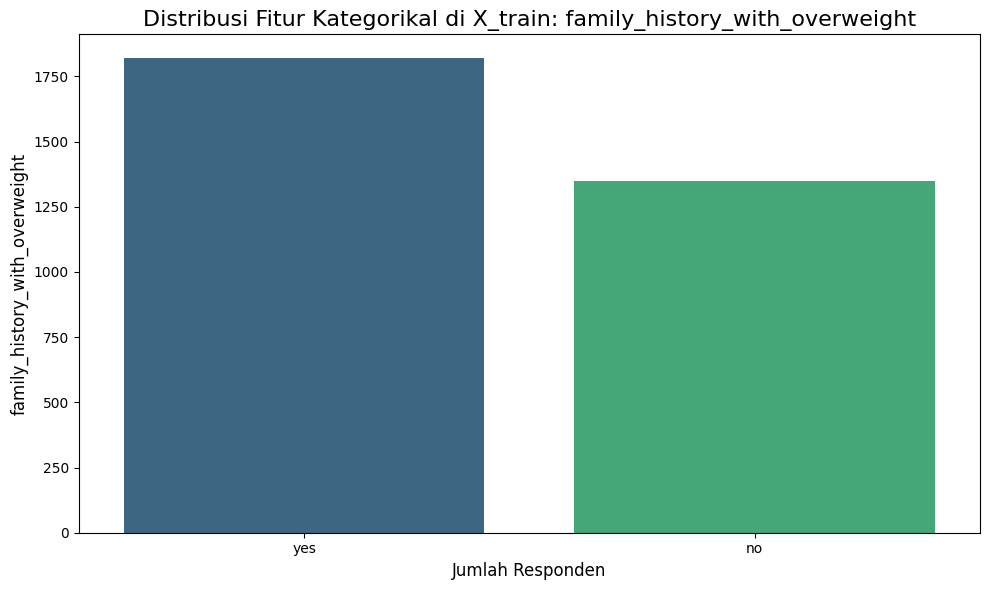

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


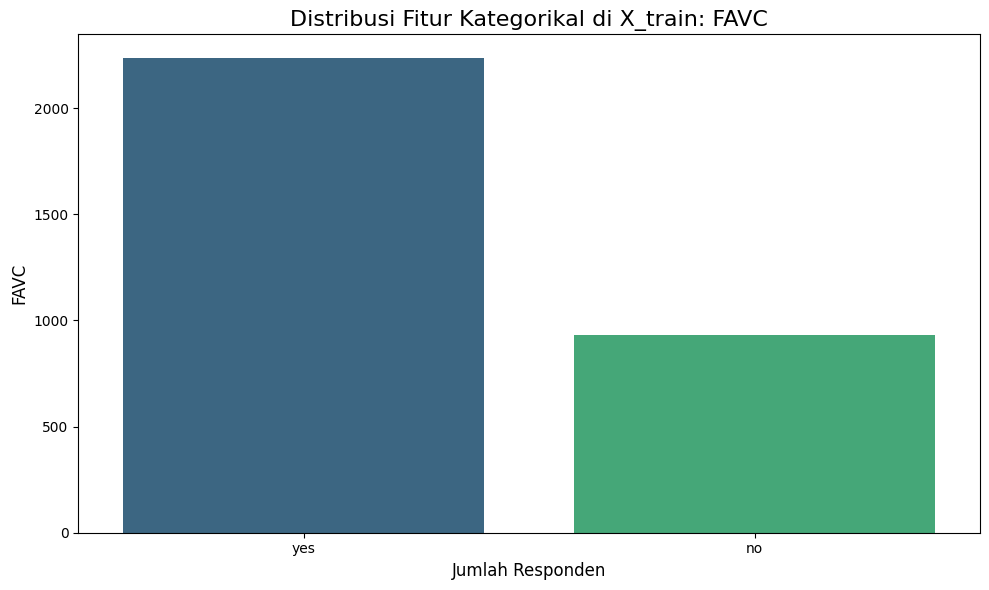

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


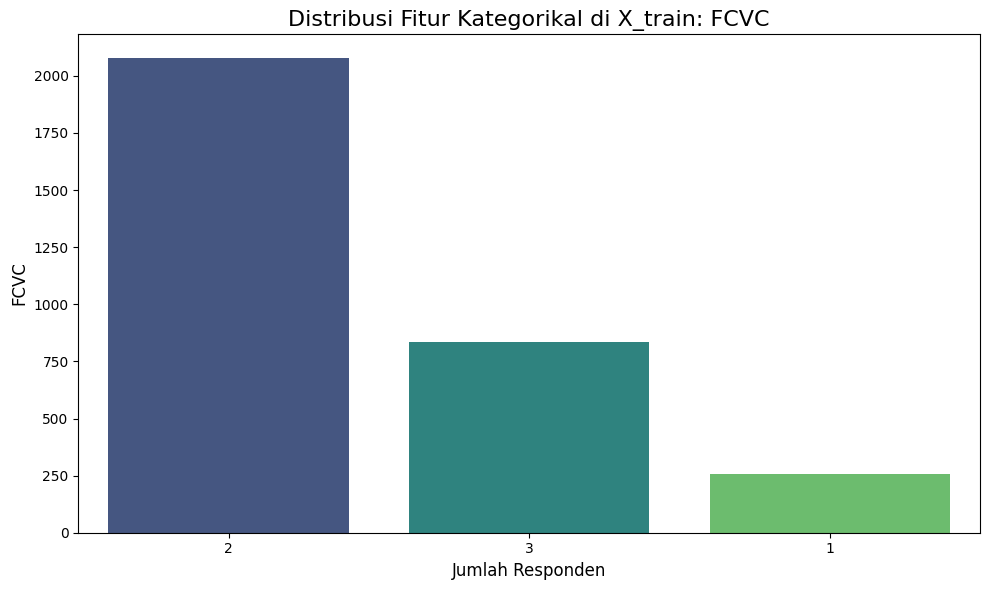

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


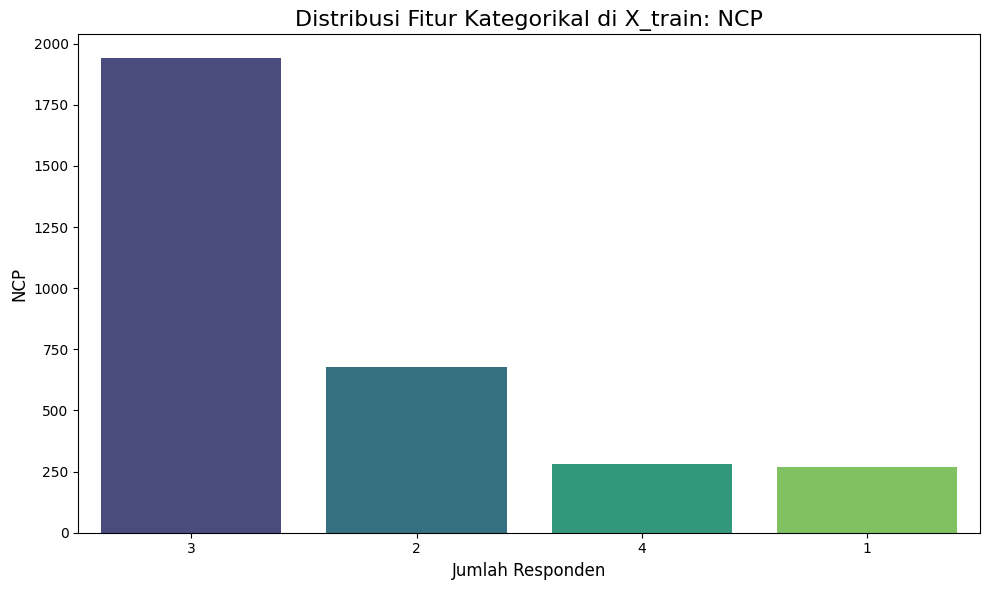

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


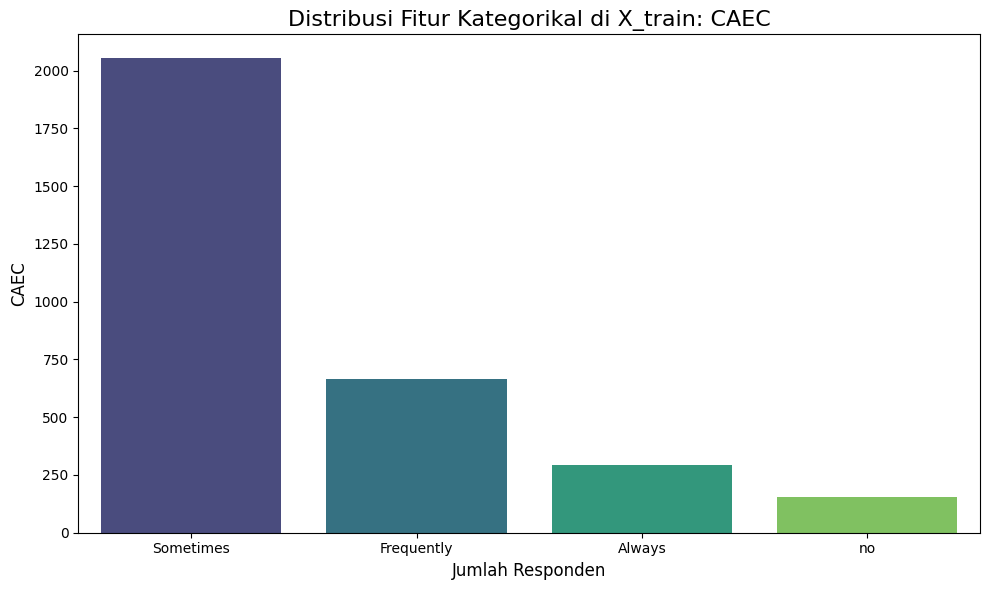

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


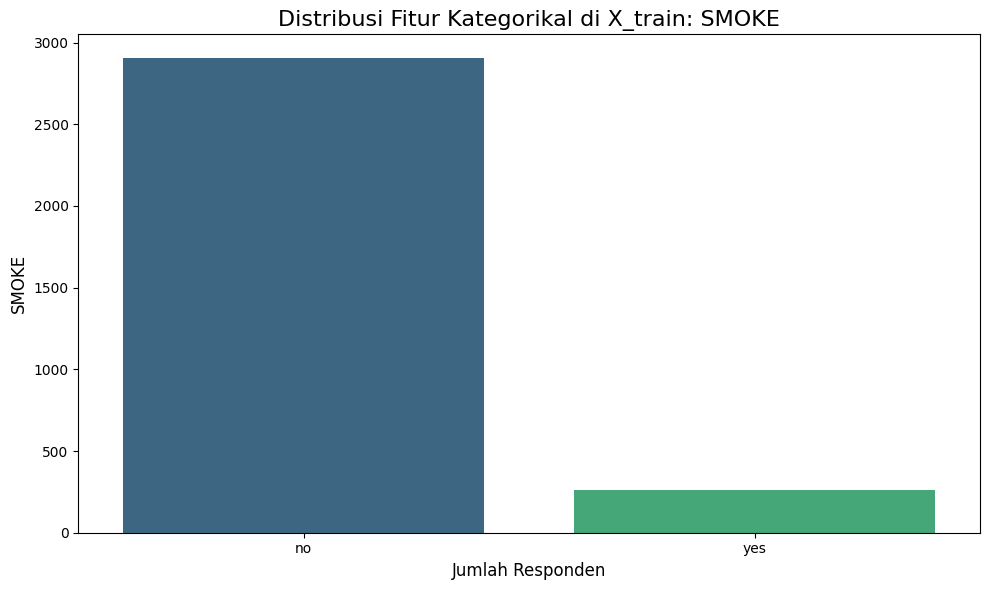

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


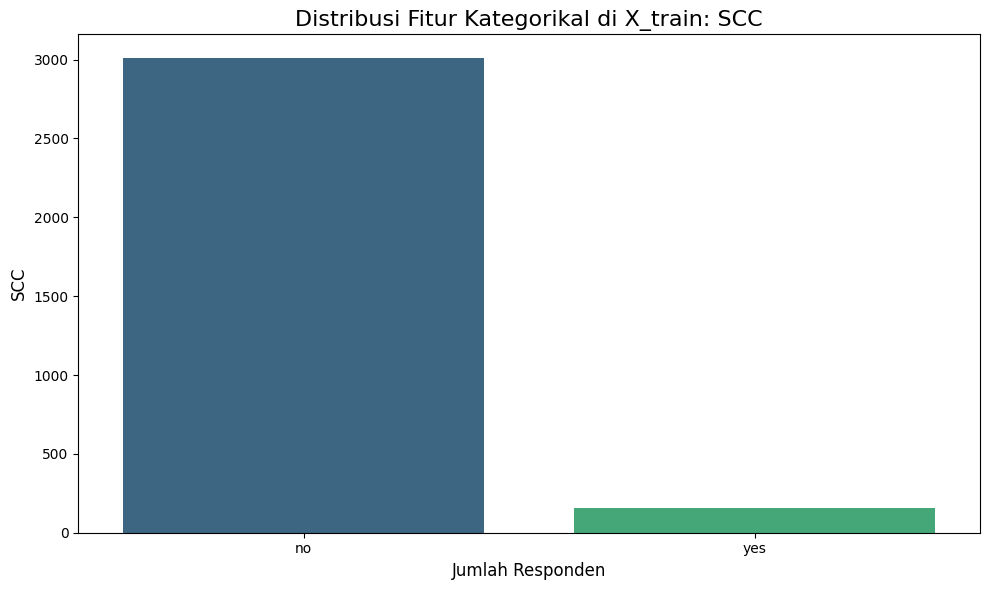

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


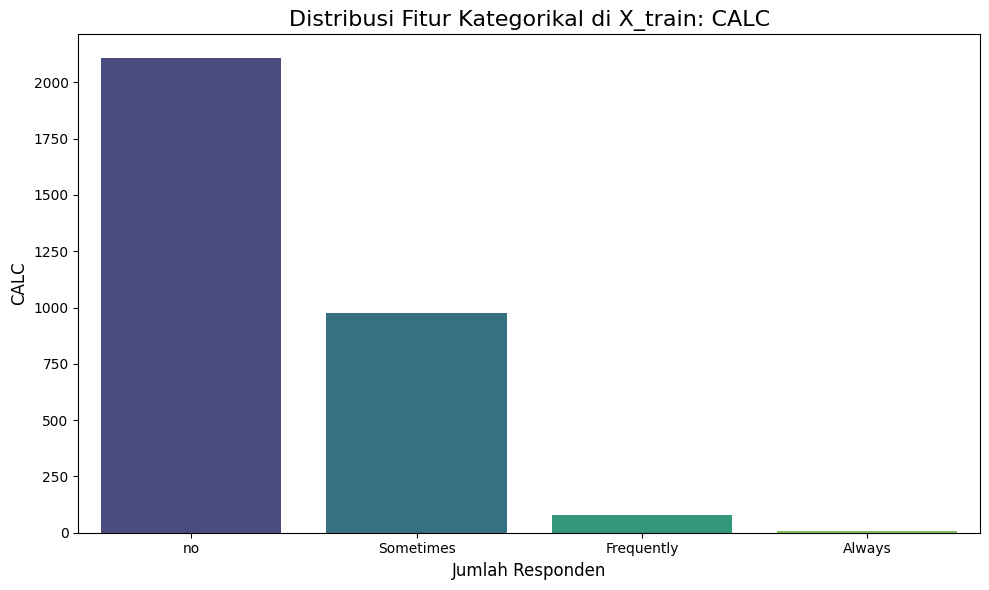

/tmp/ipython-input-441845417.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


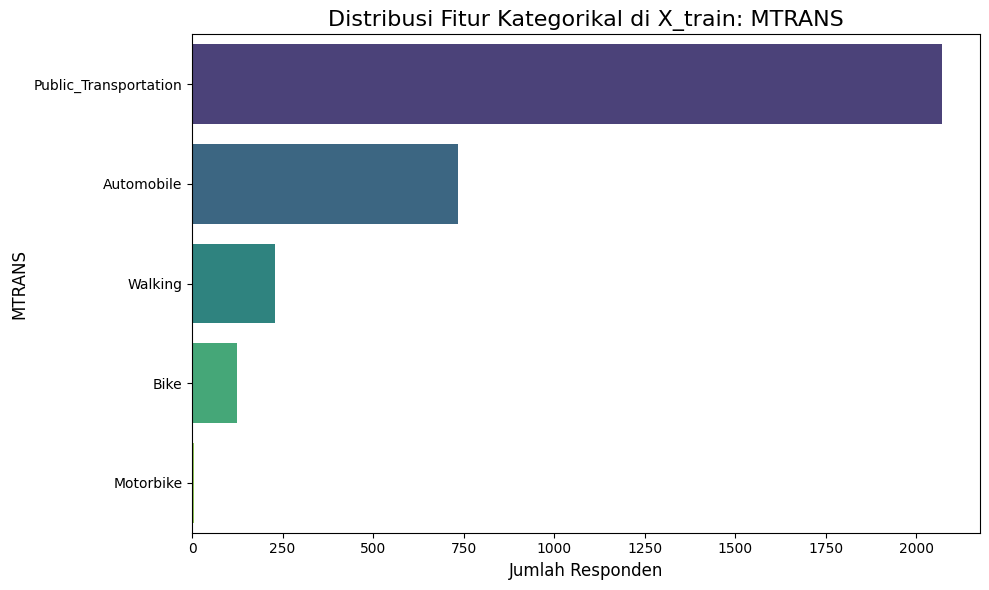

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


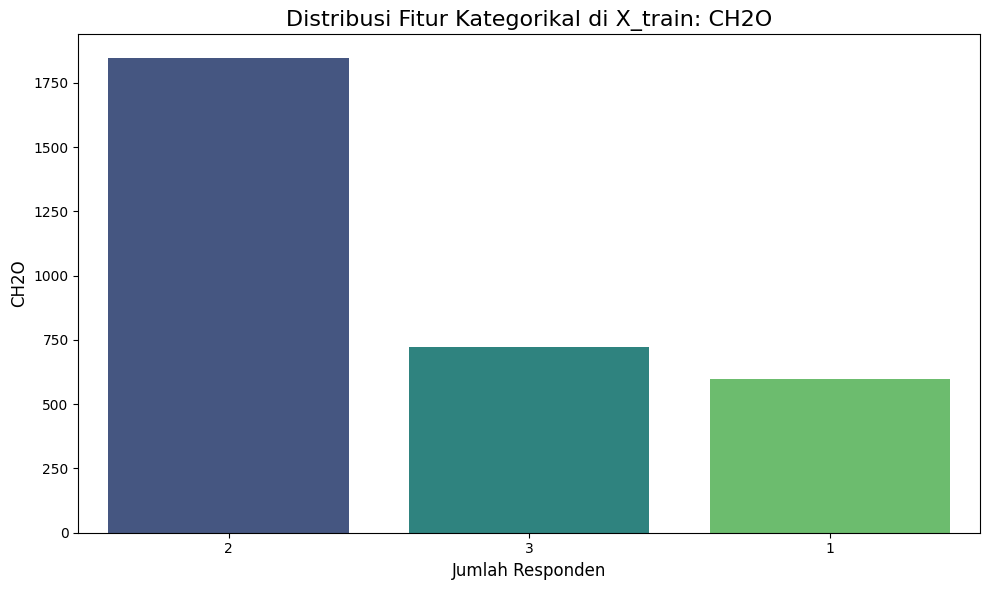

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


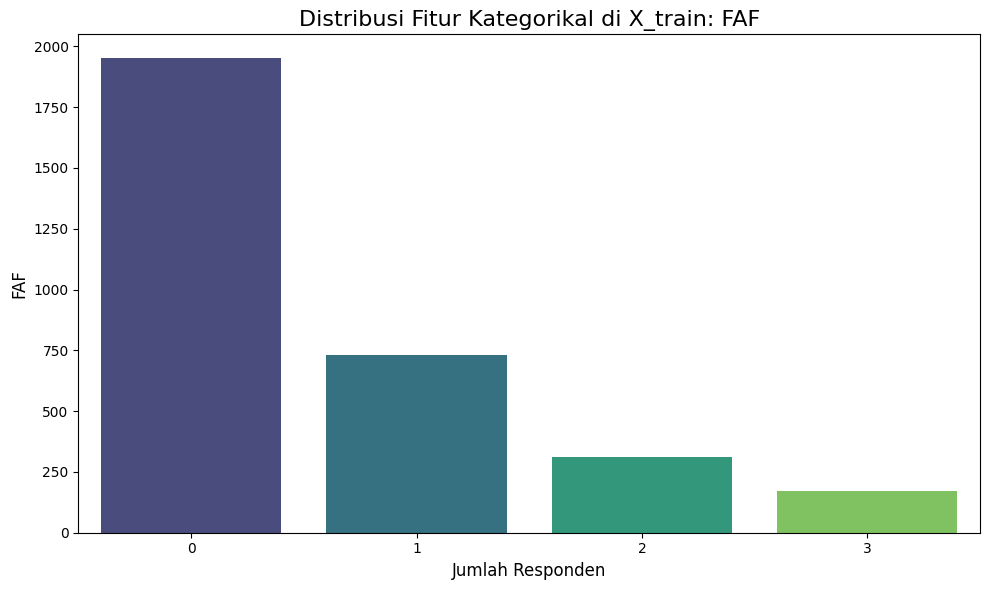

/tmp/ipython-input-441845417.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)


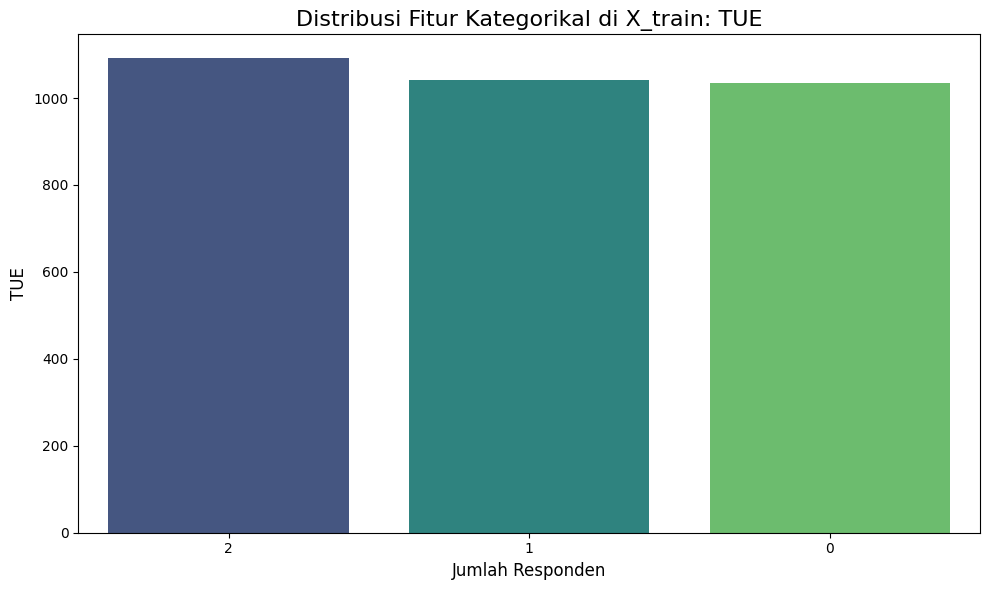

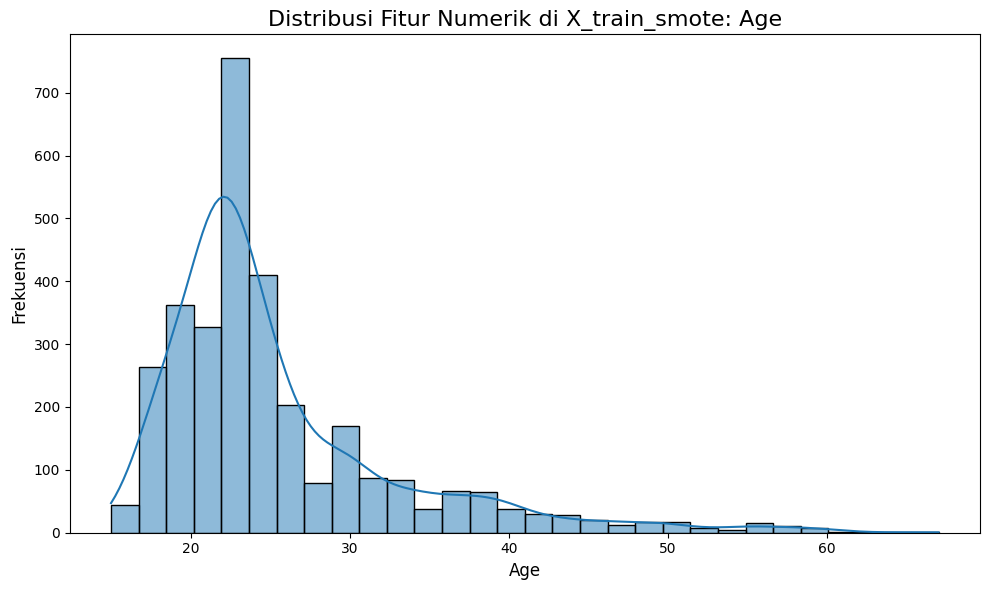

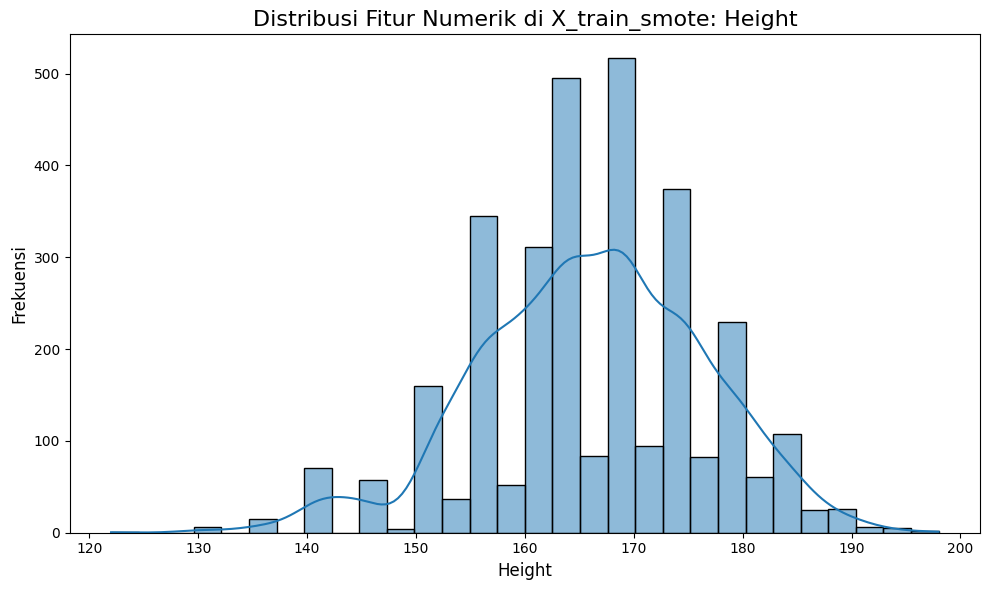

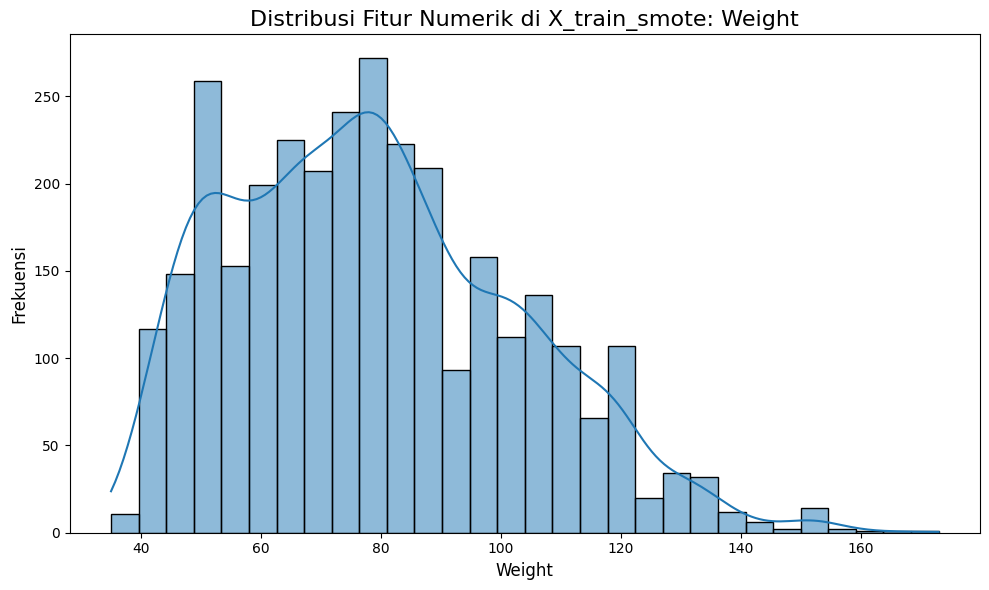

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nMemulai proses penampilan plot untuk X_train_smote...")
print("Tutup jendela plot yang muncul untuk melanjutkan ke plot berikutnya.")


numerical_features_smote = X_train.select_dtypes(include=['number']).columns.tolist()
if 'NObeyesdad' in numerical_features_smote:
    numerical_features_smote.remove('NObeyesdad')


for feature in categorical_features:
    if feature in X_train.columns:
        plt.figure(figsize=(10, 6))
        if X_train[feature].nunique() > 4:
            sns.countplot(y=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)
        else:
            sns.countplot(x=feature, data=X_train, palette='viridis', order=X_train[feature].value_counts().index)
        plt.title(f'Distribusi Fitur Kategorikal di X_train: {feature}', fontsize=16)
        plt.xlabel('Jumlah Responden', fontsize=12)
        plt.ylabel(feature, fontsize=12)
        plt.tight_layout()
        plt.show()


for feature in numerical_features_smote:
    plt.figure(figsize=(10, 6))
    sns.histplot(X_train[feature], kde=True, bins=30)
    plt.title(f'Distribusi Fitur Numerik di X_train_smote: {feature}', fontsize=16)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.tight_layout()
    plt.show()



#### PART 6.1.2 AFTER SMOTE


Memulai proses penampilan plot untuk X_train_smote...
Tutup jendela plot yang muncul untuk melanjutkan ke plot berikutnya.


/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


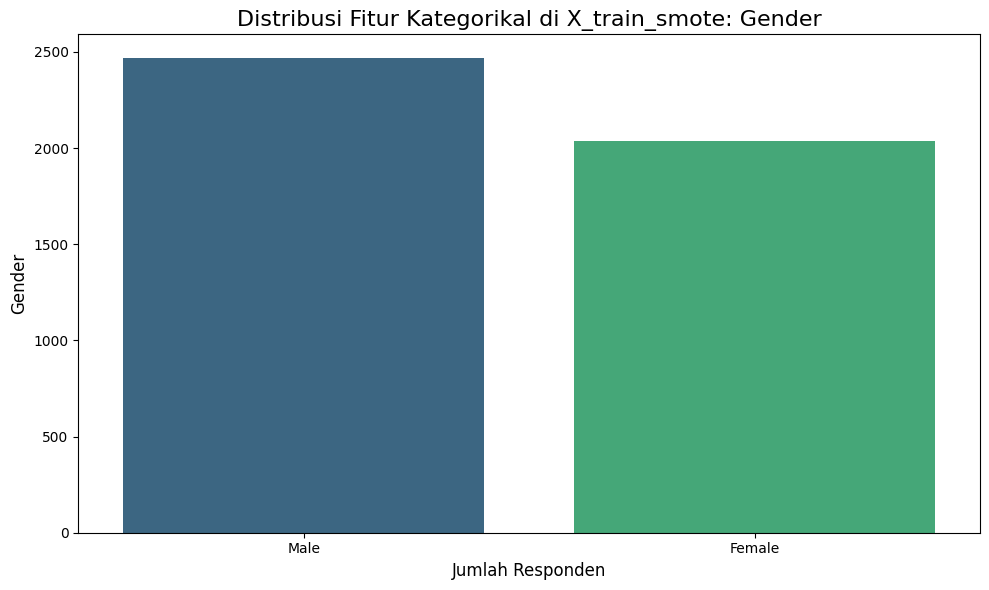

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


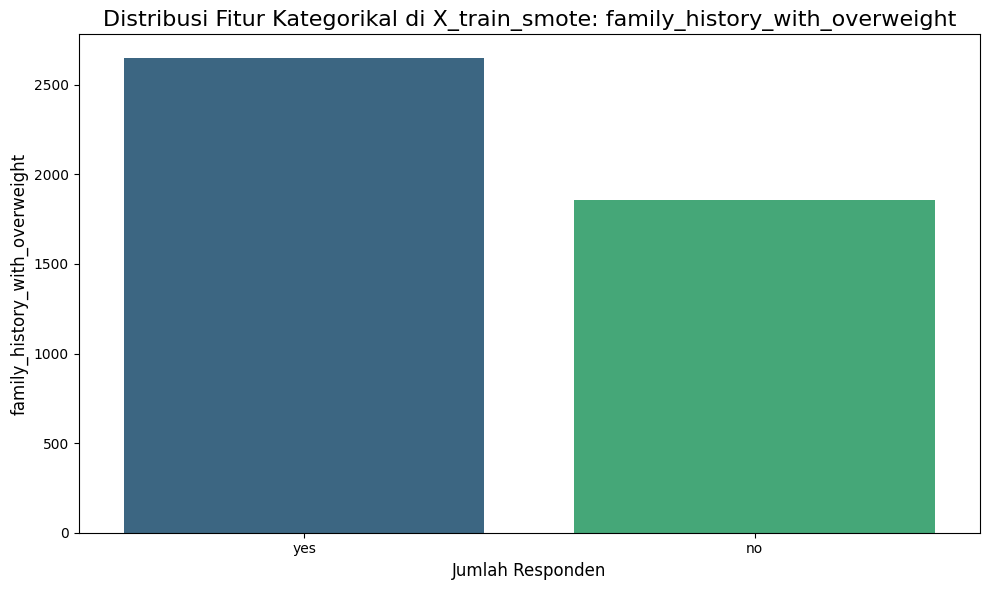

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


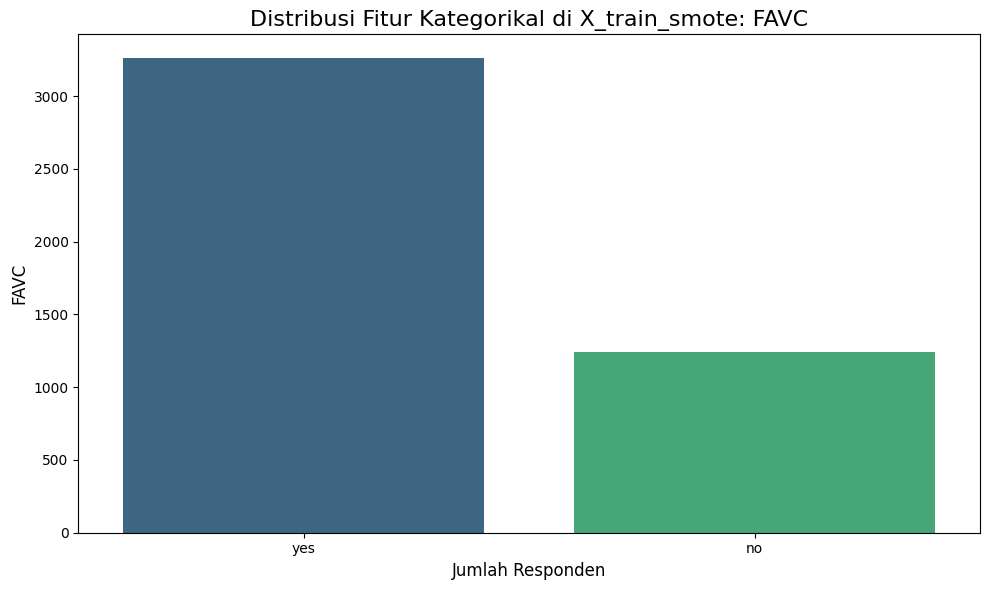

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


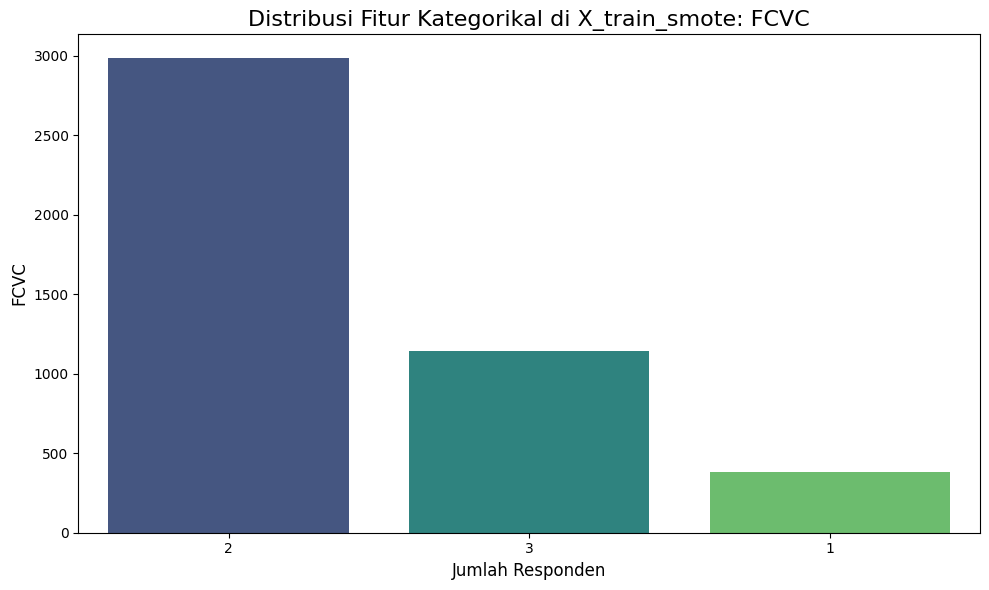

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


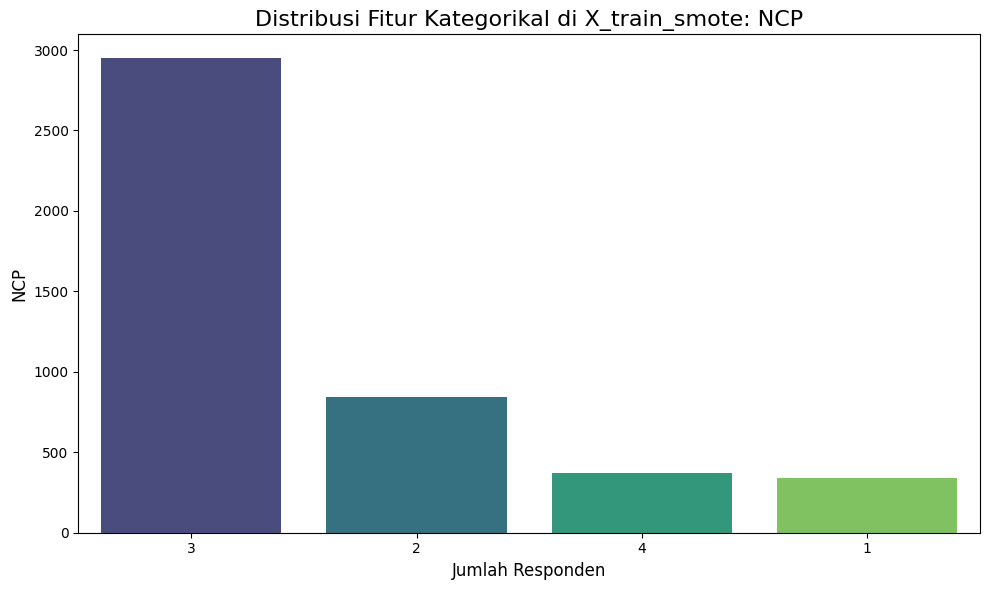

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


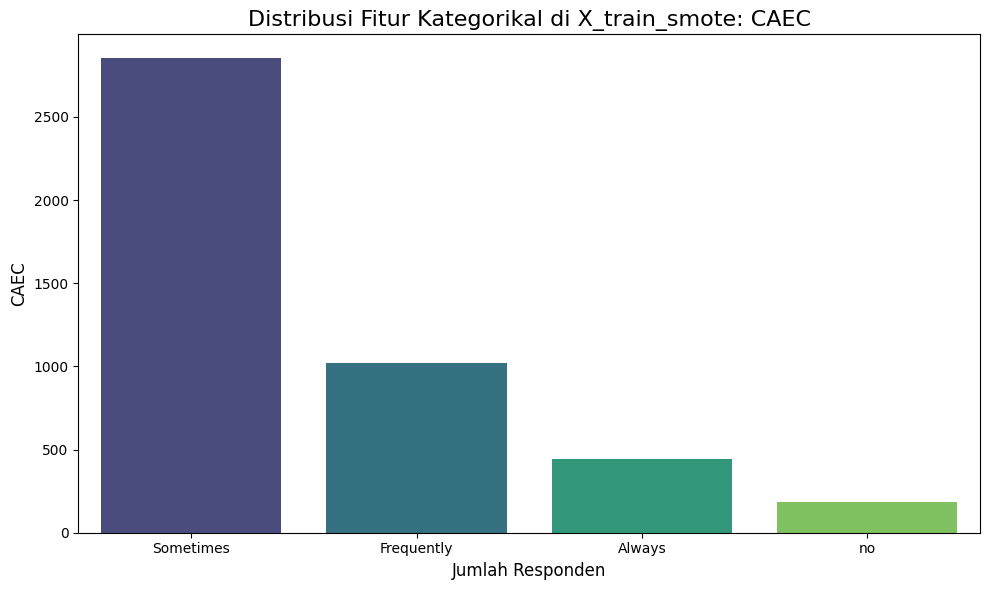

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


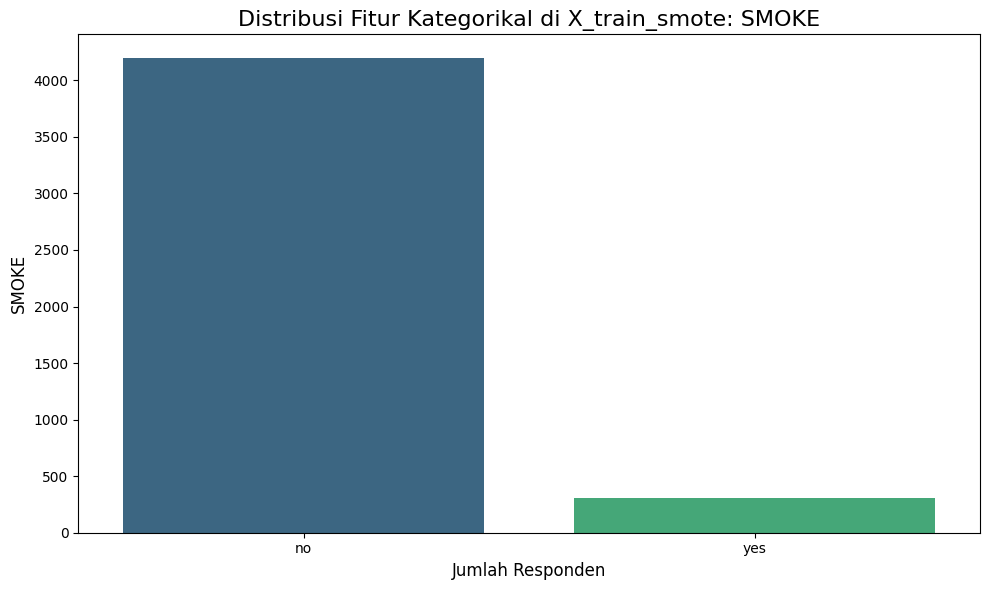

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


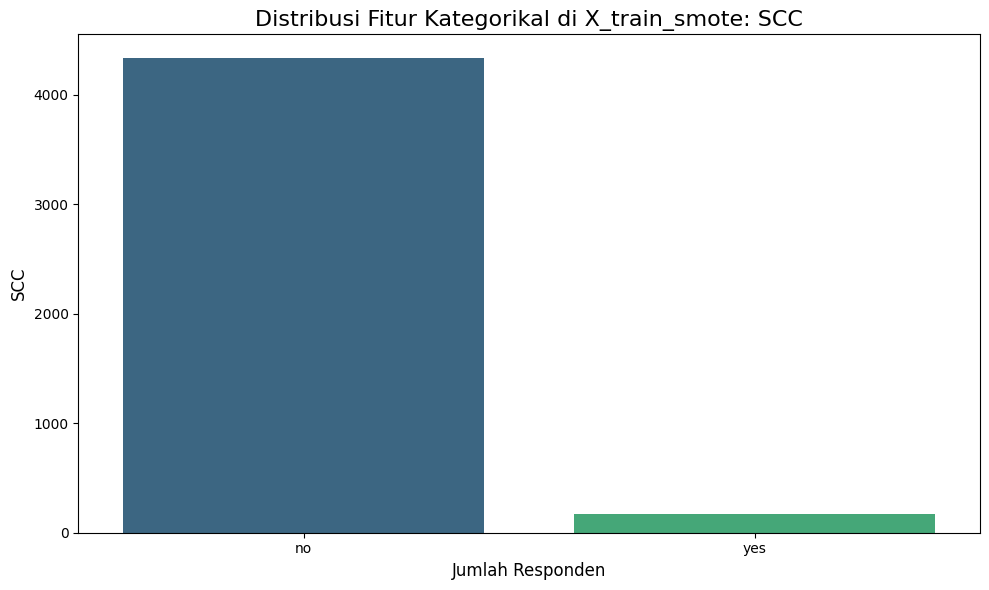

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


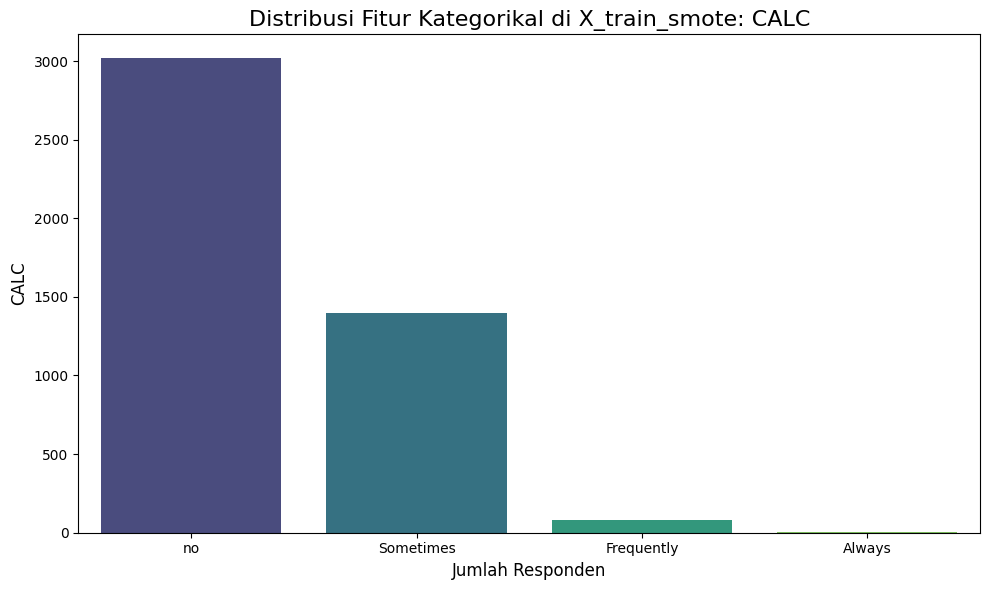

/tmp/ipython-input-193280977.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


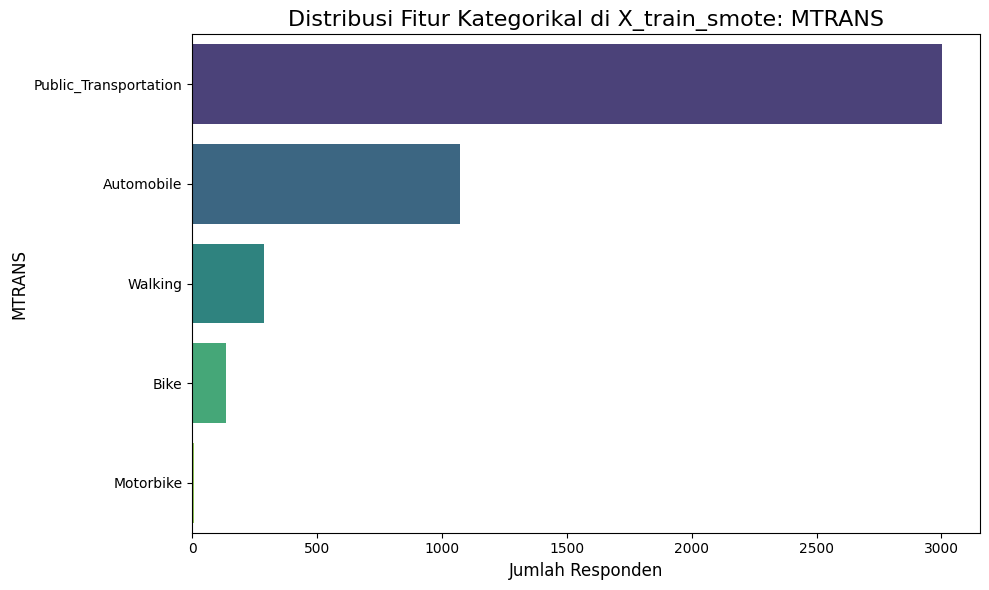

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


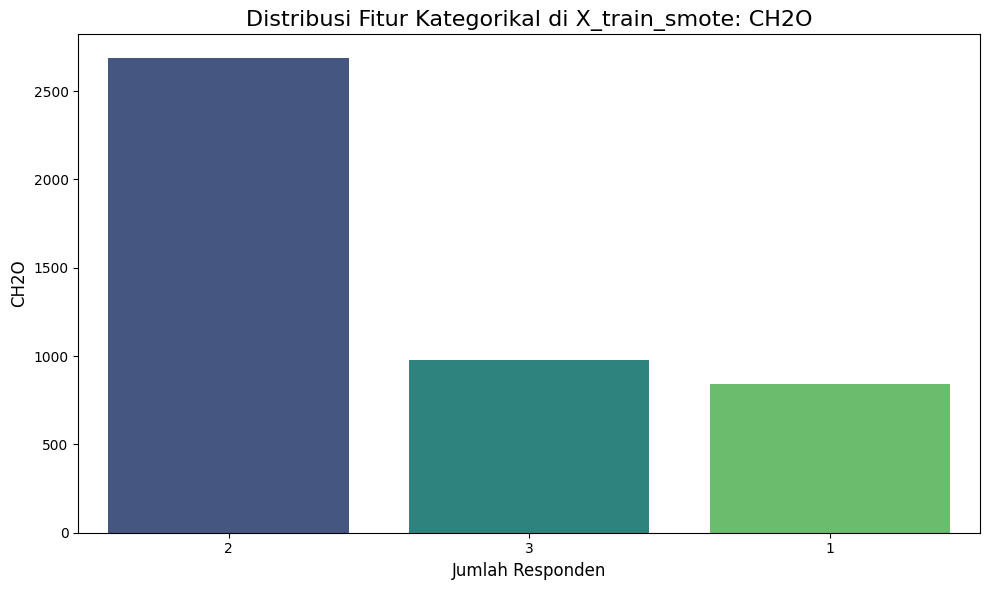

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


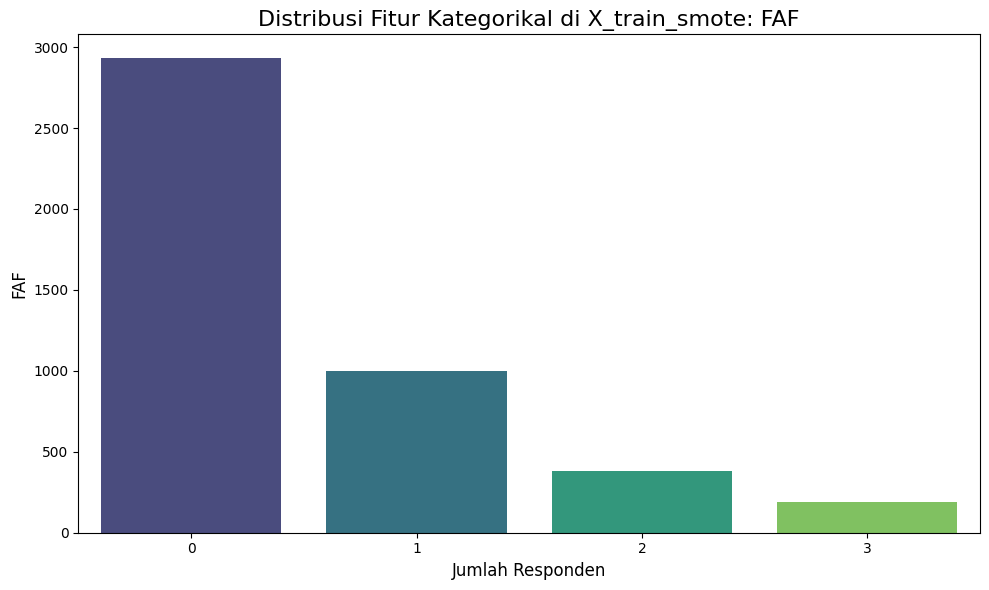

/tmp/ipython-input-193280977.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)


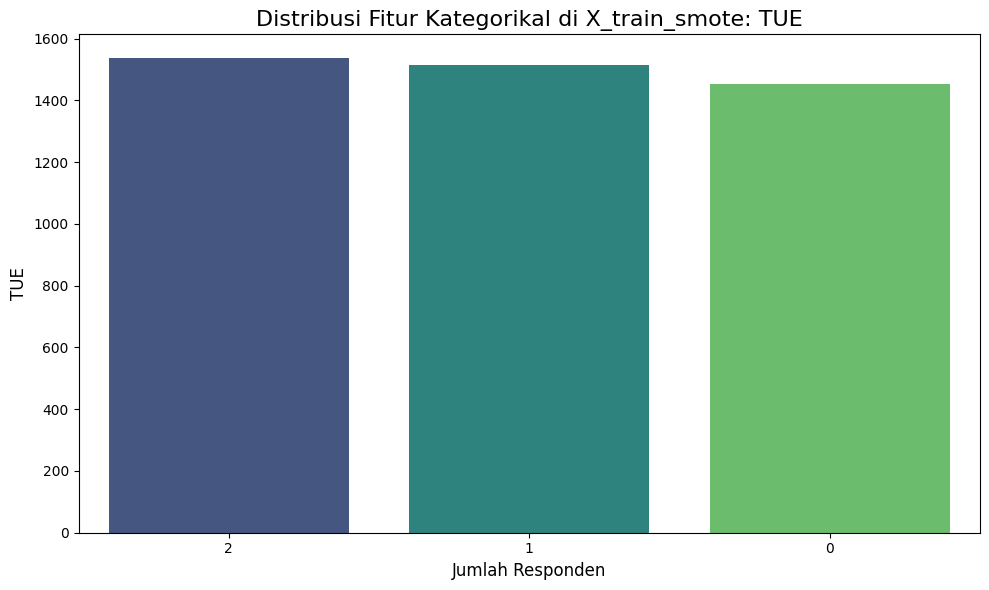

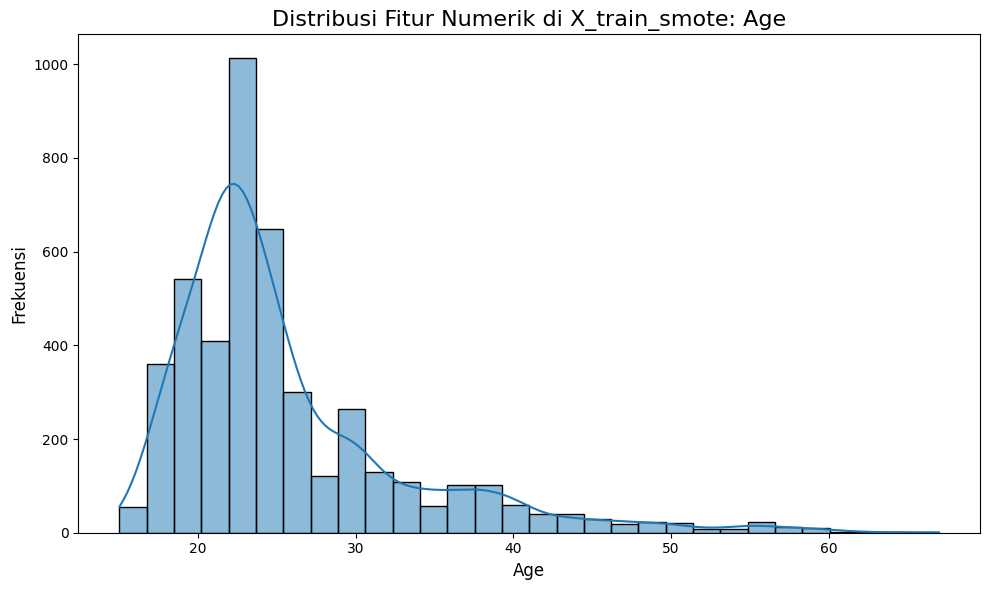

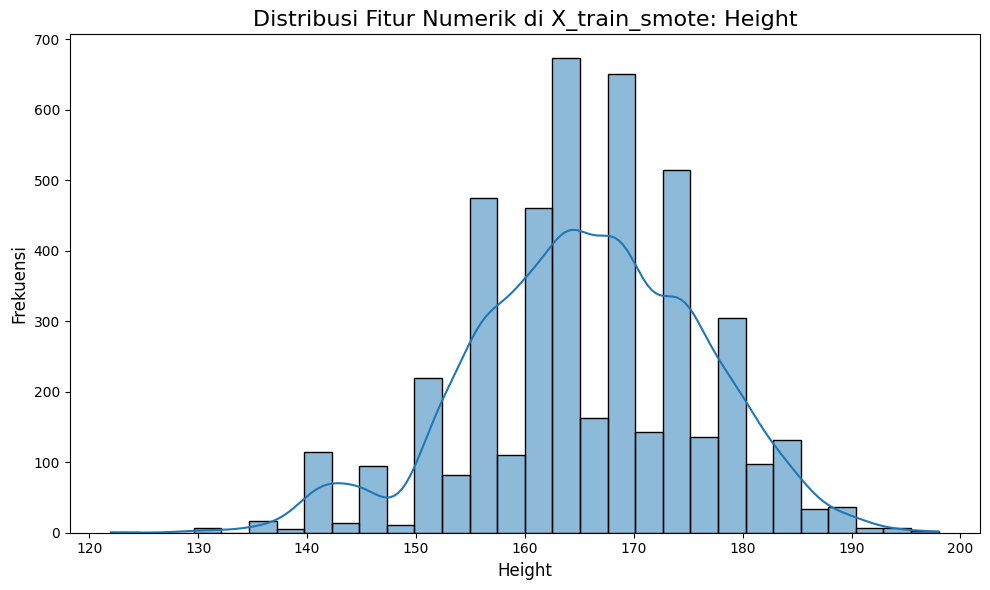

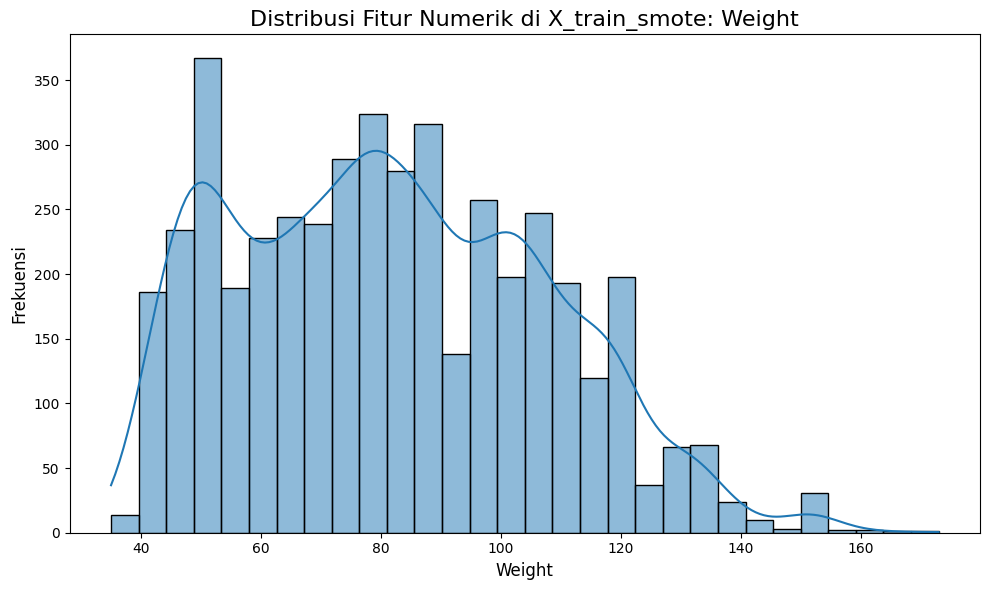

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nMemulai proses penampilan plot untuk X_train_smote...")
print("Tutup jendela plot yang muncul untuk melanjutkan ke plot berikutnya.")


numerical_features_smote = X_train_smote.select_dtypes(include=['number']).columns.tolist()
if 'NObeyesdad' in numerical_features_smote:
    numerical_features_smote.remove('NObeyesdad')

for feature in categorical_features:
    if feature in X_train_smote.columns:
        plt.figure(figsize=(10, 6))
        if X_train_smote[feature].nunique() > 4:
            sns.countplot(y=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)
        else:
            sns.countplot(x=feature, data=X_train_smote, palette='viridis', order=X_train_smote[feature].value_counts().index)
        plt.title(f'Distribusi Fitur Kategorikal di X_train_smote: {feature}', fontsize=16)
        plt.xlabel('Jumlah Responden', fontsize=12)
        plt.ylabel(feature, fontsize=12)
        plt.tight_layout()
        plt.show()

for feature in numerical_features_smote:
    plt.figure(figsize=(10, 6))
    sns.histplot(X_train_smote[feature], kde=True, bins=30)
    plt.title(f'Distribusi Fitur Numerik di X_train_smote: {feature}', fontsize=16)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frekuensi', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
print(f"X_train: {X_train_smote.shape}")
print(f"X_val: {X_val.shape}")
print(f"X_test: {X_test.shape}")

X_train: (4506, 16)
X_val: (396, 16)
X_test: (397, 16)


## PART 7 INITIATE CATBOOST MODEL

In [ ]:
CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    random_state=42,
    iterations=1500,
    task_type='GPU'
)

##PART 8 TRAINING AND VALIDATION MODEL

### TUNING PARAMETER LEARNING RATE

*   Learning Rate 0.03 = 0.9217
*   Learning Rate 0.04 = 0.9268
*   Learning Rate 0.05 = 0.9318





##### LEARNING RATE 0.03



0:	learn: 0.5670217	test: 0.5176768	best: 0.5176768 (0)	total: 171ms	remaining: 4m 15s
200:	learn: 0.9161119	test: 0.8914141	best: 0.8914141 (196)	total: 11.4s	remaining: 1m 13s
400:	learn: 0.9529516	test: 0.9242424	best: 0.9242424 (363)	total: 23.1s	remaining: 1m 3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9292929293
bestIteration = 407

Shrink model to first 408 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 27.32 detik
Iterasi Terbaik: 407
Training Accuracy: 0.9598
Validation Accuracy: 0.9293
Contoh 5 nilai training loss pertama: [1.741000141736965, 1.6933283365909302, 1.6503882086247503, 1.6066722743683748, 1.5652369774253918]
Contoh 5 nilai validation loss pertama: [1.744368207456091, 1.699045442811385, 1.6609054948645527, 1.6195549162669722, 1.5793785448512776]


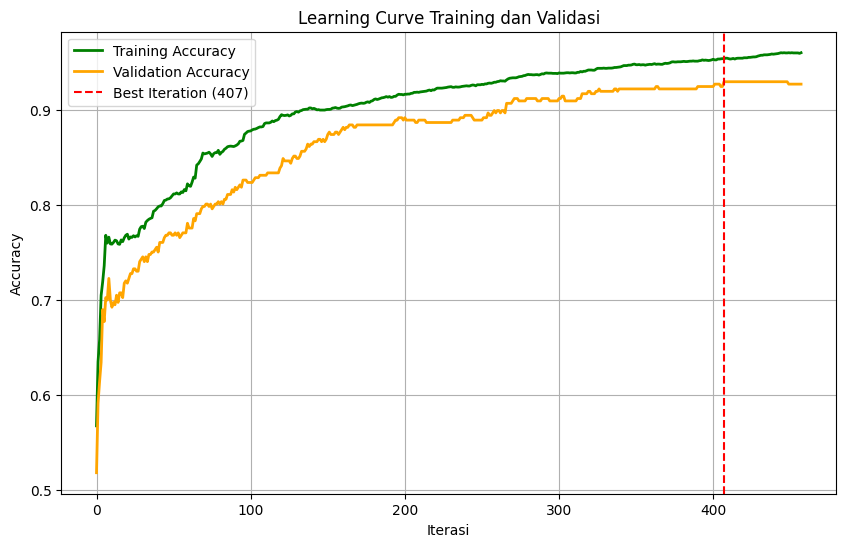

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.03,
    random_state=42,
    iterations=1500,
    depth=4,
    l2_leaf_reg=3
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
    early_stopping_rounds=50,
    use_best_model=True,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']

print("Contoh 5 nilai training loss pertama:", training_loss[:5])
print("Contoh 5 nilai validation loss pertama:", validation_loss[:5])


plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")


Training MultiClass Loss at best iteration (407): 0.2585
Validation MultiClass Loss at best iteration (407): 0.3192


In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 92.93%


Confusion Matrix:
[[57  2  0  0  0  0]
 [ 8 68  0  0  0  5]
 [ 0  0 58  5  0  1]
 [ 0  0  1 51  1  0]
 [ 0  0  0  0 45  0]
 [ 0  0  5  0  0 89]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.97      0.92        59
      Normal_Weight       0.97      0.84      0.90        81
     Obesity_Type_I       0.91      0.91      0.91        64
    Obesity_Type_II       0.91      0.96      0.94        53
   Obesity_Type_III       0.98      1.00      0.99        45
         Overweight       0.94      0.95      0.94        94

           accuracy                           0.93       396
          macro avg       0.93      0.94      0.93       396
       weighted avg       0.93      0.93      0.93       396



#### LEARNING RATE 0.04

0:	learn: 0.5670217	test: 0.5176768	best: 0.5176768 (0)	total: 68.4ms	remaining: 1m 42s
200:	learn: 0.9285397	test: 0.8989899	best: 0.9015152 (195)	total: 11.9s	remaining: 1m 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9267676768
bestIteration = 287

Shrink model to first 288 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 19.48 detik
Iterasi Terbaik: 287
Training Accuracy: 0.9592
Validation Accuracy: 0.9268
Contoh 5 nilai training loss pertama: [1.7244226519382284, 1.6627262329683836, 1.6086091488213208, 1.5539353074257676, 1.503522378667327]
Contoh 5 nilai validation loss pertama: [1.7289077374896105, 1.6702323989255001, 1.622157029211623, 1.570274641507406, 1.5212040378473173]


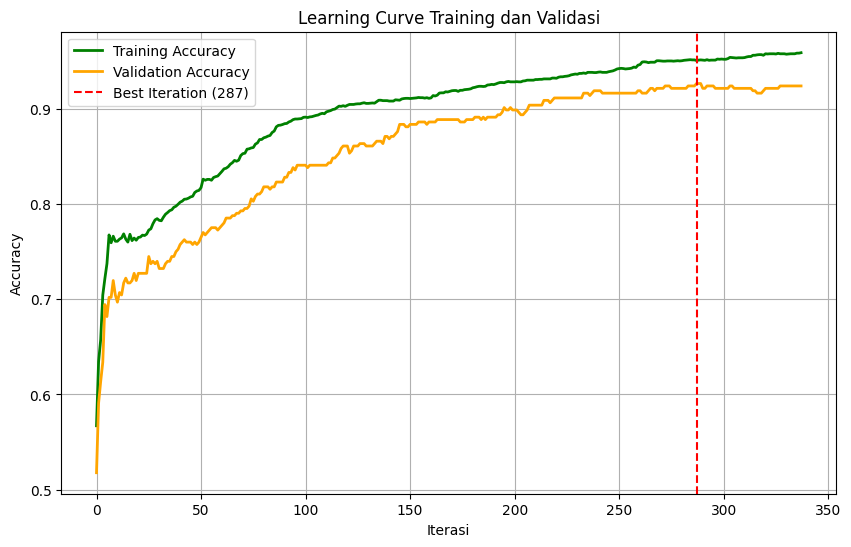

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.04,
    random_state=42,
    iterations=1500,
    depth=4,
    l2_leaf_reg=3,
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
    early_stopping_rounds=50,
    use_best_model=True,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']

print("Contoh 5 nilai training loss pertama:", training_loss[:5])
print("Contoh 5 nilai validation loss pertama:", validation_loss[:5])


plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")


Training MultiClass Loss at best iteration (287): 0.2672
Validation MultiClass Loss at best iteration (287): 0.3266


In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 92.68%


Confusion Matrix:
[[57  2  0  0  0  0]
 [ 7 69  0  0  0  5]
 [ 0  0 58  5  0  1]
 [ 0  0  2 50  1  0]
 [ 0  0  0  0 45  0]
 [ 0  0  6  0  0 88]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.97      0.93        59
      Normal_Weight       0.97      0.85      0.91        81
     Obesity_Type_I       0.88      0.91      0.89        64
    Obesity_Type_II       0.91      0.94      0.93        53
   Obesity_Type_III       0.98      1.00      0.99        45
         Overweight       0.94      0.94      0.94        94

           accuracy                           0.93       396
          macro avg       0.93      0.93      0.93       396
       weighted avg       0.93      0.93      0.93       396



#### LEARNING RATE 0.05

0:	learn: 0.5670217	test: 0.5176768	best: 0.5176768 (0)	total: 55.5ms	remaining: 1m 23s
200:	learn: 0.9440746	test: 0.9191919	best: 0.9191919 (199)	total: 11.8s	remaining: 1m 16s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9242424242
bestIteration = 222

Shrink model to first 223 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 16.87 detik
Iterasi Terbaik: 222
Training Accuracy: 0.9592
Validation Accuracy: 0.9242
Contoh 5 nilai training loss pertama: [1.7080206202375574, 1.63113619867792, 1.5674538043352335, 1.5027884771486324, 1.4474946877753385]
Contoh 5 nilai validation loss pertama: [1.7136196134877433, 1.641410095371642, 1.5847855211799098, 1.5233570744953502, 1.4691620913098726]


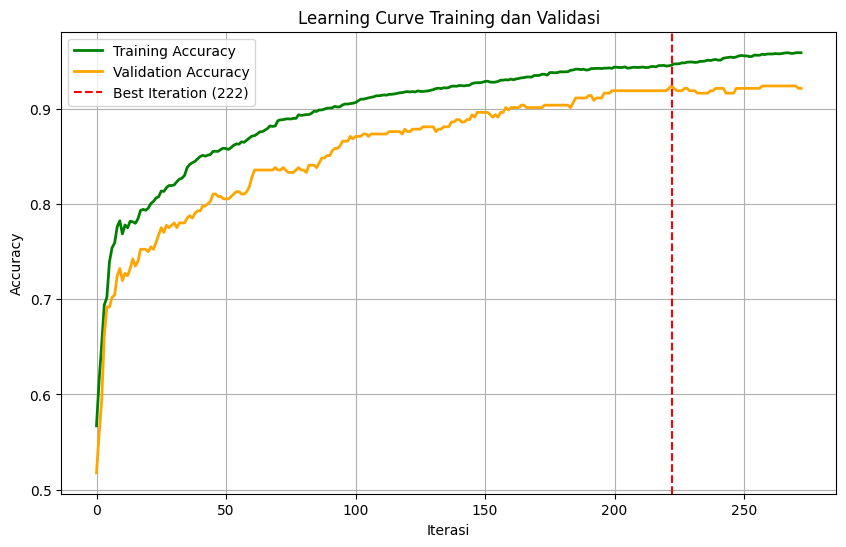

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.05,
    random_state=42,
    iterations=1500,
    depth=4,
    l2_leaf_reg=3
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
    early_stopping_rounds=50,
    use_best_model=True,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']

print("Contoh 5 nilai training loss pertama:", training_loss[:5])
print("Contoh 5 nilai validation loss pertama:", validation_loss[:5])


plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")


Training MultiClass Loss at best iteration (222): 0.2861
Validation MultiClass Loss at best iteration (222): 0.3449


In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 92.42%


Confusion Matrix:
[[57  2  0  0  0  0]
 [ 8 68  0  0  0  5]
 [ 0  0 58  5  0  1]
 [ 0  0  2 50  1  0]
 [ 0  0  0  0 45  0]
 [ 0  0  6  0  0 88]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.97      0.92        59
      Normal_Weight       0.97      0.84      0.90        81
     Obesity_Type_I       0.88      0.91      0.89        64
    Obesity_Type_II       0.91      0.94      0.93        53
   Obesity_Type_III       0.98      1.00      0.99        45
         Overweight       0.94      0.94      0.94        94

           accuracy                           0.92       396
          macro avg       0.93      0.93      0.93       396
       weighted avg       0.93      0.92      0.92       396



### TUNING PARAMETER DEPTH

*   Depth 4, Learning Rate 0.05 = 0.9318
*   Depth 6, Learning Rate 0.05 = 0.9419
*   Depth 8, Learning Rate 0.05 = 0.9217



##### DEPTH 4

0:	learn: 0.5670217	test: 0.5176768	best: 0.5176768 (0)	total: 60.5ms	remaining: 1m 30s
200:	learn: 0.9440746	test: 0.9191919	best: 0.9191919 (199)	total: 12.3s	remaining: 1m 19s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9242424242
bestIteration = 222

Shrink model to first 223 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 16.27 detik
Iterasi Terbaik: 222
Training Accuracy: 0.9592
Validation Accuracy: 0.9242
Contoh 5 nilai training loss pertama: [1.7080206202375574, 1.63113619867792, 1.5674538043352335, 1.5027884771486324, 1.4474946877753385]
Contoh 5 nilai validation loss pertama: [1.7136196134877433, 1.641410095371642, 1.5847855211799098, 1.5233570744953502, 1.4691620913098726]


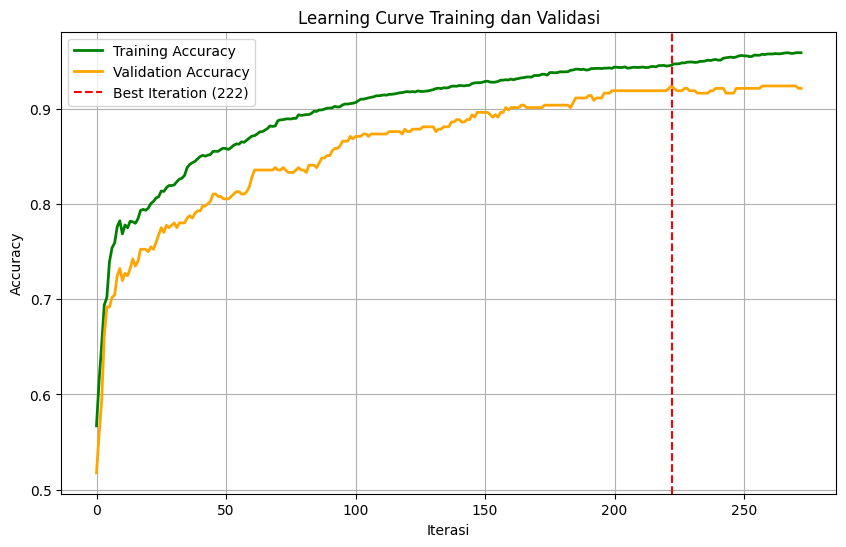

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.05,
    random_state=42,
    iterations=1500,
    depth=4,
    l2_leaf_reg=3,
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
    early_stopping_rounds=50,
    use_best_model=True,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']

print("Contoh 5 nilai training loss pertama:", training_loss[:5])
print("Contoh 5 nilai validation loss pertama:", validation_loss[:5])


plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")


Training MultiClass Loss at best iteration (222): 0.2861
Validation MultiClass Loss at best iteration (222): 0.3449


In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 92.42%


Confusion Matrix:
[[57  2  0  0  0  0]
 [ 8 68  0  0  0  5]
 [ 0  0 58  5  0  1]
 [ 0  0  2 50  1  0]
 [ 0  0  0  0 45  0]
 [ 0  0  6  0  0 88]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.88      0.97      0.92        59
      Normal_Weight       0.97      0.84      0.90        81
     Obesity_Type_I       0.88      0.91      0.89        64
    Obesity_Type_II       0.91      0.94      0.93        53
   Obesity_Type_III       0.98      1.00      0.99        45
         Overweight       0.94      0.94      0.94        94

           accuracy                           0.92       396
          macro avg       0.93      0.93      0.93       396
       weighted avg       0.93      0.92      0.92       396



#### DEPTH 6

0:	learn: 0.6182867	test: 0.5580808	best: 0.5580808 (0)	total: 112ms	remaining: 2m 48s
200:	learn: 0.9713715	test: 0.9419192	best: 0.9419192 (195)	total: 24.2s	remaining: 2m 36s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.946969697
bestIteration = 203

Shrink model to first 204 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 30.31 detik
Iterasi Terbaik: 203
Training Accuracy: 0.9796
Validation Accuracy: 0.9470
Contoh 5 nilai training loss pertama: [1.7047069478265517, 1.6132057606431913, 1.53590597365994, 1.462849945406524, 1.392250276971083]
Contoh 5 nilai validation loss pertama: [1.7142969420531664, 1.627099241212376, 1.5569677199349645, 1.4864821609396652, 1.4196427935245775]


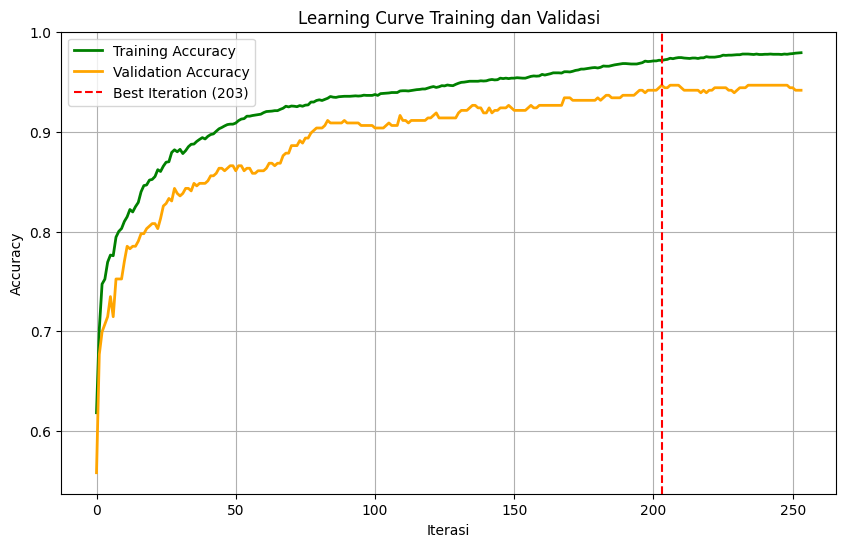

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.05,
    random_state=42,
    iterations=1500,
    depth=6,
    l2_leaf_reg=3,
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
    early_stopping_rounds=50,
    use_best_model=True,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']

print("Contoh 5 nilai training loss pertama:", training_loss[:5])
print("Contoh 5 nilai validation loss pertama:", validation_loss[:5])


plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")


Training MultiClass Loss at best iteration (203): 0.2027
Validation MultiClass Loss at best iteration (203): 0.2769


In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 94.70%


Confusion Matrix:
[[58  1  0  0  0  0]
 [ 5 74  0  0  0  2]
 [ 0  0 56  5  0  3]
 [ 0  0  1 52  0  0]
 [ 0  0  0  0 45  0]
 [ 0  1  3  0  0 90]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.98      0.95        59
      Normal_Weight       0.97      0.91      0.94        81
     Obesity_Type_I       0.93      0.88      0.90        64
    Obesity_Type_II       0.91      0.98      0.95        53
   Obesity_Type_III       1.00      1.00      1.00        45
         Overweight       0.95      0.96      0.95        94

           accuracy                           0.95       396
          macro avg       0.95      0.95      0.95       396
       weighted avg       0.95      0.95      0.95       396



#### DEPTH 8

0:	learn: 0.6897470	test: 0.6237374	best: 0.6237374 (0)	total: 305ms	remaining: 7m 37s
200:	learn: 0.9795828	test: 0.9393939	best: 0.9393939 (189)	total: 48.5s	remaining: 5m 13s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9444444444
bestIteration = 203

Shrink model to first 204 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 60.19 detik
Iterasi Terbaik: 203
Training Accuracy: 0.9862
Validation Accuracy: 0.9444
Contoh 5 nilai training loss pertama: [1.6982253103152565, 1.6030842301808195, 1.5108353032744346, 1.4364992614953465, 1.3796446914586311]
Contoh 5 nilai validation loss pertama: [1.7110287010855165, 1.6201128341889726, 1.532763795080674, 1.4658791477727746, 1.4161357543201378]


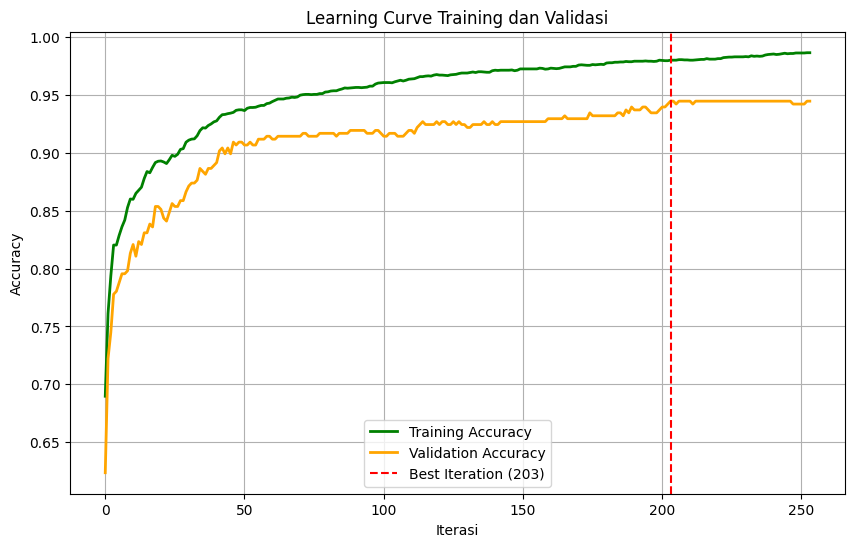

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.05,
    random_state=42,
    iterations=1500,
    depth=8,
    l2_leaf_reg=3,
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
    early_stopping_rounds=50,
    use_best_model=True,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']

print("Contoh 5 nilai training loss pertama:", training_loss[:5])
print("Contoh 5 nilai validation loss pertama:", validation_loss[:5])


plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")


Training MultiClass Loss at best iteration (203): 0.1543
Validation MultiClass Loss at best iteration (203): 0.2471


In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 94.44%


Confusion Matrix:
[[58  1  0  0  0  0]
 [ 6 71  0  0  0  4]
 [ 0  0 59  4  0  1]
 [ 0  0  1 52  0  0]
 [ 0  0  0  1 44  0]
 [ 0  2  2  0  0 90]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      0.98      0.94        59
      Normal_Weight       0.96      0.88      0.92        81
     Obesity_Type_I       0.95      0.92      0.94        64
    Obesity_Type_II       0.91      0.98      0.95        53
   Obesity_Type_III       1.00      0.98      0.99        45
         Overweight       0.95      0.96      0.95        94

           accuracy                           0.94       396
          macro avg       0.95      0.95      0.95       396
       weighted avg       0.95      0.94      0.94       396



### TUNING PARAMETER LEAF REG

*   Leaf_Req 3, Depth 6, Learning Rate 0.05 = 0.9419
*   Leaf_Req 4, Depth 6, Learning Rate 0.05 = 0.9444
*   Leaf_Req 5, Depth 6, Learning Rate 0.05 = 0.9495



##### LEAF REQ 3

0:	learn: 0.6182867	test: 0.5580808	best: 0.5580808 (0)	total: 112ms	remaining: 56.1s
200:	learn: 0.9713715	test: 0.9419192	best: 0.9419192 (195)	total: 24.1s	remaining: 35.8s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.946969697
bestIteration = 203

Shrink model to first 204 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 30.75 detik
Iterasi Terbaik: 203
Training Accuracy: 0.9796
Validation Accuracy: 0.9470
Contoh 5 nilai training loss pertama: [1.7047069478265517, 1.6132057606431913, 1.53590597365994, 1.462849945406524, 1.392250276971083]
Contoh 5 nilai validation loss pertama: [1.7142969420531664, 1.627099241212376, 1.5569677199349645, 1.4864821609396652, 1.4196427935245775]


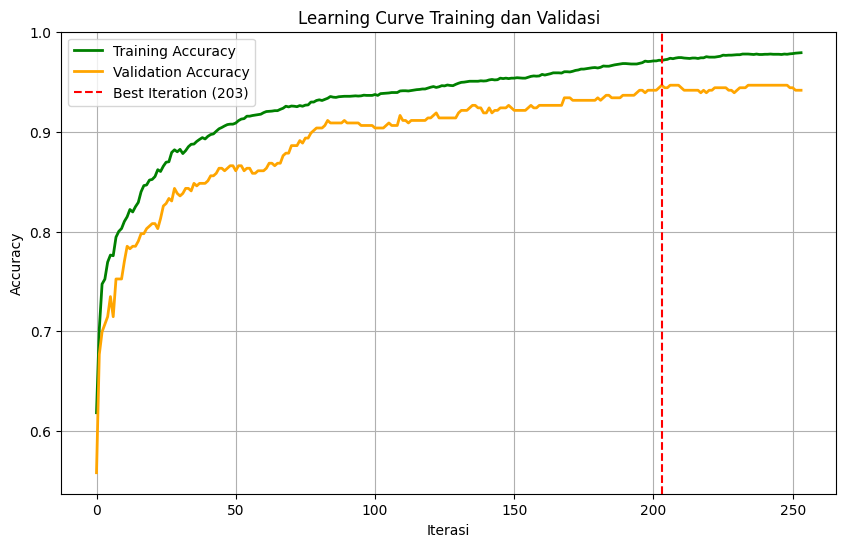

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.05,
    random_state=42,
    iterations=500,
    depth=6,
    l2_leaf_reg=3
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
    early_stopping_rounds=50,
    use_best_model=True,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']

print("Contoh 5 nilai training loss pertama:", training_loss[:5])
print("Contoh 5 nilai validation loss pertama:", validation_loss[:5])


plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")


Training MultiClass Loss at best iteration (203): 0.2027
Validation MultiClass Loss at best iteration (203): 0.2769


In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 94.70%


Confusion Matrix:
[[58  1  0  0  0  0]
 [ 5 74  0  0  0  2]
 [ 0  0 56  5  0  3]
 [ 0  0  1 52  0  0]
 [ 0  0  0  0 45  0]
 [ 0  1  3  0  0 90]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      0.98      0.95        59
      Normal_Weight       0.97      0.91      0.94        81
     Obesity_Type_I       0.93      0.88      0.90        64
    Obesity_Type_II       0.91      0.98      0.95        53
   Obesity_Type_III       1.00      1.00      1.00        45
         Overweight       0.95      0.96      0.95        94

           accuracy                           0.95       396
          macro avg       0.95      0.95      0.95       396
       weighted avg       0.95      0.95      0.95       396



#### LEAF REQ 4

0:	learn: 0.6182867	test: 0.5580808	best: 0.5580808 (0)	total: 97.7ms	remaining: 1m 37s
200:	learn: 0.9656014	test: 0.9393939	best: 0.9393939 (200)	total: 23.6s	remaining: 1m 33s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9419191919
bestIteration = 209

Shrink model to first 210 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 29.90 detik
Iterasi Terbaik: 209
Training Accuracy: 0.9758
Validation Accuracy: 0.9419
Contoh 5 nilai training loss pertama: [1.707240358718001, 1.6176920646037032, 1.5423993945818393, 1.4700111573116765, 1.400500659302063]
Contoh 5 nilai validation loss pertama: [1.716766598738948, 1.631448239519731, 1.563169929483395, 1.4933850814729166, 1.4275339104435023]


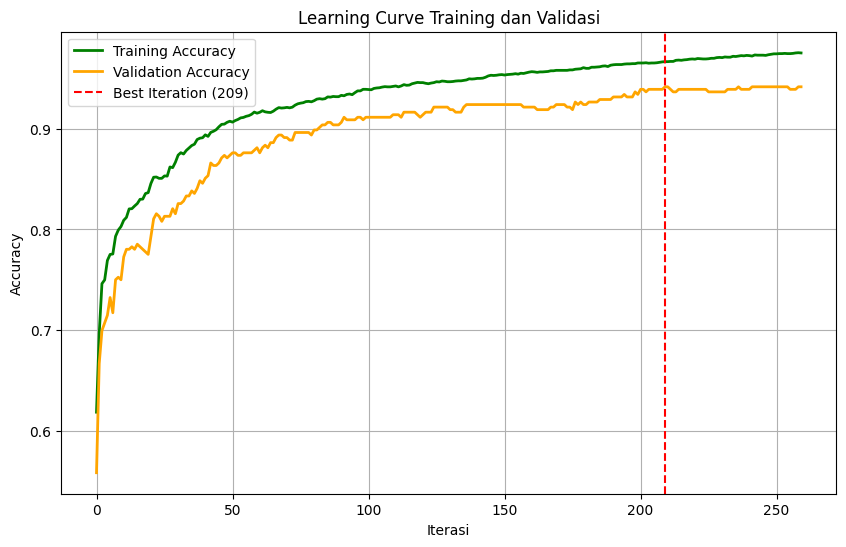

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.05,
    random_state=42,
    iterations=1000,
    depth=6,
    l2_leaf_reg=4
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
    early_stopping_rounds=50,
    use_best_model=True,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']

print("Contoh 5 nilai training loss pertama:", training_loss[:5])
print("Contoh 5 nilai validation loss pertama:", validation_loss[:5])


plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")


Training MultiClass Loss at best iteration (209): 0.2063
Validation MultiClass Loss at best iteration (209): 0.2754


In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 94.19%


Confusion Matrix:
[[58  1  0  0  0  0]
 [ 7 70  0  0  0  4]
 [ 0  0 58  5  0  1]
 [ 0  0  1 52  0  0]
 [ 0  0  0  0 45  0]
 [ 0  1  3  0  0 90]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.98      0.94        59
      Normal_Weight       0.97      0.86      0.92        81
     Obesity_Type_I       0.94      0.91      0.92        64
    Obesity_Type_II       0.91      0.98      0.95        53
   Obesity_Type_III       1.00      1.00      1.00        45
         Overweight       0.95      0.96      0.95        94

           accuracy                           0.94       396
          macro avg       0.94      0.95      0.94       396
       weighted avg       0.94      0.94      0.94       396



#### LEAF REQ 5

0:	learn: 0.6182867	test: 0.5580808	best: 0.5580808 (0)	total: 94.8ms	remaining: 2m 22s
200:	learn: 0.9651576	test: 0.9343434	best: 0.9393939 (189)	total: 23.7s	remaining: 2m 33s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9393939394
bestIteration = 189

Shrink model to first 190 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 28.93 detik
Iterasi Terbaik: 189
Training Accuracy: 0.9725
Validation Accuracy: 0.9394
Contoh 5 nilai training loss pertama: [1.7094901949898258, 1.6217486770880019, 1.5483232590961211, 1.476612596440043, 1.408136521246468]
Contoh 5 nilai validation loss pertama: [1.7189214135513922, 1.6353366549960007, 1.5687688653259535, 1.4996891240682435, 1.434774852709293]


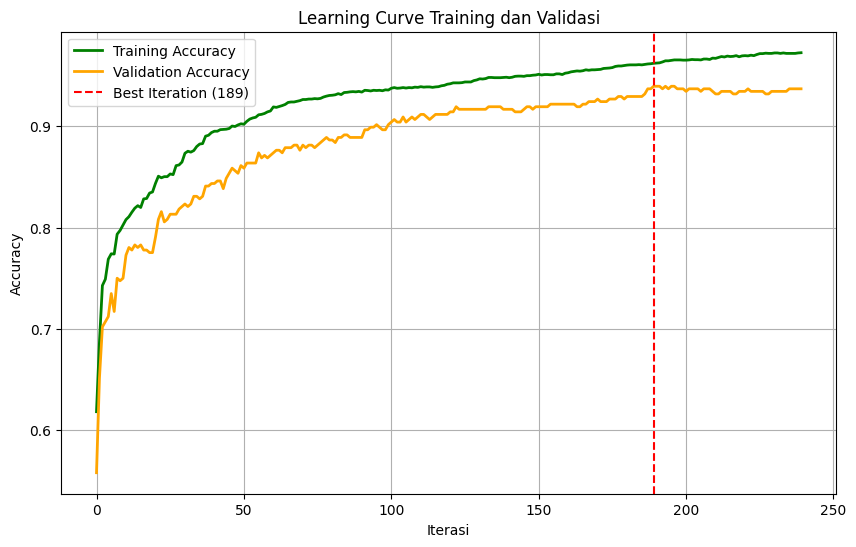

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.05,
    random_state=42,
    iterations=1500,
    depth=6,
    l2_leaf_reg=5
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
    early_stopping_rounds=50,
    use_best_model=True,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']

print("Contoh 5 nilai training loss pertama:", training_loss[:5])
print("Contoh 5 nilai validation loss pertama:", validation_loss[:5])


plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")


Training MultiClass Loss at best iteration (189): 0.2318
Validation MultiClass Loss at best iteration (189): 0.3002


In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 93.94%


Confusion Matrix:
[[58  1  0  0  0  0]
 [ 7 71  0  0  0  3]
 [ 0  0 58  5  0  1]
 [ 0  0  1 51  1  0]
 [ 0  0  0  0 45  0]
 [ 0  1  4  0  0 89]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.98      0.94        59
      Normal_Weight       0.97      0.88      0.92        81
     Obesity_Type_I       0.92      0.91      0.91        64
    Obesity_Type_II       0.91      0.96      0.94        53
   Obesity_Type_III       0.98      1.00      0.99        45
         Overweight       0.96      0.95      0.95        94

           accuracy                           0.94       396
          macro avg       0.94      0.95      0.94       396
       weighted avg       0.94      0.94      0.94       396



### BEST HYPERPARAMETER

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.05,
    random_state=42,
    iterations=1000,
    depth=6,
    early_stopping_rounds=50,
    use_best_model=True,
    l2_leaf_reg=5
)

CatBoost_Model.fit(
    X_train_smote, y_train_smote,
    eval_set=(X_val, y_val),
    verbose=200,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']



0:	learn: 0.6182867	test: 0.5580808	best: 0.5580808 (0)	total: 101ms	remaining: 1m 40s
200:	learn: 0.9651576	test: 0.9343434	best: 0.9393939 (189)	total: 23.6s	remaining: 1m 33s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9393939394
bestIteration = 189

Shrink model to first 190 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 27.83 detik
Iterasi Terbaik: 189
Training Accuracy: 0.9725
Validation Accuracy: 0.9394


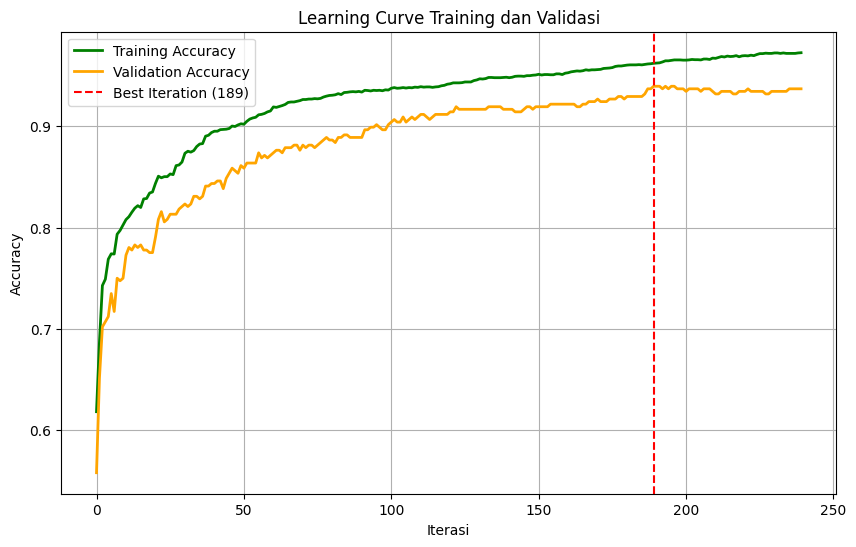

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()


Training MultiClass Loss at best iteration (189): 0.2318
Validation MultiClass Loss at best iteration (189): 0.3002


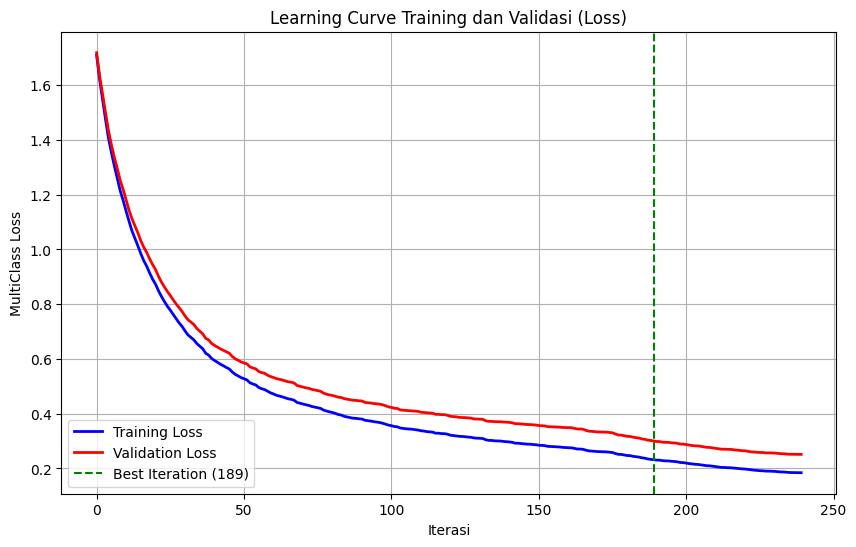

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn']['MultiClass'], label='Training Loss', color='blue', linewidth=2)
plt.plot(eval_history['validation']['MultiClass'], label='Validation Loss', color='red', linewidth=2)
plt.axvline(best_iter, color='green', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel('MultiClass Loss')
plt.title('Learning Curve Training dan Validasi (Loss)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred = CatBoost_Model.predict(X_val)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 93.94%


Confusion Matrix:
[[58  1  0  0  0  0]
 [ 7 71  0  0  0  3]
 [ 0  0 58  5  0  1]
 [ 0  0  1 51  1  0]
 [ 0  0  0  0 45  0]
 [ 0  1  4  0  0 89]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.89      0.98      0.94        59
      Normal_Weight       0.97      0.88      0.92        81
     Obesity_Type_I       0.92      0.91      0.91        64
    Obesity_Type_II       0.91      0.96      0.94        53
   Obesity_Type_III       0.98      1.00      0.99        45
         Overweight       0.96      0.95      0.95        94

           accuracy                           0.94       396
          macro avg       0.94      0.95      0.94       396
       weighted avg       0.94      0.94      0.94       396



/tmp/ipython-input-3160616189.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


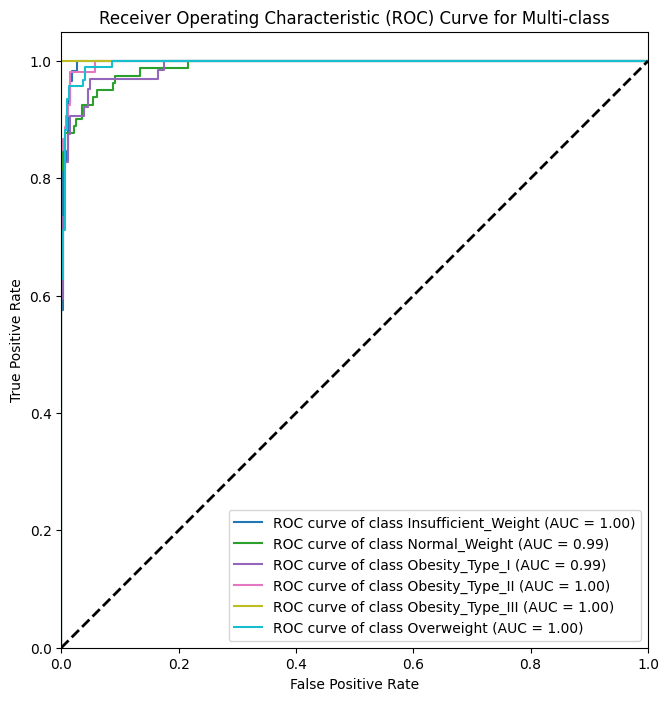


AUC for each class:
  Insufficient_Weight: 1.00
  Normal_Weight: 0.99
  Obesity_Type_I: 0.99
  Obesity_Type_II: 1.00
  Obesity_Type_III: 1.00
  Overweight: 1.00


In [ ]:
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.preprocessing import label_binarize
import numpy as np

all_classes = sorted(y_train_smote.unique())

y_val_binarized = label_binarize(y_val, classes=all_classes)
n_classes = y_val_binarized.shape[1]

y_prob = CatBoost_Model.predict_proba(X_val)

fpr = dict()
tpr = dict()
roc_auc = dict()

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    roc_display = RocCurveDisplay.from_predictions(y_val_binarized[:, i], y_prob[:, i], name=f'ROC curve of class {all_classes[i]}', ax=ax, color=colors(i))
    fpr[i] = roc_display.fpr
    tpr[i] = roc_display.tpr
    roc_auc[i] = roc_display.roc_auc


plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.show()

print("\nAUC for each class:")
for i in range(n_classes):
    print(f"  {all_classes[i]}: {roc_auc[i]:.2f}")

## PART 9 FEATURE IMPORTANCE

In [ ]:
from sklearn.model_selection import KFold
from catboost import Pool

all_feature_importances = []
kf = KFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
from catboost import Pool

all_feature_importances = []
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(kf.split(X_train_smote, y_train_smote)):
    print(f"\n--- Fold {fold+1}/{kf.get_n_splits()} ---")
    X_train_fold, X_val_fold = X_train_smote.iloc[train_index], X_train_smote.iloc[val_index]
    y_train_fold, y_val_fold = y_train_smote.iloc[train_index], y_train_smote.iloc[val_index]

    cb_model_fold = CatBoostClassifier(
        cat_features=categorical_features,
        loss_function='MultiClass',
        eval_metric='Accuracy',
        learning_rate=0.05,
        random_state=42,
        iterations=1000,
        depth=6,
        early_stopping_rounds=50,
        use_best_model=True,
        l2_leaf_reg=5,
        verbose=0
    )

    cb_model_fold.fit(
        X_train_fold, y_train_fold,
        eval_set=(X_val_fold, y_val_fold),
        verbose=0
    )

    fold_importance = cb_model_fold.get_feature_importance(
        Pool(X_train_fold, y_train_fold, cat_features=categorical_features))
    all_feature_importances.append(fold_importance)

print("Finished calculating feature importances for all folds.")


--- Fold 1/10 ---

--- Fold 2/10 ---

--- Fold 3/10 ---

--- Fold 4/10 ---

--- Fold 5/10 ---

--- Fold 6/10 ---

--- Fold 7/10 ---

--- Fold 8/10 ---

--- Fold 9/10 ---

--- Fold 10/10 ---
Finished calculating feature importances for all folds.


--- Aggregated Feature Importances (Mean across K-folds) ---


,Feature,Mean Importance
3,Weight,56.507644
2,Height,20.264764
1,Gender,5.377939
14,CAEC,4.226117
6,FCVC,3.040922
7,NCP,2.422738
13,TUE,1.910842
0,Age,1.483261
4,CALC,1.225661
15,MTRANS,0.900214


/tmp/ipython-input-1205912068.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Mean Importance', y='Feature', data=aggregated_feature_importance_df, palette='viridis', legend=False);


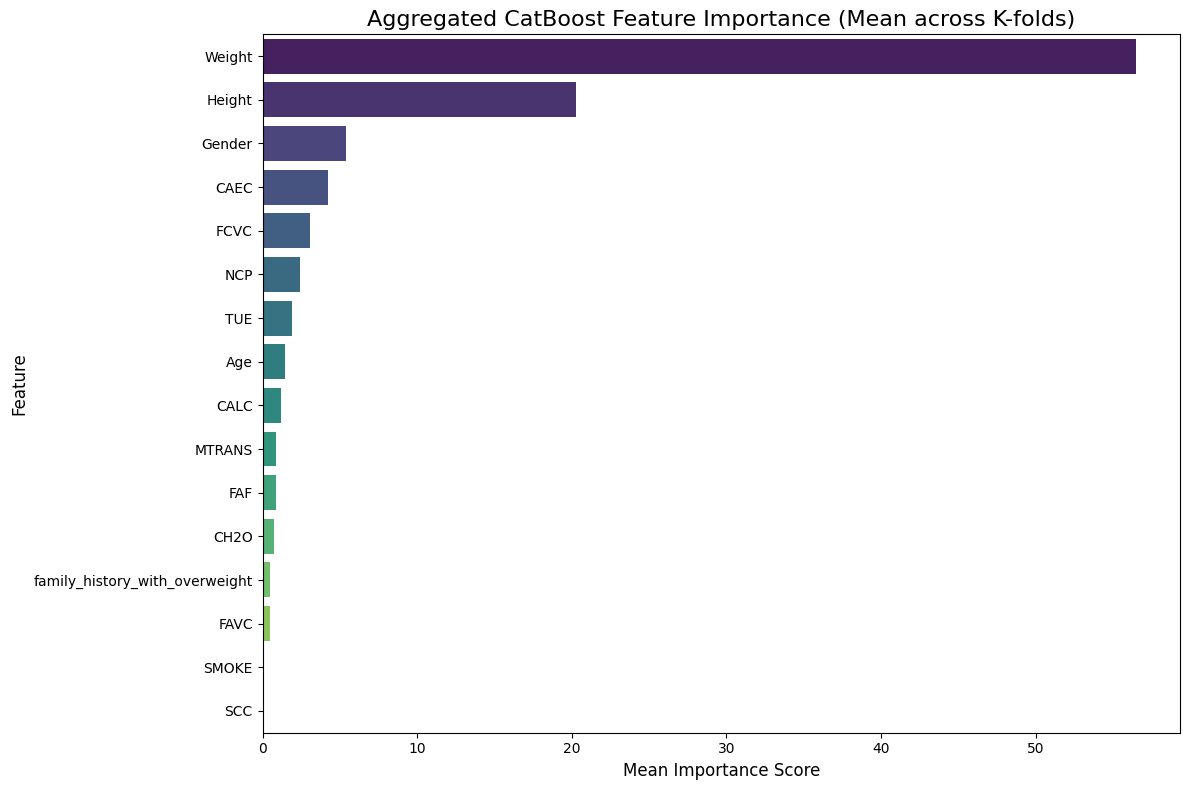

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

mean_feature_importances = np.mean(all_feature_importances, axis=0);

feature_names = X_train_smote.columns;
aggregated_feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean Importance': mean_feature_importances
});

aggregated_feature_importance_df = aggregated_feature_importance_df.sort_values(by='Mean Importance', ascending=False);

print("--- Aggregated Feature Importances (Mean across K-folds) ---");
display(aggregated_feature_importance_df);

plt.figure(figsize=(12, 8));
sns.barplot(x='Mean Importance', y='Feature', data=aggregated_feature_importance_df, palette='viridis', legend=False);
plt.title('Aggregated CatBoost Feature Importance (Mean across K-folds)', fontsize=16);
plt.xlabel('Mean Importance Score', fontsize=12);
plt.ylabel('Feature', fontsize=12);
plt.tight_layout();
plt.show();

## PART 10 TRIMMING FEATURE

In [ ]:
print("\n--- Trimming features 'SCC' and 'SMOKE' ---")

features_to_trim = ['SCC', 'SMOKE']

X_train_smote_trimmed = X_train_smote.drop(columns=features_to_trim)
X_val_trimmed = X_val.drop(columns=features_to_trim)
X_test_trimmed = X_test.drop(columns=features_to_trim)
X_transformed_trimmed = X_transformed.drop(columns=features_to_trim)

categorical_features_trimmed = [f for f in categorical_features if f not in features_to_trim]

print("Features trimmed: 'SCC' and 'SMOKE'")
print(f"New shape of X_train_smote_trimmed: {X_train_smote_trimmed.shape}")
print(f"New categorical features: {categorical_features_trimmed}")

print("\n--- Displaying head of trimmed training data ---")
display(X_train_smote_trimmed.head())


--- Trimming features 'SCC' and 'SMOKE' ---
Features trimmed: 'SCC' and 'SMOKE'
New shape of X_train_smote_trimmed: (4506, 14)
New categorical features: ['Gender', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'CALC', 'MTRANS', 'CH2O', 'FAF', 'TUE']

--- Displaying head of trimmed training data ---


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS
0,36,Female,152,99,no,yes,2,3,2,no,0,1,Frequently,Automobile
1,28,Male,181,87,no,yes,3,3,1,no,2,0,Sometimes,Automobile
2,46,Male,173,107,no,no,2,4,3,no,0,2,Always,Public_Transportation
3,23,Male,160,81,no,yes,3,3,3,no,0,2,Frequently,Public_Transportation
4,22,Female,157,80,no,yes,3,3,2,no,0,2,Always,Automobile


In [ ]:
print(X_train_smote_trimmed.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4506 entries, 0 to 4505
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Age                             4506 non-null   int64 
 1   Gender                          4506 non-null   object
 2   Height                          4506 non-null   int64 
 3   Weight                          4506 non-null   int64 
 4   CALC                            4506 non-null   object
 5   FAVC                            4506 non-null   object
 6   FCVC                            4506 non-null   object
 7   NCP                             4506 non-null   object
 8   CH2O                            4506 non-null   object
 9   family_history_with_overweight  4506 non-null   object
 10  FAF                             4506 non-null   object
 11  TUE                             4506 non-null   object
 12  CAEC                            4506 non-null   

## PART 11 TRAINING MODEL AFTER TRIMMING

In [ ]:
start_time = time.time()

CatBoost_Model = CatBoostClassifier(
    cat_features=categorical_features_trimmed,
    loss_function='MultiClass',
    eval_metric='Accuracy',
    learning_rate=0.05,
    random_state=42,
    iterations=1000,
    depth=6,
    early_stopping_rounds=50,
    use_best_model=True,
    l2_leaf_reg=5
)

CatBoost_Model.fit(
    X_train_smote_trimmed, y_train_smote,
    eval_set=(X_val_trimmed, y_val),
    verbose=200,
)

train_time = time.time() - start_time

eval_history = CatBoost_Model.get_evals_result()
best_iter = CatBoost_Model.get_best_iteration()

best_scores = CatBoost_Model.get_best_score()

val_metrics = list(best_scores['validation'].keys())
metric_name = val_metrics[0]

best_score_val = best_scores['validation'][metric_name]
best_score_train = best_scores['learn'][metric_name]

print("\n=== HASIL TRAINING CATBOOST ===")
print(f"Waktu Training: {train_time:.2f} detik")
print(f"Iterasi Terbaik: {best_iter}")
print(f"Training {metric_name}: {best_score_train:.4f}")
print(f"Validation {metric_name}: {best_score_val:.4f}")

training_loss = eval_history['learn']['MultiClass']

validation_loss = eval_history['validation']['MultiClass']



0:	learn: 0.6866400	test: 0.6262626	best: 0.6262626 (0)	total: 114ms	remaining: 1m 54s
200:	learn: 0.9616067	test: 0.9217172	best: 0.9242424 (193)	total: 21.9s	remaining: 1m 27s
400:	learn: 0.9806924	test: 0.9520202	best: 0.9520202 (400)	total: 45.2s	remaining: 1m 7s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9545454545
bestIteration = 424

Shrink model to first 425 iterations.

=== HASIL TRAINING CATBOOST ===
Waktu Training: 54.29 detik
Iterasi Terbaik: 424
Training Accuracy: 0.9847
Validation Accuracy: 0.9545


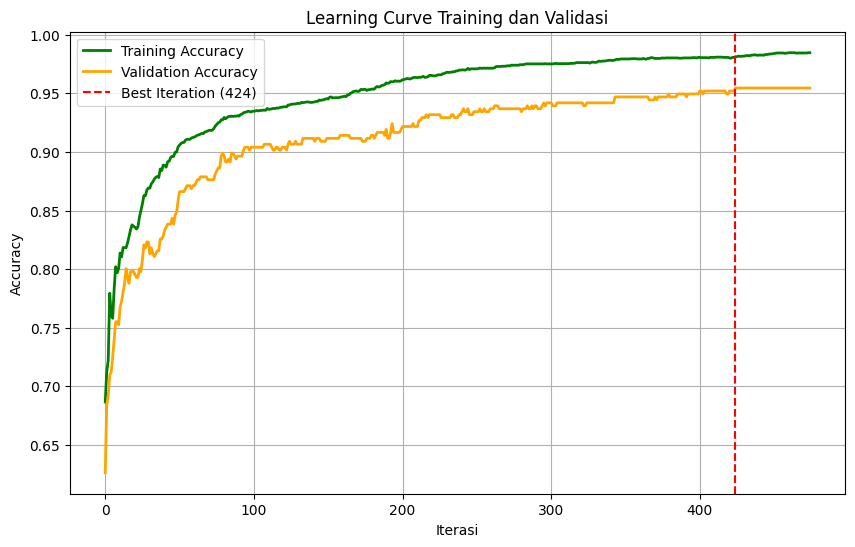

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn'][metric_name], label=f'Training {metric_name}', color='green', linewidth=2)
plt.plot(eval_history['validation'][metric_name], label=f'Validation {metric_name}', color='orange', linewidth=2)
plt.axvline(best_iter, color='red', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel(metric_name)
plt.title(f'Learning Curve Training dan Validasi')
plt.legend()
plt.grid(True)
plt.show()


Training MultiClass Loss at best iteration (424): 0.1222
Validation MultiClass Loss at best iteration (424): 0.1967


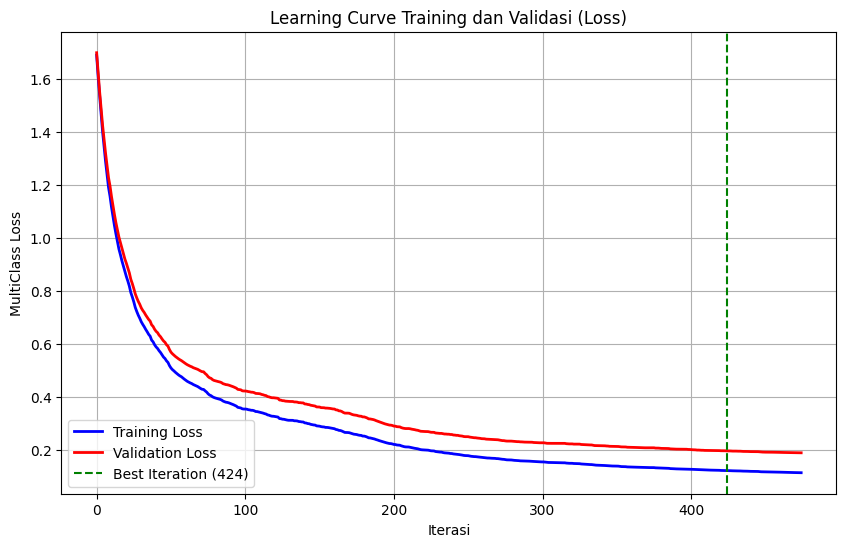

In [ ]:
print(f"\nTraining MultiClass Loss at best iteration ({best_iter}): {training_loss[best_iter]:.4f}")
print(f"Validation MultiClass Loss at best iteration ({best_iter}): {validation_loss[best_iter]:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(eval_history['learn']['MultiClass'], label='Training Loss', color='blue', linewidth=2)
plt.plot(eval_history['validation']['MultiClass'], label='Validation Loss', color='red', linewidth=2)
plt.axvline(best_iter, color='green', linestyle='--', label=f'Best Iteration ({best_iter})')
plt.xlabel('Iterasi')
plt.ylabel('MultiClass Loss')
plt.title('Learning Curve Training dan Validasi (Loss)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
y_pred = CatBoost_Model.predict(X_val_trimmed)
print("\n===== HASIL EVALUASI MODEL CatBoost =====")
accuracy = accuracy_score(y_val, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%")
print("\n")
print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))
print("\n")

print("Classification Report:")
print(classification_report(y_val, y_pred))
print("============================================")


===== HASIL EVALUASI MODEL CatBoost =====
Akurasi Model: 95.45%


Confusion Matrix:
[[59  0  0  0  0  0]
 [ 5 72  0  0  0  4]
 [ 0  0 59  4  0  1]
 [ 0  0  1 52  0  0]
 [ 0  0  0  0 45  0]
 [ 0  0  3  0  0 91]]


Classification Report:
                     precision    recall  f1-score   support

Insufficient_Weight       0.92      1.00      0.96        59
      Normal_Weight       1.00      0.89      0.94        81
     Obesity_Type_I       0.94      0.92      0.93        64
    Obesity_Type_II       0.93      0.98      0.95        53
   Obesity_Type_III       1.00      1.00      1.00        45
         Overweight       0.95      0.97      0.96        94

           accuracy                           0.95       396
          macro avg       0.96      0.96      0.96       396
       weighted avg       0.96      0.95      0.95       396



/tmp/ipython-input-2977590800.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


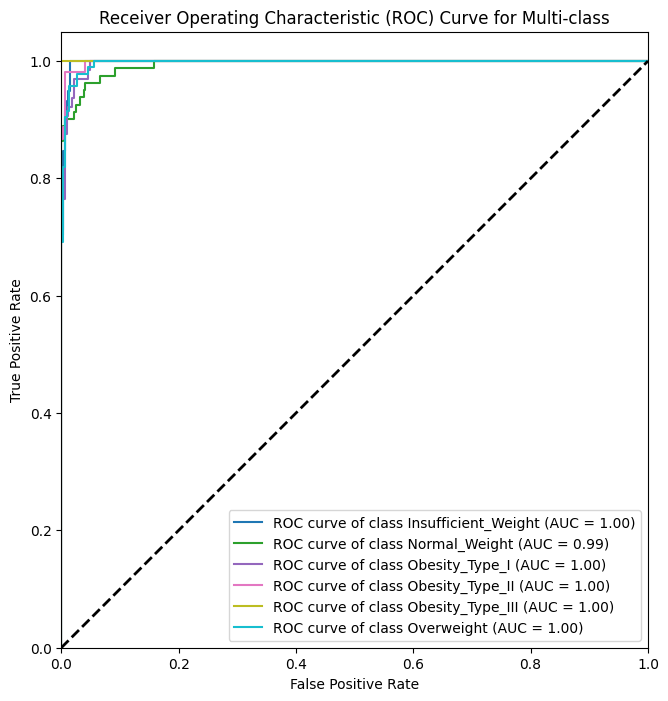


AUC for each class:
  Insufficient_Weight: 1.00
  Normal_Weight: 0.99
  Obesity_Type_I: 1.00
  Obesity_Type_II: 1.00
  Obesity_Type_III: 1.00
  Overweight: 1.00


In [ ]:
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.preprocessing import label_binarize
import numpy as np

all_classes = sorted(y_train_smote.unique())

y_val_binarized = label_binarize(y_val, classes=all_classes)
n_classes = y_val_binarized.shape[1]

y_prob = CatBoost_Model.predict_proba(X_val_trimmed)

fpr = dict()
tpr = dict()
roc_auc = dict()

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    roc_display = RocCurveDisplay.from_predictions(y_val_binarized[:, i], y_prob[:, i], name=f'ROC curve of class {all_classes[i]}', ax=ax, color=colors(i))
    fpr[i] = roc_display.fpr
    tpr[i] = roc_display.tpr
    roc_auc[i] = roc_display.roc_auc


plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.show()

print("\nAUC for each class:")
for i in range(n_classes):
    print(f"  {all_classes[i]}: {roc_auc[i]:.2f}")

## PART 12 TEST MODEL

In [ ]:
y_pred_test = CatBoost_Model.predict(X_test_trimmed)

print("===== HASIL EVALUASI MODEL CatBoost PADA DATA TESTING =====")
accuracy_test = accuracy_score(y_test, y_pred_test)
print(f"Akurasi Model pada Test Set: {accuracy_test * 100:.2f}%")
print("\n")
print("Confusion Matrix pada Test Set:")
print(confusion_matrix(y_test, y_pred_test))
print("\n")
print("Classification Report pada Test Set:")
print(classification_report(y_test, y_pred_test))
print("==========================================================")

===== HASIL EVALUASI MODEL CatBoost PADA DATA TESTING =====
Akurasi Model pada Test Set: 95.72%


Confusion Matrix pada Test Set:
[[59  1  0  0  0  0]
 [ 2 74  0  0  0  5]
 [ 0  0 62  2  0  0]
 [ 0  0  2 51  0  0]
 [ 0  0  0  1 44  0]
 [ 0  3  1  0  0 90]]


Classification Report pada Test Set:
                     precision    recall  f1-score   support

Insufficient_Weight       0.97      0.98      0.98        60
      Normal_Weight       0.95      0.91      0.93        81
     Obesity_Type_I       0.95      0.97      0.96        64
    Obesity_Type_II       0.94      0.96      0.95        53
   Obesity_Type_III       1.00      0.98      0.99        45
         Overweight       0.95      0.96      0.95        94

           accuracy                           0.96       397
          macro avg       0.96      0.96      0.96       397
       weighted avg       0.96      0.96      0.96       397



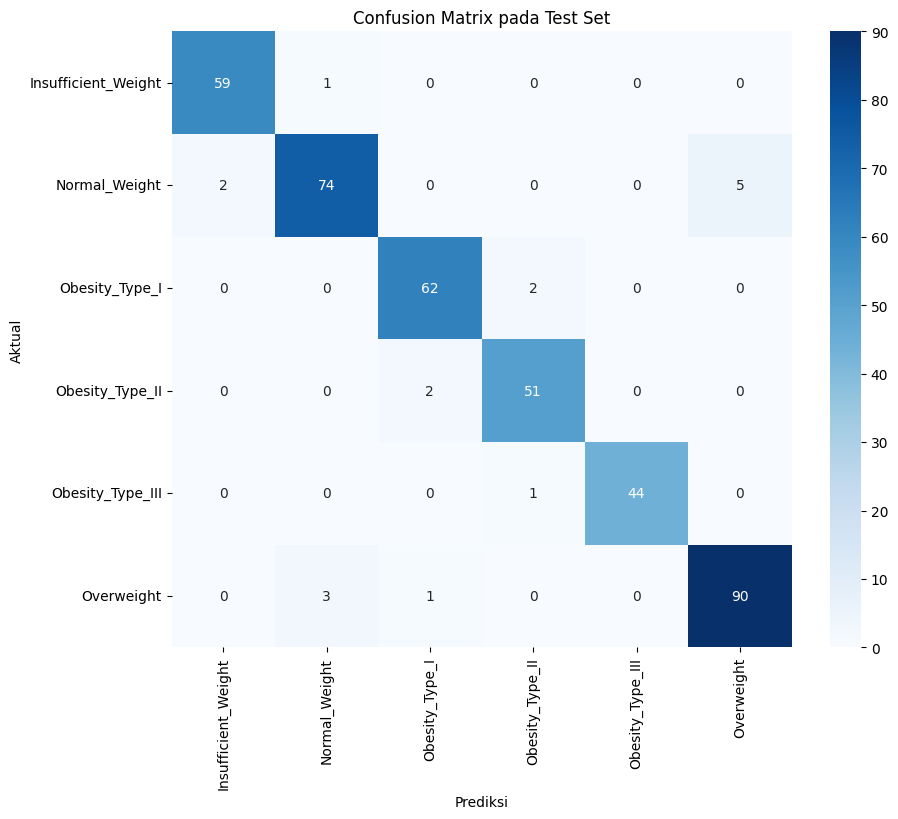

In [ ]:

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CatBoost_Model.classes_, yticklabels=CatBoost_Model.classes_)
plt.title('Confusion Matrix pada Test Set')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

/tmp/ipython-input-3068889088.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


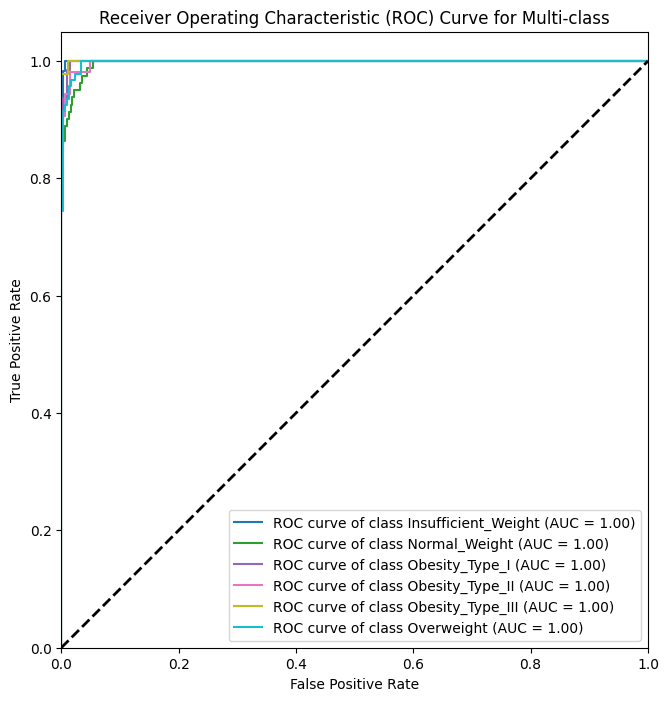


AUC for each class:
  Insufficient_Weight: 1.00
  Normal_Weight: 1.00
  Obesity_Type_I: 1.00
  Obesity_Type_II: 1.00
  Obesity_Type_III: 1.00
  Overweight: 1.00


In [ ]:
from sklearn.metrics import RocCurveDisplay, auc
from sklearn.preprocessing import label_binarize
import numpy as np

all_classes = sorted(y_train_smote.unique())

y_test_binarized = label_binarize(y_test, classes=all_classes)
n_classes = y_test_binarized.shape[1]

y_prob = CatBoost_Model.predict_proba(X_test_trimmed)

fpr = dict()
tpr = dict()
roc_auc = dict()

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    roc_display = RocCurveDisplay.from_predictions(y_test_binarized[:, i], y_prob[:, i], name=f'ROC curve of class {all_classes[i]}', ax=ax, color=colors(i))
    fpr[i] = roc_display.fpr
    tpr[i] = roc_display.tpr
    roc_auc[i] = roc_display.roc_auc


plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")
plt.show()

print("\nAUC for each class:")
for i in range(n_classes):
    print(f"  {all_classes[i]}: {roc_auc[i]:.2f}")

# Testing Model

## PART 13 INPUT DATA

In [ ]:
def get_user_input():
    """Fungsi untuk mengambil input dari pengguna dengan validasi dan pilihan angka untuk kategorikal."""
    print("\nSilakan masukkan data untuk prediksi tingkat obesitas:")
    data = {}
    try:
        # Gender
        gender_choice = int(input("Jenis Kelamin (0: Female, 1: Male): "))
        data['Gender'] = 'Female' if gender_choice == 0 else 'Male'

        # Age
        data['Age'] = int(input("Umur: "))

        # Height
        data['Height'] = int(input("Tinggi Badan (cm): "))

        # Weight
        data['Weight'] = int(input("Berat Badan (kg): "))

        # family_history_with_overweight
        family_history_choice = int(input("Riwayat keluarga dengan berat badan berlebih? (0: Tidak ada, 1: Ada): "))
        data['family_history_with_overweight'] = 'no' if family_history_choice == 0 else 'yes'

        # FAVC
        favc_choice = int(input("Sering makan makanan tinggi kalori dalam seminggu ? (0: Tidak Pernah, 1: Sering (2-3 seminggu)): "))
        data['FAVC'] = 'no' if favc_choice == 0 else 'yes'

        # FCVC
        data['FCVC'] = str(int(input("Frekuensi makan sayur (1: Tidak Pernah, 2: Kadang-kadang, 3: Setiap Makan): ")))

        # NCP
        data['NCP'] = str(int(input("Berapa kali makan utama per hari? (1-4): ")))

        # CAEC
        caec_choice = int(input("Dalam 7 hari terakhir, berapa hari anda makan cemilan di luar waktu makan utama? (0: 6-7 hari, 1: 3-5 hari, 2: 1-2 hari, 3: Tidak Pernah): "))
        caec_map = {0: 'Always', 1: 'Frequently', 2: 'Sometimes', 3: 'no'}
        data['CAEC'] = caec_map.get(caec_choice, 'no')

        # CH2O
        data['CH2O'] = str(int(input("Berapa banyak air yang diminum setiap hari? (1: <1L, 2: 1-2L, 3: >2L): ")))

        # FAF
        data['FAF'] = str(int(input("Berapa menit anda melakukan aktivitas fisik (jalan, bersepeda, olahraga ringan) (0: < 15 menit, 1: 15-30 menit, 2: 30-60 menit, 3: > 60 menit): ")))

        # TUE
        data['TUE'] = str(int(input("Waktu penggunaan perangkat teknologi (0: <1 jam, 1: 1-2 jam, 2: >2 jam): ")))

        # CALC
        calc_choice = int(input("Seberapa sering minum alkohol? (0: Always, 1: Frequently, 2: Sometimes, 3: No): "))
        calc_map = {0: 'Always', 1: 'Frequently', 2: 'Sometimes', 3: 'no'}
        data['CALC'] = calc_map.get(calc_choice, 'no')

        # MTRANS
        mtrans_choice = int(input("Transportasi yang biasa digunakan (0: Automobile, 1: Bike, 2: Motorbike, 3: Public_Transportation, 4: Walking): "))
        mtrans_map = {0: 'Automobile', 1: 'Bike', 2: 'Motorbike', 3: 'Public_Transportation', 4: 'Walking'}
        data['MTRANS'] = mtrans_map.get(mtrans_choice, 'Public_Transportation')


        return pd.DataFrame([data])
    except ValueError:
        print("❌ Input tidak valid. Mohon masukkan data dalam format angka yang benar sesuai pilihan.")
        return None
    except KeyError:
        print("❌ Input pilihan tidak valid. Mohon masukkan angka pilihan yang tersedia.")
        return None


data_pasien_baru = get_user_input()


Silakan masukkan data untuk prediksi tingkat obesitas:
Jenis Kelamin (0: Female, 1: Male): 1
Umur: 22
Tinggi Badan (cm): 168
Berat Badan (kg): 80
Riwayat keluarga dengan berat badan berlebih? (0: Tidak ada, 1: Ada): 1
Sering makan makanan tinggi kalori dalam seminggu ? (0: Tidak Pernah, 1: Sering (2-3 seminggu)): 1
Frekuensi makan sayur (1: Tidak Pernah, 2: Kadang-kadang, 3: Setiap Makan): 2
Berapa kali makan utama per hari? (1-4): 4
Dalam 7 hari terakhir, berapa hari anda makan cemilan di luar waktu makan utama? (0: 6-7 hari, 1: 3-5 hari, 2: 1-2 hari, 3: Tidak Pernah): 2
Berapa banyak air yang diminum setiap hari? (1: <1L, 2: 1-2L, 3: >2L): 2
Berapa menit anda melakukan aktivitas fisik (jalan, bersepeda, olahraga ringan) (0: < 15 menit, 1: 15-30 menit, 2: 30-60 menit, 3: > 60 menit): 0
Waktu penggunaan perangkat teknologi (0: <1 jam, 1: 1-2 jam, 2: >2 jam): 2
Seberapa sering minum alkohol? (0: Always, 1: Frequently, 2: Sometimes, 3: No): 3
Transportasi yang biasa digunakan (0: Automo

In [ ]:
print(data_pasien_baru)

  Gender  Age  Height  Weight family_history_with_overweight FAVC FCVC NCP  \
0   Male   22     168      80                            yes  yes    2   4   

        CAEC CH2O FAF TUE CALC     MTRANS  
0  Sometimes    2   0   2   no  Motorbike  


##PART 14 LIME - Analisis Faktor Dominan

### PART 14.1 ENCODE DATA

In [ ]:
label_encoders = {}

categorical_features = ['Gender','family_history_with_overweight', 'FAVC', 'FCVC','NCP','CAEC', 'CALC','MTRANS','CH2O','FAF','TUE']
for col in categorical_features:
    le = LabelEncoder()
    if col in X_train_smote_trimmed.columns:
        le.fit(X_train_smote_trimmed[col])
        label_encoders[col] = le
    else:
        print(f"Warning: Column '{col}' not found in X_train. Skipping encoding for LIME.")

X_train_smote_encoded = X_train_smote_trimmed.copy()
for col, encoder in label_encoders.items():
    if col in X_train_smote_encoded.columns:
        X_train_smote_encoded.loc[:, col] = encoder.transform(X_train_smote_encoded[col])

categorical_names = {}
for col in categorical_features_trimmed:
    if col in X_train_smote_encoded.columns:
        col_idx = X_train_smote_encoded.columns.get_loc(col)
        categorical_names[col_idx] = label_encoders[col].classes_.tolist()

In [ ]:
pasien_encoded_df = data_pasien_baru.copy()
for col, encoder in label_encoders.items():
    if col in pasien_encoded_df.columns:
        try:
            pasien_encoded_df.loc[:, col] = encoder.transform(pasien_encoded_df[col])
        except ValueError as e:
            print(f"Warning: Could not encode value(s) in column '{col}'. Error: {e}. Skipping encoding for this column.")


pasien_encoded_aligned = pasien_encoded_df[X_train_smote_encoded.columns]

pasien_data_asli = data_pasien_baru[X_train_smote_trimmed.columns]

prediksi_proba_konsisten = CatBoost_Model.predict_proba(pasien_data_asli)
hasil_prediksi_konsisten = CatBoost_Model.predict(pasien_data_asli)[0][0]

deskripsi_hasil = {
    'Insufficient_Weight': 'Kekurangan Berat Badan', 'Normal_Weight': 'Berat Badan Normal',
    'Overweight' : 'Kelebihan Berat Badan',
    'Obesity_Type_I': 'Obesitas Tingkat I', 'Obesity_Type_II': 'Obesitas Tingkat II', 'Obesity_Type_III': 'Obesitas Tingkat III'
}

### PART 14.2 INISIATE LIME

In [ ]:
categorical_Features_pertubation = [X_train_smote_encoded.columns.get_loc(col) for col in categorical_features_trimmed if col in X_train_smote_encoded.columns]

explainer = LimeTabularExplainer(
    training_data=X_train_smote_encoded.values,
    feature_names=X_train_smote_encoded.columns.tolist(),
    class_names=CatBoost_Model.classes_,
    categorical_features=categorical_Features_pertubation,
    categorical_names= categorical_names,
    mode='classification',
    random_state=42)

### PART 14.3 VISUALIZATION LIME

Hasil Prediksi: Kelebihan Berat Badan

=== Probabilitas Konsisten (Input String Asli) ===
- Kelebihan Berat Badan: 91.69%
- Obesitas Tingkat I: 5.47%
- Berat Badan Normal: 2.63%
- Obesitas Tingkat II: 0.14%
- Kekurangan Berat Badan: 0.04%
- Obesitas Tingkat III: 0.03%

🔍 Menganalisis Faktor Dominan dengan LIME...

✅ Faktor Pendukung Prediksi:
- 60.00 < Weight <= 80.00 (Bobot Pengaruh: 0.35143)
- MTRANS=Motorbike (Bobot Pengaruh: 0.04784)
- FCVC=2 (Bobot Pengaruh: 0.01240)
- CAEC=Sometimes (Bobot Pengaruh: 0.01198)

❌ Faktor Bertentangan dengan Prediksi:
- CALC=no (Bobot Pengaruh: -0.02396)
- TUE=2 (Bobot Pengaruh: -0.01102)
- NCP=4 (Bobot Pengaruh: -0.00973)

--- Visualisasi Faktor Pengaruh ---


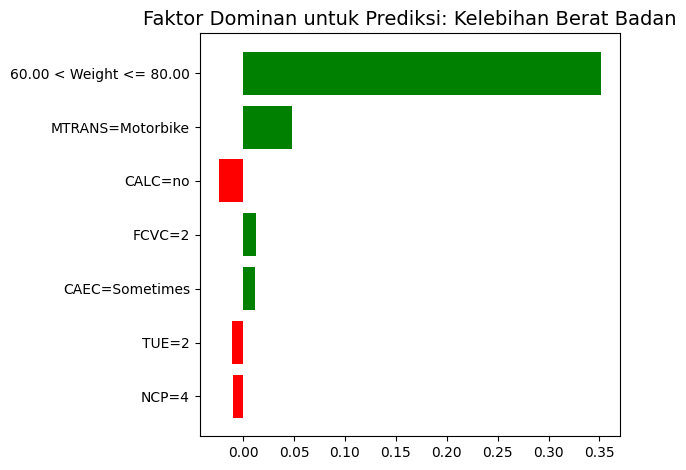

In [ ]:
print("=" * 50)
print(f"Hasil Prediksi: {deskripsi_hasil.get(hasil_prediksi_konsisten, 'Kategori tidak dikenal')}")

print("\n=== Probabilitas Konsisten (Input String Asli) ===")
daftar_kelas = list(CatBoost_Model.classes_)
probs_sorted = sorted(zip(daftar_kelas, prediksi_proba_konsisten[0]), key=lambda x: x[1], reverse=True)

for class_name, prob in probs_sorted:
    description = deskripsi_hasil.get(class_name, class_name)
    print(f"- {description}: {prob:.2%}")

print("=" * 50)

print("\n🔍 Menganalisis Faktor Dominan dengan LIME...")

def catboost_predict_proba_wrapper(numpy_data):
    df_from_numpy = pd.DataFrame(numpy_data, columns=X_train_smote_encoded.columns)
    df_decoded = df_from_numpy.copy()
    for col in categorical_features_trimmed:
        if col in df_decoded.columns:
            try:
                df_decoded[col] = df_decoded[col].astype(object)
                df_decoded.loc[:, col] = label_encoders[col].inverse_transform(df_decoded[col].astype(int))
            except ValueError as e:
                 print(f"Warning: Could not inverse transform value(s) in column '{col}'. Error: {e}. Keeping encoded values.")

    return CatBoost_Model.predict_proba(df_decoded)

explanation = explainer.explain_instance(
    pasien_encoded_aligned.iloc[0].values,
    catboost_predict_proba_wrapper,
    num_features=7, top_labels=1, num_samples = 26000)

top_label_index = explanation.top_labels[0]
hasil_lime = explanation.as_list(label=top_label_index)


print("\n✅ Faktor Pendukung Prediksi:")
for feature, weight in hasil_lime:
    if weight >= 0:
        print(f"- {feature} (Bobot Pengaruh: {weight:.5f})")

print("\n❌ Faktor Bertentangan dengan Prediksi:")
for feature, weight in hasil_lime:
    if weight < 0:
        print(f"- {feature} (Bobot Pengaruh: {weight:.5f})")



print("\n--- Visualisasi Faktor Pengaruh ---")
fig = explanation.as_pyplot_figure(label=top_label_index)
plt.title(f'Faktor Dominan untuk Prediksi: {deskripsi_hasil.get(hasil_prediksi_konsisten)}', fontsize=14)
plt.tight_layout()
plt.show()

## PART 15 Counterfactual Explanations DiCE

### PART 15.1 INISIATE DICE

In [ ]:
continuous_features = X_train_smote_trimmed.select_dtypes(include=['number']).columns.tolist()
target_name = 'NObeyesdad'
combined_df_trimmed = combined_df.drop(columns=features_to_trim)

if target_name in continuous_features:
    continuous_features.remove(target_name)

d = dice_ml.Data(dataframe=combined_df_trimmed,
                  continuous_features=continuous_features,
                  outcome_name=target_name)

m = dice_ml.Model(model=CatBoost_Model, backend="sklearn")

exp = dice_ml.Dice(d, m, method="genetic")

query_instance = data_pasien_baru[X_train_smote_trimmed.columns]

In [ ]:
class_names = m.model.classes_.tolist()
desired_class_index = class_names.index('Normal_Weight')

print(f"INFO: Mencari counterfactuals untuk kelas target: 'Normal_Weight' (ditemukan pada indeks: {desired_class_index})")

features_to_exclude_completely = ['Gender', 'Age', 'Height','family_history_with_overweight']

permitted_range = {}
for feature in features_to_exclude_completely:
    if feature in query_instance.columns:
        permitted_range[feature] = [query_instance[feature].iloc[0], query_instance[feature].iloc[0]]


dice_exp = exp.generate_counterfactuals(query_instance,
                                        total_CFs=50,
                                        desired_class=desired_class_index,
                                        permitted_range=permitted_range
                                        )

INFO: Mencari counterfactuals untuk kelas target: 'Normal_Weight' (ditemukan pada indeks: 1)


100%|██████████| 1/1 [00:06<00:00,  6.36s/it]


### PART 15.2 VISUALIZATION DICE

In [ ]:
print("\n==================================================")
print("Analisis Counterfactual (Apa yang harus diubah?)")
print("==================================================\n")
dice_exp.visualize_as_dataframe(show_only_changes=False)


Analisis Counterfactual (Apa yang harus diubah?)

Query instance (original outcome : Overweight)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,22,Male,168,80,no,yes,2,4,2,yes,0,2,Sometimes,Motorbike,Overweight



Diverse Counterfactual set (new outcome: Normal_Weight)


,Age,Gender,Height,Weight,CALC,FAVC,FCVC,NCP,CH2O,family_history_with_overweight,FAF,TUE,CAEC,MTRANS,NObeyesdad
0,22,Male,168,65,no,yes,2,4,2,yes,0,2,Sometimes,Public_Transportation,Normal_Weight
0,22,Male,168,60,no,yes,2,4,2,yes,0,2,Sometimes,Public_Transportation,Normal_Weight
0,22,Male,168,70,no,yes,2,4,2,yes,1,2,Sometimes,Public_Transportation,Normal_Weight
0,22,Male,168,69,no,yes,2,4,3,yes,0,2,Sometimes,Public_Transportation,Normal_Weight
0,22,Male,168,67,no,yes,2,2,2,yes,0,2,Sometimes,Public_Transportation,Normal_Weight
0,22,Male,168,65,no,yes,2,3,2,yes,0,2,Sometimes,Bike,Normal_Weight
0,22,Male,168,65,no,yes,2,3,2,yes,0,2,Sometimes,Public_Transportation,Normal_Weight
0,22,Male,168,64,no,yes,2,3,2,yes,0,2,Sometimes,Bike,Normal_Weight
0,22,Male,168,64,no,yes,2,3,2,yes,1,2,Sometimes,Motorbike,Normal_Weight
0,22,Male,168,64,no,yes,2,4,2,yes,2,2,Sometimes,Public_Transportation,Normal_Weight


🔄 Sedang menghitung Feature Importance DiCE untuk target: Normal_Weight...


100%|██████████| 1/1 [00:01<00:00,  1.30s/it]

DEBUG: importance_list content: [{'Weight': 1.0, 'MTRANS': 0.9, 'NCP': 0.6, 'FCVC': 0.5, 'CALC': 0.4, 'CH2O': 0.2, 'FAF': 0.2, 'FAVC': 0.1, 'Gender': 0.0, 'family_history_with_overweight': 0.0, 'TUE': 0.0, 'CAEC': 0.0, 'Age': 0.0, 'Height': 0.0}]


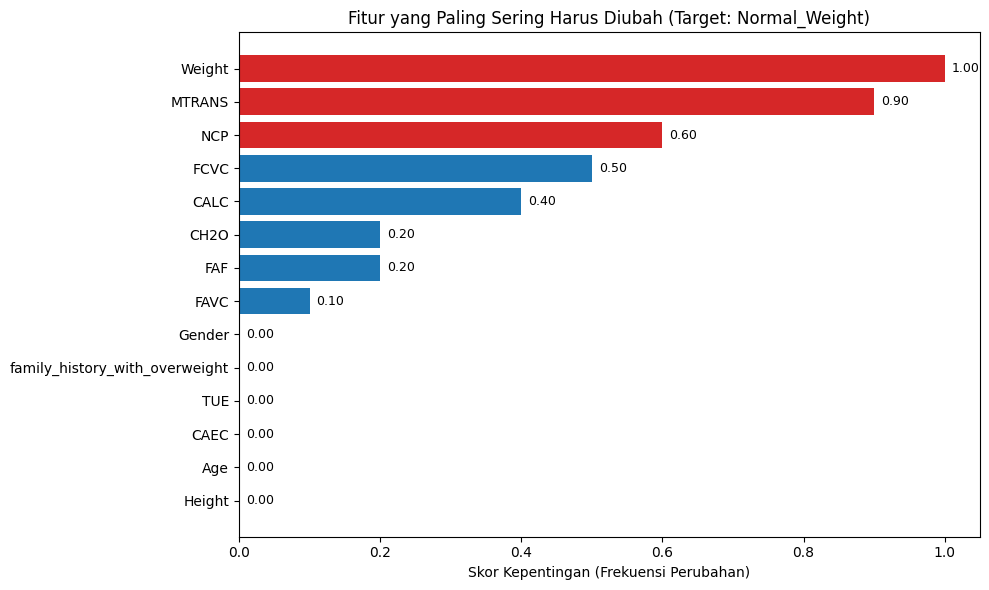


📊 **Interpretasi Hasil:**
1. Skor 1.0: Fitur ini WAJIB diubah di setiap skenario agar sehat.
2. Skor 0.0: Fitur ini sudah oke, tidak perlu diubah.
3. Fitur teratas adalah prioritas utama perubahan bagi pasien.


In [ ]:
def analisis_dice_importance(model, data_train, query_instance, target_class='Normal_Weight'):
    print(f"🔄 Sedang menghitung Feature Importance DiCE untuk target: {target_class}...")

    target_name = 'NObeyesdad'
    continuous_features = data_train.select_dtypes(include=['number']).columns.tolist()
    if target_name in continuous_features:
        continuous_features.remove(target_name)

    d = dice_ml.Data(dataframe=data_train,
                     continuous_features=continuous_features,
                     outcome_name=target_name)

    m = dice_ml.Model(model=model, backend="sklearn")

    exp = dice_ml.Dice(d, m, method="genetic")

    class_names = model.classes_.tolist()
    try:
        desired_class_index = class_names.index(target_class)
    except ValueError:
        print(f"❌ KESALAHAN: Kelas target '{target_class}' tidak ditemukan di daftar kelas model: {class_names}")
        return

    features_to_exclude_completely = ['Age', 'Height', 'Gender','family_history_with_overweight']

    permitted_range = {}
    for feature in features_to_exclude_completely:
        if feature in query_instance.columns:
            if pd.api.types.is_numeric_dtype(query_instance[feature]):
                value = query_instance[feature].iloc[0]
                permitted_range[feature] = [value, value]
            else:
                value = query_instance[feature].iloc[0]
                permitted_range[feature] = [value, value]

    imp = exp.local_feature_importance(
        query_instance,
        total_CFs=10,
        desired_class=desired_class_index,
        permitted_range=permitted_range
    )

    importance_list = imp.local_importance

    print("DEBUG: importance_list content:", importance_list)

    if importance_list and isinstance(importance_list[0], dict):
        feature_scores = list(importance_list[0].items())
        sorted_importance = sorted(feature_scores, key=lambda x: x[1], reverse=True)

        features = [item[0] for item in sorted_importance]
        scores = [item[1] for item in sorted_importance]
    else:
        print("❌ KESALAHAN: Struktur importance_list tidak seperti yang diharapkan.")
        return

    plt.figure(figsize=(10, 6))
    colors = ['#d62728' if s > 0.5 else '#1f77b4' for s in scores]

    bars = plt.barh(features, scores, color=colors)
    plt.xlabel('Skor Kepentingan (Frekuensi Perubahan)')
    plt.title(f'Fitur yang Paling Sering Harus Diubah (Target: {target_class})')
    plt.gca().invert_yaxis()
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{width:.2f}', ha='left', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\n📊 **Interpretasi Hasil:**")
    print("1. Skor 1.0: Fitur ini WAJIB diubah di setiap skenario agar sehat.")
    print("2. Skor 0.0: Fitur ini sudah oke, tidak perlu diubah.")
    print(f"3. Fitur teratas adalah prioritas utama perubahan bagi pasien.")

if 'CatBoost_Model' in locals() and 'data_pasien_baru' in locals():
    query_data = data_pasien_baru[X_train_smote_trimmed.columns]

    analisis_dice_importance(
        model=CatBoost_Model,
        data_train=combined_df_trimmed,
        query_instance=query_data,
        target_class='Normal_Weight'
    )
else:
    print("❌ Error: Pastikan model dan data pasien sudah di-load sebelumnya.")

### PART 15.3 SUMMARY DICE


--- Ringkasan Perubahan Counterfactual ---
Analisis dari 50 counterfactuals untuk mencapai 'Normal_Weight':
- MTRANS (ke: Public_Transportation): disarankan 30 kali (Nilai Asli: Motorbike)
- NCP (ke: 3): disarankan 17 kali (Nilai Asli: 4)
- Weight (ke: 60): disarankan 8 kali (Nilai Asli: 80)
- FAF (ke: 2): disarankan 5 kali (Nilai Asli: 0)
- FAVC (ke: no): disarankan 5 kali (Nilai Asli: yes)
- CALC (ke: Sometimes): disarankan 5 kali (Nilai Asli: no)
- CH2O (ke: 3): disarankan 4 kali (Nilai Asli: 2)
- TUE (ke: 1): disarankan 4 kali (Nilai Asli: 2)
- CAEC (ke: Frequently): disarankan 4 kali (Nilai Asli: Sometimes)
- FCVC (ke: 3): disarankan 3 kali (Nilai Asli: 2)


/tmp/ipython-input-2270396996.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts_for_plot, y=features_for_plot, palette='viridis')


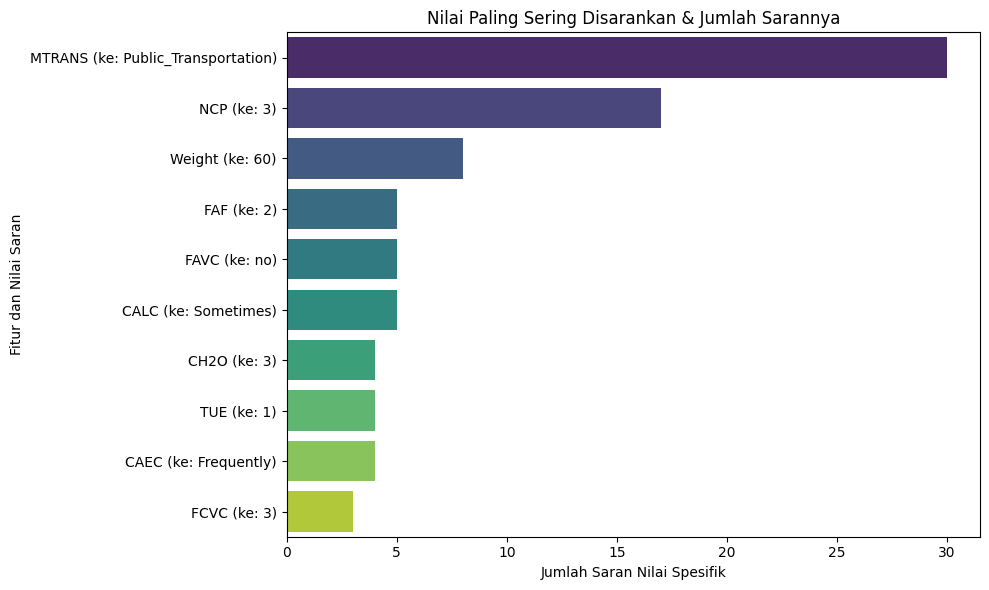

In [ ]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming dice_exp and query_instance are already defined from previous steps

if 'dice_exp' in locals() and 'query_instance' in locals():
    # Access the DataFrame containing all generated counterfactuals
    cf_df_all = dice_exp.cf_examples_list[0].final_cfs_df

    if not cf_df_all.empty:
        # Get the original query instance as a dictionary for easy comparison
        original_data = query_instance.iloc[0].to_dict()

        # Dictionary to store counts of feature changes
        changed_features_count = Counter()

        # Dictionary to store all suggested counterfactual values for each changed feature
        feature_all_suggested_values = {}

        # Exclude 'NObeyesdad' from comparison as it's the target
        features_to_compare = [col for col in query_instance.columns if col != 'NObeyesdad']

        # Iterate through each counterfactual (row) in the DataFrame
        for index, cf_row in cf_df_all.iterrows():
            for feature in features_to_compare:
                if feature in cf_row.index and feature in original_data:
                    # Check if the value has changed
                    if cf_row[feature] != original_data[feature]:
                        changed_features_count[feature] += 1

                        # Store the suggested counterfactual value for this specific CF
                        if feature not in feature_all_suggested_values:
                            feature_all_suggested_values[feature] = []
                        feature_all_suggested_values[feature].append(cf_row[feature])

        if changed_features_count:
            print("\n--- Ringkasan Perubahan Counterfactual ---")
            print(f"Analisis dari {cf_df_all.shape[0]} counterfactuals untuk mencapai 'Normal_Weight':")

            # Prepare data for plotting the most common suggested value counts
            plot_data = []
            for feature, total_count_changed in sorted(changed_features_count.items(), key=lambda item: item[1], reverse=True):
                most_common_value = None
                most_common_count = 0
                if feature in feature_all_suggested_values:
                    value_counts = Counter(feature_all_suggested_values[feature])
                    if value_counts:
                        most_common_value, most_common_count = value_counts.most_common(1)[0]

                # Only include features where a common value was identified
                if most_common_value is not None:
                    plot_data.append({
                        'Feature': f"{feature} (ke: {most_common_value})",
                        'Count': most_common_count,
                        'Original_Value': original_data[feature]
                    })

            # Sort plot data by count (descending)
            plot_data_sorted = sorted(plot_data, key=lambda x: x['Count'], reverse=True)

            # Print detailed summary
            for item in plot_data_sorted:
                print(f"- {item['Feature']}: disarankan {item['Count']} kali (Nilai Asli: {item['Original_Value']})")

            # Visualize the top changed features based on most common suggested value count
            top_n = min(10, len(plot_data_sorted)) # Display up to 10 top features
            features_for_plot = [item['Feature'] for item in plot_data_sorted[:top_n]]
            counts_for_plot = [item['Count'] for item in plot_data_sorted[:top_n]]

            plt.figure(figsize=(10, 6))
            sns.barplot(x=counts_for_plot, y=features_for_plot, palette='viridis')
            plt.title('Nilai Paling Sering Disarankan & Jumlah Sarannya')
            plt.xlabel('Jumlah Saran Nilai Spesifik')
            plt.ylabel('Fitur dan Nilai Saran')
            plt.tight_layout()
            plt.show()

        else:
            print("Tidak ada fitur yang disarankan untuk diubah di counterfactuals yang dihasilkan.")
    else:
        print("Tidak ada counterfactual yang dihasilkan oleh DiCE.")
else:
    print("Error: Objek 'dice_exp' atau 'query_instance' tidak ditemukan. Pastikan DiCE telah dijalankan.")


# MODEL WEBSITE


In [ ]:
import pickle
from sklearn.preprocessing import LabelEncoder

X_ClassNames = X_train_smote_trimmed.columns.tolist()

Y_ClassNames = CatBoost_Model.classes_.tolist()

y_label_encoder = LabelEncoder()
y_label_encoder.fit(y_train_smote)

Y_Processed = y_label_encoder.transform(y_train_smote)

variables_to_save = {
    'X_train_smote': X_train_smote_trimmed,
    'y_train_smote': y_train_smote,
    'X_ClassNames': X_ClassNames,
    'Y_ClassNames': Y_ClassNames,
    'Y_Processed': Y_Processed,
    'y_label_encoder': y_label_encoder
}


for name, data in variables_to_save.items():
    filename = f'{name}.pkl'
    with open(filename, 'wb') as f:
        pickle.dump(data, f)
    print(f"Variabel '{name}' telah disimpan sebagai '{filename}'")


Variabel 'X_train_smote' telah disimpan sebagai 'X_train_smote.pkl'
Variabel 'y_train_smote' telah disimpan sebagai 'y_train_smote.pkl'
Variabel 'X_ClassNames' telah disimpan sebagai 'X_ClassNames.pkl'
Variabel 'Y_ClassNames' telah disimpan sebagai 'Y_ClassNames.pkl'
Variabel 'Y_Processed' telah disimpan sebagai 'Y_Processed.pkl'
Variabel 'y_label_encoder' telah disimpan sebagai 'y_label_encoder.pkl'


In [ ]:
X_test_trimmed.to_csv('X_test.csv', index=False)
X_val_trimmed.to_csv('X_val.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
y_val.to_csv('y_val.csv', index=False)

print("X_test.csv, X_val.csv, y_test.csv, dan y_val.csv telah disimpan.")


X_test.csv, X_val.csv, y_test.csv, dan y_val.csv telah disimpan.


In [ ]:
model_filename = 'catboost_model.cbm'
CatBoost_Model.save_model(model_filename)
print(f"Model CatBoost telah disimpan sebagai '{model_filename}'")

Model CatBoost telah disimpan sebagai 'catboost_model.cbm'
